# Diabetes-Obesity Co-Hotspots in Greater Houston Were Associated with Social Vulnerability and Limited Food Access

**Yash Nirmal Ganatra, Michael E. DeBakey High School for Health Professions, Houston, Texas, USA**

**Project Description**

This notebook reproduces the data preparation, spatial analysis, statistical testing, and figure generation used in the study *“Diabetes-Obesity Co-Hotspots in Greater Houston Were Associated with Social Vulnerability and Limited Food Access.”* The analysis integrates publicly available datasets from CDC PLACES, CDC/ATSDR Social Vulnerability Index, the USDA Food Access Research Atlas, and U.S. Census tract boundary files. The workflow harmonizes datasets to 2010 census tracts using area-weighted crosswalks, identifies diabetes-obesity co-hotspots based on prevalence thresholds, evaluates associations with social vulnerability and low-income low-access food environments, and tests spatial clustering using Moran’s I. The notebook produces the statistical results and figures reported in the manuscript.

**Google Drive Mount**

The following cell connects Google Drive to the Colab notebook. It asks for permission to access the Google account and then mounts Drive at `/content/drive`. After this step, files stored in Google Drive can be read directly by the notebook, and output files created by the notebook can be saved back to Drive. This is needed so the analysis can use input datasets from Drive and keep generated results, figures, and tables in a permanent location instead of only inside the temporary Colab session. If Drive is already mounted, Colab may simply confirm that it is already connected.

In [1]:
# Google Drive Mount
# Input: Google account access and the Drive mount location.
# Output: Google Drive connected in Colab so files can be read and saved.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load Main Libraries**

The following cell loads the main Python libraries needed for the full analysis. These libraries provide tools for reading and organizing data tables, working with census tract map files, running statistical tests, performing spatial analysis, adjusting P values for multiple comparisons, and creating figures.

This cell does not analyze any data by itself. Instead, it prepares the notebook by importing the tools that will be used in later cells.

`pandas` and `numpy` are used for working with tables, columns, numbers, and calculations. `geopandas` is used to work with geographic data, such as census tract boundaries. `scipy` is used for statistical testing, including Mann-Whitney U tests, chi-square tests, and Spearman correlations.

The spatial analysis tools from `libpysal` and `esda` are used to define neighboring census tracts and measure spatial clustering. Queen contiguity identifies tracts that touch by an edge or a corner. Moran’s I is used to test whether similar diabetes-obesity values cluster together across space. Getis-Ord Gi* is used to identify local high-value and low-value clusters.

The `statsmodels` multiple-testing tool is used to adjust P values when many local spatial tests are performed. The plotting libraries from `matplotlib` are used to create maps, legends, labels, and other figure elements for the manuscript.

In [2]:
# Load Main Libraries
# Input: Installed Python packages for tables, maps, statistics, spatial analysis, and plotting.
# Output: Imported tools used throughout the analysis.

# Import basic math functions and file path tools
import math
from pathlib import Path

# Import tools for working with tables and numerical data
import pandas as pd
import numpy as np

# Import tools for working with map-based tract data
import geopandas as gpd

# Import general statistical testing tools
from scipy import stats

# Import specific statistical tests used in the study
from scipy.stats import mannwhitneyu, chi2_contingency, spearmanr

# Import tools to define neighboring census tracts
from libpysal.weights import Queen

# Import tool to calculate nearby-area values using spatial weights
from libpysal.weights import lag_spatial

# Import tool for overall spatial clustering analysis
from esda.moran import Moran

# Import tool for local high-cluster and low-cluster analysis
from esda.getisord import G_Local

# Import tool to adjust P values when many tests are run
from statsmodels.stats.multitest import multipletests

# Import plotting tools for maps, charts, legends, and labels
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe

**Confirm Figure Output Files**

The following cell checks whether all expected manuscript figure files were successfully created. It is a quality-control cell and should be run after the figure-generation cells.

This cell first confirms that the main project folder and figure-output folders are defined. If the earlier figure-output setup cell was not run, it creates fallback folder paths for the project directory, manuscript figures folder, native SVG/PDF folder, raster PNG folder, and figure data tables folder. It also defines backup helper functions for cleaning file names and creating the required output folders.

The cell then lists the expected figure file names for Figures 1 through 8. For each figure, it checks whether three output formats exist: PNG, SVG, and PDF. PNG files are checked in the raster figure folder, while SVG and PDF files are checked in the native/vector figure folder.

The cell separates the results into two lists: files that were found and files that are missing. If any expected files are missing, it prints the full paths of the missing files so they can be identified and regenerated. If no files are missing, it confirms that all expected PNG, SVG, and PDF figure files were created.

Finally, the cell prints a short summary showing the number of figure files found, the number missing, and whether each figure-output folder exists. This helps verify that the manuscript figure export process completed correctly and that the files are saved in the expected locations.

In [3]:
# Confirm Figure Output Files
# Input: Expected figure stems and output folders.
# Output: Checklist confirming that PNG, SVG, and PDF files were created.

from pathlib import Path
import re

# ---------------------------------------------------------------------
# Fallback setup only if the figure-output setup cell was not run
# ---------------------------------------------------------------------

# Define the main project folder if it has not already been defined
if "PROJECT_DIR" not in globals():
    PROJECT_DIR = Path("/content/drive/MyDrive/Census_Tract_Analysis_Project")

# Define the main manuscript figure folder if it has not already been defined
if "FIGURE_ROOT_DIR" not in globals():
    FIGURE_ROOT_DIR = PROJECT_DIR / "Manuscript Figures"

# Define the folder for editable SVG files and vector PDF files if needed
if "FIGURE_SOURCE_DIR" not in globals():
    FIGURE_SOURCE_DIR = FIGURE_ROOT_DIR / "Native SVG and PDF"

# Define the folder for PNG image files if needed
if "FIGURE_RASTER_DIR" not in globals():
    FIGURE_RASTER_DIR = FIGURE_ROOT_DIR / "Raster PNG"

# Define the folder for figure-related data tables if needed
if "FIGURE_TABLE_DIR" not in globals():
    FIGURE_TABLE_DIR = FIGURE_ROOT_DIR / "Figure Data Tables"

# Define a helper function to clean file names if it has not already been defined
if "clean_file_stem" not in globals():
    def clean_file_stem(stem):
        stem = str(stem).strip().replace(" ", "_")
        stem = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", stem)
        stem = re.sub(r"_+", "_", stem)
        return stem.strip("_")

# Define a helper function to confirm that required output folders exist
if "ensure_output_folders" not in globals():
    def ensure_output_folders():
        drive_root = Path("/content/drive/MyDrive")

        # Stop the cell if Google Drive is not mounted
        if not drive_root.exists():
            raise FileNotFoundError(
                "Google Drive does not appear to be mounted at /content/drive/MyDrive. "
                "Run the Google Drive mount cell first."
            )

        # Create the project and figure-output folders if they do not already exist
        for folder in [
            PROJECT_DIR,
            FIGURE_ROOT_DIR,
            FIGURE_SOURCE_DIR,
            FIGURE_RASTER_DIR,
            FIGURE_TABLE_DIR
        ]:
            folder.mkdir(parents=True, exist_ok=True)

        return True

# ---------------------------------------------------------------------
# Confirm expected figure files
# ---------------------------------------------------------------------

# Make sure the output folders exist before checking for files
ensure_output_folders()

# List the expected base file names for all manuscript figure outputs
expected_stems = [
    "Figure_1_study_area_map",
    "Figure_2_diabetes_obesity_prevalence_maps",
    "Figure_3_high_burden_overlap_tracts",
    "Figure_4_getis_ord_gi_star_high_clusters",
    "Figure_5_social_vulnerability_index_map",
    "Figure_6_svi_by_high_burden_overlap_status",
    "Figure_7_lila_and_high_burden_overlap_map",
    "Figure_8_moran_scatterplot"
]

# Create empty lists to track which expected files are present or missing
missing_files = []
created_files = []

# Check each expected figure in PNG, SVG, and PDF format
for stem in expected_stems:
    stem = clean_file_stem(stem)

    # Build the expected file paths for each figure format
    expected_paths = [
        FIGURE_RASTER_DIR / f"{stem}.png",
        FIGURE_SOURCE_DIR / f"{stem}.svg",
        FIGURE_SOURCE_DIR / f"{stem}.pdf"
    ]

    # Add each file to the created or missing list based on whether it exists
    for path in expected_paths:
        if path.exists():
            created_files.append(path)
        else:
            missing_files.append(path)

# Print the missing file list if any expected files were not found
if missing_files:
    print("Missing expected figure files:")
    for path in missing_files:
        print(path)
else:
    print("All expected PNG, SVG, and PDF figure files were created.")

print()

# Print the total number of expected files found and missing
print("Created figure files found:", len(created_files))
print("Missing figure files:", len(missing_files))

print()

# Print the output folder paths and confirm whether each folder exists
print("Figure folders:")
print("Raster PNG:", FIGURE_RASTER_DIR, "| exists:", FIGURE_RASTER_DIR.exists())
print("Native SVG and vector PDF:", FIGURE_SOURCE_DIR, "| exists:", FIGURE_SOURCE_DIR.exists())
print("Figure data tables:", FIGURE_TABLE_DIR, "| exists:", FIGURE_TABLE_DIR.exists())

Missing expected figure files:
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/Figure_1_study_area_map.png
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_1_study_area_map.svg
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_1_study_area_map.pdf
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/Figure_2_diabetes_obesity_prevalence_maps.png
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_2_diabetes_obesity_prevalence_maps.svg
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_2_diabetes_obesity_prevalence_maps.pdf
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/Figure_3_high_burden_overlap_tracts.png
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Fig

**Load Study Datasets and Census Tract Map**

The following cell loads the main datasets needed for the study into memory. It reads the PLACES health data, Social Vulnerability Index data, USDA Food Access Atlas data, the census tract crosswalk table, and the 2010 Texas census tract boundary shapefile.

All tabular files are loaded with values treated as text so that census tract identifiers are not accidentally changed, rounded, or stripped of leading zeros. The food access file is read from Excel, while the other tables are read from CSV or pipe-delimited text files. The census tract boundary shapefile is loaded as a geospatial data frame so that tract-level results can later be mapped.

After loading the files, the cell prints the number of rows or polygons in each dataset. These row counts provide a quick check that the files loaded successfully and help confirm that no dataset is unexpectedly empty or missing before later merging, filtering, and analysis steps.

In [4]:
# Load Study Datasets and Census Tract Map
# Input: PLACES health data, CDC Social Vulnerability Index data, USDA food access data,
# Census tract crosswalk table, and 2010 Texas census tract polygons.
# Output: Data tables and tract boundary map loaded into memory for later merging and analysis.

# Define the main project folder where all input files are stored
base = "/content/drive/MyDrive/Census_Tract_Analysis_Project"

# Load the filtered PLACES health data as text to preserve tract identifiers
places = pd.read_csv(
    f"{base}/places_tract_tx_9county_filtered.csv",
    dtype=str
)

# Load the filtered CDC Social Vulnerability Index data as text to preserve GEOID fields
svi = pd.read_csv(
    f"{base}/svi_2022_us_tract_filtered.csv",
    dtype=str
)

# Load the filtered USDA Food Access Research Atlas data as text for later tract matching
food = pd.read_excel(
    f"{base}/usda_food_access_atlas_2019_filtered.xlsx",
    dtype=str
)

# Load the census tract crosswalk table used to connect 2020 tracts to 2010 tracts
xwalk = pd.read_csv(
    f"{base}/tab20_tract20_tract10_natl.txt",
    sep="|",
    dtype=str
)

# Load the 2010 Texas census tract boundary shapefile for mapping and spatial analysis
tracts2010 = gpd.read_file(
    f"{base}/cb_2010_tx_tract_500k/gz_2010_48_140_00_500k.shp"
)

# Quick row counts to confirm files loaded correctly
print("PLACES rows:", len(places))
print("SVI rows:", len(svi))
print("Food rows:", len(food))
print("Crosswalk rows:", len(xwalk))
print("Tract polygons:", len(tracts2010))

PLACES rows: 4788
SVI rows: 1603
Food rows: 1068
Crosswalk rows: 126450
Tract polygons: 5259


**Prepare PLACES Health Indicators by Census Tract**

The following cell cleans and reshapes the CDC PLACES health indicator table so it can be used in the tract-level analysis. It first extracts the 11-digit census tract GEOID from the `LocationName` field and saves it as `geoid_tract20`. It then converts the `Data_Value` column to a numeric format so the health percentages can be analyzed.

Next, the cell keeps only the three PLACES measures used in this study: diagnosed diabetes among adults, obesity among adults, and no leisure-time physical activity among adults. The table is then reshaped so that each census tract appears only once, with separate columns for diabetes, obesity, and physical inactivity percentages. If more than one value exists for the same tract and measure, the first available value is used.

Finally, the cell renames the measure columns to shorter and clearer variable names: `diabetes_pct`, `obesity_pct`, and `inactivity_pct`. The last line previews the cleaned table to confirm that the data were prepared correctly.

In [5]:
# Prepare PLACES Health Indicators by Census Tract
# Input: PLACES table containing health measures and tract identifiers within text fields.
# Output: One clean table with one row per census tract and three health indicators.

# Extract the 11-digit census tract GEOID from the LocationName field
places["geoid_tract20"] = places["LocationName"].str.extract(r"(\d{11})")

# Convert the health value column to numeric so it can be analyzed
places["Data_Value"] = pd.to_numeric(places["Data_Value"], errors="coerce")

# Keep only the three health measures used in the study
places = places[
    places["Measure"].isin([
        "Diagnosed diabetes among adults",
        "Obesity among adults",
        "No leisure-time physical activity among adults"
    ])
]

# Reshape the table so each tract has a single row and each measure becomes a column
places_pivot = places.pivot_table(
    index="geoid_tract20",
    columns="Measure",
    values="Data_Value",
    aggfunc="first"
).reset_index()

# Rename columns to short, clear variable names
places_pivot = places_pivot.rename(columns={
    "Diagnosed diabetes among adults": "diabetes_pct",
    "Obesity among adults": "obesity_pct",
    "No leisure-time physical activity among adults": "inactivity_pct"
})

# Preview the cleaned table
places_pivot.head()

Measure,geoid_tract20,diabetes_pct,inactivity_pct,obesity_pct
0,48015760100,17.4,36.2,41.4
1,48015760201,18.3,37.1,42.5
2,48015760202,13.1,28.3,36.5
3,48015760301,14.8,29.8,36.9
4,48015760302,15.1,32.9,39.2


**Prepare Social Vulnerability Index by Census Tract**

The following cell prepares the Social Vulnerability Index (SVI) data for tract-level analysis. It keeps only the tract FIPS code and the overall SVI percentile ranking from the CDC SVI table. The tract FIPS code is converted into a standard 11-digit census tract GEOID so it can be matched correctly with the other census tract datasets used in the study. The SVI ranking column is then converted to a numeric value, and the CDC missing-value code of `-999` is replaced with a true missing value. The final cleaned table contains one row per census tract with two fields: the standardized tract GEOID and the overall social vulnerability score. The last line previews the cleaned table to confirm that the data were prepared correctly.

In [6]:
# Prepare Social Vulnerability Index by Census Tract
# Input: CDC SVI table containing tract FIPS codes and overall vulnerability ranking.
# Output: Clean table with standardized tract GEOID and numeric vulnerability score.

# Keep only the tract identifier and overall SVI ranking column
svi_clean = svi[["FIPS", "RPL_THEMES"]].copy()

# Convert the tract FIPS code to a standard 11-digit census tract GEOID
svi_clean["geoid_tract20"] = svi_clean["FIPS"].astype(str).str.zfill(11)

# Convert the overall vulnerability ranking to numeric values
svi_clean["rpl_themes"] = pd.to_numeric(svi_clean["RPL_THEMES"], errors="coerce")

# Replace the SVI missing-value flag with a proper missing value
svi_clean["rpl_themes"] = svi_clean["rpl_themes"].replace(-999, np.nan)

# Keep only the final fields used in the study
svi_clean = svi_clean[["geoid_tract20", "rpl_themes"]]

# Preview the cleaned SVI table
svi_clean.head()

,geoid_tract20,rpl_themes
0,48015760100,0.8356
1,48015760201,0.7858
2,48015760202,0.4682
3,48015760301,0.4576
4,48015760302,0.9148


**Prepare USDA Food Access Indicator by Census Tract**

The following cell prepares the USDA Food Access Atlas data so it can be merged with the main census tract dataset. It keeps only the columns needed for the analysis: the census tract identifier, county name, and the Low-Income, Low-Access tract indicator.

The cell then converts the USDA census tract field into a standardized 11-digit census tract GEOID. This is important because census tract identifiers must have the same format across datasets before they can be joined.

Next, the Low-Income, Low-Access indicator is converted into a numeric variable named `lila_1and10`. This variable identifies whether a tract meets the USDA Low-Income, Low-Access definition using the 1-mile urban and 10-mile rural threshold.

Finally, the cell keeps only the cleaned tract GEOID and the numeric LILA indicator, then displays the first few rows to confirm that the cleaned table looks correct.

In [7]:
# Prepare USDA Food Access Indicator by Census Tract
# Input: USDA Food Access Atlas table containing census tract identifiers and low-income, low-access indicator.
# Output: Clean table with standardized tract GEOID and numeric food access indicator.

# Keep only the USDA columns needed for the food access analysis
food_clean = food[[
    "CensusTract",
    "County",
    "LILATracts_1And10"
]].copy()

# Convert CensusTract field to a standard 11-digit tract GEOID
food_clean["geoid_tract10"] = food_clean["CensusTract"].astype(str).str.zfill(11)

# Convert the low-income, low-access indicator to numeric values
food_clean["lila_1and10"] = pd.to_numeric(food_clean["LILATracts_1And10"], errors="coerce")

# Keep only the tract identifier and final food access indicator
food_clean = food_clean[[
    "geoid_tract10",
    "lila_1and10"
]]

# Preview the cleaned food access table
food_clean.head()

,geoid_tract10,lila_1and10
0,48015760100,0
1,48015760200,0
2,48015760300,0
3,48015760400,0
4,48015760501,0


**Build Census Tract Crosswalk With Area Weights**

The following cell prepares the census tract crosswalk used to convert 2020 census tract data to 2010 census tract geography. This is needed because the study datasets may use different census tract years, so they must be placed on the same tract system before analysis.

The cell first keeps only the columns needed for the conversion: the 2020 tract ID, the 2010 tract ID, the total land area of the 2020 tract, and the land area where the 2020 tract overlaps with a 2010 tract. It then converts both tract IDs into standard 11-digit GEOID format so they can be matched correctly with other datasets.

Next, the land area fields are converted to numeric values. This allows the code to calculate an area weight for each tract match. The weight is calculated as the overlapping land area divided by the total 2020 tract land area. In simple terms, this weight shows what share of a 2020 tract falls inside a particular 2010 tract.

Finally, the cell keeps only the cleaned 2020 tract ID, the matched 2010 tract ID, and the calculated weight. The resulting table is then previewed with `head()` to confirm that the crosswalk was created correctly.

In [8]:
# Build Census Tract Crosswalk with Area Weights
# Input: Crosswalk table linking 2020 census tracts to 2010 census tracts with land area fields.
# Output: Clean table showing how each 2020 tract maps to 2010 tracts, with an area-based weight.

# Keep only the crosswalk columns needed for tract matching and area weighting
xwalk_clean = xwalk[[
    "GEOID_TRACT_20",
    "GEOID_TRACT_10",
    "AREALAND_TRACT_20",
    "AREALAND_PART"
]].copy()

# Convert both tract ID fields to standard 11-digit GEOID text format
xwalk_clean["geoid_tract20"] = xwalk_clean["GEOID_TRACT_20"].astype(str).str.zfill(11)
xwalk_clean["geoid_tract10"] = xwalk_clean["GEOID_TRACT_10"].astype(str).str.zfill(11)

# Convert land area columns to numbers so the area weights can be calculated
xwalk_clean["AREALAND_TRACT_20"] = pd.to_numeric(xwalk_clean["AREALAND_TRACT_20"], errors="coerce")
xwalk_clean["AREALAND_PART"] = pd.to_numeric(xwalk_clean["AREALAND_PART"], errors="coerce")

# Calculate the fraction of each 2020 tract that falls within each matched 2010 tract
xwalk_clean["weight"] = (
    xwalk_clean["AREALAND_PART"] /
    xwalk_clean["AREALAND_TRACT_20"]
)

# Keep only the cleaned tract IDs and the weight needed for later dataset conversion
xwalk_clean = xwalk_clean[[
    "geoid_tract20",
    "geoid_tract10",
    "weight"
]]

# Preview the cleaned crosswalk table
xwalk_clean.head()

,geoid_tract20,geoid_tract10,weight
0,01001020100,01001020100,0.999506
1,01001020100,01001020200,0.000494
2,01001020200,01001020200,1.000000
3,01001020300,01001020300,1.000000
4,01001020400,01001020400,1.000000


**Convert PLACES Health Data from 2020 Tracts to 2010 Tracts**

The following cell converts the PLACES health indicators from 2020 census tract geography to 2010 census tract geography so they can be matched with the other study datasets. It first joins the PLACES data to the tract crosswalk using the 2020 tract ID. Rows without a valid area weight are removed because they cannot be reliably assigned to a 2010 tract.

The cell then multiplies each health percentage by the crosswalk weight to create weighted values for diabetes, obesity, and physical inactivity. These weighted values are summed within each 2010 census tract. The total weight assigned to each 2010 tract is also summed.

Finally, the cell divides each summed weighted value by the total weight to calculate an area-weighted average percentage for each health indicator in the 2010 tract geography. The final dataset keeps only the 2010 tract ID and the recalculated diabetes, obesity, and inactivity percentages. The last line previews the converted dataset to confirm that the output was created correctly.

This step is important because census tract boundaries changed between 2010 and 2020. The area-weighted crosswalk allows the PLACES estimates to be consistently analyzed using 2010 tract boundaries. This method assumes that each 2020 tract’s health percentage is evenly distributed across the portions of that tract assigned to 2010 tracts.

In [9]:
# Convert PLACES Health Data from 2020 Tracts to 2010 Tracts
# Input: PLACES health indicators by 2020 tract and tract crosswalk with area weights.
# Output: One clean table with health indicators recalculated for 2010 census tracts.

# Attach the tract crosswalk so each 2020 tract can be mapped to a 2010 tract
places_xwalk = places_pivot.merge(
    xwalk_clean,
    on="geoid_tract20",
    how="left"
)

# Keep only rows with valid area weights
places_xwalk = places_xwalk.dropna(subset=["weight"]).copy()

# Multiply each health percentage by the tract weight
places_xwalk["diab_num"] = places_xwalk["diabetes_pct"] * places_xwalk["weight"]
places_xwalk["obes_num"] = places_xwalk["obesity_pct"] * places_xwalk["weight"]
places_xwalk["inact_num"] = places_xwalk["inactivity_pct"] * places_xwalk["weight"]

# Add weighted health values within each 2010 tract
places2010 = (
    places_xwalk
    .groupby("geoid_tract10")
    .agg(
        diab_num=("diab_num", "sum"),
        obes_num=("obes_num", "sum"),
        inact_num=("inact_num", "sum"),
        weight_sum=("weight", "sum")
    )
    .reset_index()
)

# Divide by the total weight to get the final weighted percentages
places2010["diabetes_pct"] = places2010["diab_num"] / places2010["weight_sum"]
places2010["obesity_pct"] = places2010["obes_num"] / places2010["weight_sum"]
places2010["inactivity_pct"] = places2010["inact_num"] / places2010["weight_sum"]

# Keep only the final 2010 tract identifier and health indicators
places2010 = places2010[[
    "geoid_tract10",
    "diabetes_pct",
    "obesity_pct",
    "inactivity_pct"
]]

# Preview the converted health indicator table
places2010.head()

,geoid_tract10,diabetes_pct,obesity_pct,inactivity_pct
0,48015760100,17.40,41.40,36.20
1,48015760200,15.70,39.50,32.70
2,48015760300,14.95,38.05,31.35
3,48015760400,12.70,32.70,23.10
4,48015760501,12.90,33.60,24.00


**Convert Social Vulnerability Index from 2020 Tracts to 2010 Tracts**

The following cell converts the Social Vulnerability Index (SVI) data from 2020 census tracts to 2010 census tracts so it can be matched with the other study datasets. It first joins the cleaned 2020 SVI table with the tract crosswalk. The crosswalk shows how each 2020 tract overlaps with one or more 2010 tracts and gives an area weight for each overlap.

The cell removes rows that do not have both an SVI value and an area weight because those rows cannot be used in the weighted calculation. It then multiplies each 2020 tract SVI score by its area weight to calculate that tract’s weighted contribution to the matching 2010 tract.

Next, the cell groups the data by 2010 tract. For each 2010 tract, it sums the weighted SVI contributions and also sums the total weights. The final recalculated SVI score is created by dividing the weighted sum by the total weight. This gives one area-weighted SVI percentile score for each 2010 census tract.

The final dataset keeps only the 2010 tract identifier and the recalculated SVI score, then previews the first few rows to confirm that the conversion worked.

In [10]:
# Convert Social Vulnerability Index from 2020 Tracts to 2010 Tracts
# Input: Clean SVI scores by 2020 tract and tract crosswalk with area weights.
# Output: SVI scores recalculated for 2010 census tracts using weighted averages.

# Join each 2020 tract SVI score to the crosswalk that links it to 2010 tracts
svi_xwalk = svi_clean.merge(
    xwalk_clean,
    on="geoid_tract20",
    how="left"
)

# Keep only rows with both an SVI score and a valid area weight
svi_xwalk = svi_xwalk.dropna(subset=["rpl_themes", "weight"]).copy()

# Multiply each 2020 tract SVI score by its area weight
svi_xwalk["svi_num"] = svi_xwalk["rpl_themes"] * svi_xwalk["weight"]

# Sum the weighted SVI values and total weights for each 2010 tract
svi2010 = (
    svi_xwalk
    .groupby("geoid_tract10")
    .agg(
        svi_num=("svi_num", "sum"),
        svi_den=("weight", "sum")
    )
    .reset_index()
)

# Divide weighted SVI total by total weight to get the 2010 tract SVI score
svi2010["rpl_themes"] = svi2010["svi_num"] / svi2010["svi_den"]

# Keep only the final 2010 tract identifier and recalculated SVI score
svi2010 = svi2010[["geoid_tract10", "rpl_themes"]]

# Preview the converted SVI table
svi2010.head()

,geoid_tract10,rpl_themes
0,48015760100,0.8356
1,48015760200,0.6270
2,48015760300,0.6862
3,48015760400,0.5977
4,48015760501,0.5009


**Combine Health, Vulnerability, Food Access, and Map Data**

The following cell creates the final mapped dataset used for the main analysis. It first combines the tract-level health data, Social Vulnerability Index data, and food access data using the 2010 census tract ID. Because the merges use an inner join, only census tracts that are present in all three datasets are kept.

The cell then checks whether the nine-county census tract map layer has already been created. If it has not, the cell rebuilds the 2010 census tract ID from the state, county, and tract fields, then filters the full tract map to include only the nine Greater Houston counties used in the study: Austin, Brazoria, Chambers, Galveston, Harris, Liberty, Montgomery, Waller, and Fort Bend.

Finally, the cell attaches the combined analysis data to the census tract polygon map data. The result is `gdf`, the final geospatial dataset where each tract has the study variables and its map geometry. The printed tract count is used as a quick check to confirm how many tracts are included in the final mapped dataset.

In [11]:
# Combine Health, Vulnerability, Food Access, and Map Data
# Input: Health indicators (PLACES), Social Vulnerability Index, food access indicator, and census tract polygons.
# Output: Final geospatial dataset where each tract contains all study variables and map geometry.

# Merge health indicators with social vulnerability and food access tables
analysis = (
    places2010
    .merge(svi2010, on="geoid_tract10", how="inner")
    .merge(food_clean, on="geoid_tract10", how="inner")
)

# Rebuild the nine-county tract layer if it has not already been created
if "tracts9" not in globals():

    # Create the 11-digit census tract GEOID if it is missing from the tract map layer
    if "geoid_tract10" not in tracts2010.columns:
        tracts2010["geoid_tract10"] = (
            tracts2010["STATE"].astype(str).str.zfill(2) +
            tracts2010["COUNTY"].astype(str).str.zfill(3) +
            tracts2010["TRACT"].astype(str).str.zfill(6)
        )

    # Define the county GEOID prefixes for the nine-county Greater Houston study area
    county_prefixes = [
        "48015",  # Austin
        "48039",  # Brazoria
        "48071",  # Chambers
        "48167",  # Galveston
        "48201",  # Harris
        "48291",  # Liberty
        "48339",  # Montgomery
        "48473",  # Waller
        "48157"   # Fort Bend
    ]

    # Keep only census tracts located within the nine study counties
    tracts9 = tracts2010[
        tracts2010["geoid_tract10"].str[:5].isin(county_prefixes)
    ].copy()

# Attach the combined analysis data to the census tract polygons
gdf = tracts9.merge(
    analysis,
    on="geoid_tract10",
    how="inner"
)

# Confirm the number of tracts included in the final mapped dataset
print("Mapped analysis tracts:", len(gdf))

Mapped analysis tracts: 1065


**Build Standard Census Tract Identifier**

The following cell creates a standard 11-digit census tract identifier for each 2010 census tract polygon. This identifier is needed so the tract shapefile can be correctly matched with the analysis tables later in the notebook.

The code combines three separate shapefile fields: the 2-digit state code, the 3-digit county code, and the 6-digit tract code. Each part is first converted to text and padded with leading zeros when needed so that all GEOIDs follow the same fixed-length format. This is important because census codes such as state, county, or tract numbers may lose leading zeros if they are stored as numbers instead of text.

The new combined field is named `geoid_tract10`. It represents the full 2010 census tract GEOID and will be used as the main geographic matching key in later merge, mapping, and analysis steps. The final line previews the original state, county, and tract code fields along with the newly created GEOID to confirm that the identifier was built correctly.

In [12]:
# Build Standard Census Tract Identifier
# Input: 2010 tract shapefile fields for state, county, and tract codes.
# Output: Single 11-digit GEOID used to match tract polygons with analysis tables.

# Combine state, county, and tract codes into one standard 11-digit census tract GEOID
tracts2010["geoid_tract10"] = (
    tracts2010["STATE"].astype(str).str.zfill(2) +
    tracts2010["COUNTY"].astype(str).str.zfill(3) +
    tracts2010["TRACT"].astype(str).str.zfill(6)
)

# Preview the original code fields and the combined GEOID
tracts2010[["STATE", "COUNTY", "TRACT", "geoid_tract10"]].head()

,STATE,COUNTY,TRACT,geoid_tract10
0,48,029,110100,48029110100
1,48,029,110300,48029110300
2,48,029,110500,48029110500
3,48,029,120300,48029120300
4,48,029,120702,48029120702


**Filter 2010 Census Tracts to the Nine-County Study Area**

The following cell limits the full 2010 census tract boundary file to only the nine counties included in the Greater Houston study area. It first defines the county FIPS prefixes for Austin, Brazoria, Chambers, Galveston, Harris, Liberty, Montgomery, Waller, and Fort Bend Counties. Each census tract GEOID begins with a five-digit county FIPS code, so the cell checks the first five characters of each tract GEOID and keeps only the tracts that match one of the selected county prefixes. The `.copy()` step creates a separate filtered dataset called `tracts9`, which prevents accidental changes to the original full tract file. Finally, the cell prints the number of tract polygons retained, which confirms how many 2010 census tracts are included in the nine-county study region.

In [13]:
# Filter 2010 Census Tracts to the Nine-County Study Area
# Input: 2010 census tract polygons with standardized tract GEOID.
# Output: One tract polygon layer limited to the nine Houston-area counties used in the study.

# Define the county FIPS codes for the nine counties included in the study area
county_prefixes = [
    "48015",  # Austin
    "48039",  # Brazoria
    "48071",  # Chambers
    "48167",  # Galveston
    "48201",  # Harris
    "48291",  # Liberty
    "48339",  # Montgomery
    "48473",  # Waller
    "48157"   # Fort Bend
]

# Keep only census tracts whose GEOID starts with one of the selected county FIPS codes
tracts9 = tracts2010[
    tracts2010["geoid_tract10"].str[:5].isin(county_prefixes)
].copy()

# Print the number of census tract polygons retained in the final study area
print("9-county tract polygons:", len(tracts9))

9-county tract polygons: 1071


**Attach Analysis Variables to the Census Tract Map**

The following cell creates the final map-ready dataset for the study by attaching the analysis variables to the 2010 census tract boundaries.

First, the cell checks whether the nine-county census tract layer, `tracts9`, already exists. If it does not exist, the cell rebuilds it from the full 2010 tract polygon file, `tracts2010`.

If the tract GEOID column, `geoid_tract10`, is missing, the cell creates it by combining the state code, county code, and tract code into one standardized 11-digit census tract identifier. This identifier is needed so that the map polygons can be matched correctly to the analysis table.

Next, the cell defines the nine county FIPS prefixes for the Greater Houston study area: Austin, Brazoria, Chambers, Galveston, Harris, Liberty, Montgomery, Waller, and Fort Bend counties. It then filters the full 2010 tract layer to keep only census tracts located in those nine counties.

After the nine-county tract map is prepared, the cell merges the tract polygons with the `analysis` table using `geoid_tract10`. This adds the study variables, such as diabetes, obesity, social vulnerability, LILA status, combined scores, and high-burden overlap status, to the corresponding tract geometries.

The merge uses an inner join, meaning that only tracts found in both the map file and the analysis table are kept. This helps ensure that the final dataset contains only census tracts with both geometry and analysis data.

Finally, the cell prints the number of successfully matched tracts and previews the first few rows of the final geospatial dataset, `gdf`. This dataset is used for mapping and spatial analysis in the later parts of the notebook.

In [14]:
# Attach Analysis Variables to Census Tract Map
# Input: Filtered 2010 tract polygons and the combined analysis table.
# Output: Geospatial dataset where each tract includes geometry and all study variables.

# Rebuild the nine-county tract layer if it has not already been created
if "tracts9" not in globals():

    # Create the 2010 census tract GEOID if it is not already present
    if "geoid_tract10" not in tracts2010.columns:
        tracts2010["geoid_tract10"] = (
            tracts2010["STATE"].astype(str).str.zfill(2) +
            tracts2010["COUNTY"].astype(str).str.zfill(3) +
            tracts2010["TRACT"].astype(str).str.zfill(6)
        )

    # List the county GEOID prefixes for the nine-county Greater Houston study area
    county_prefixes = [
        "48015",  # Austin
        "48039",  # Brazoria
        "48071",  # Chambers
        "48167",  # Galveston
        "48201",  # Harris
        "48291",  # Liberty
        "48339",  # Montgomery
        "48473",  # Waller
        "48157"   # Fort Bend
    ]

    # Keep only census tracts located in the nine study-area counties
    tracts9 = tracts2010[
        tracts2010["geoid_tract10"].str[:5].isin(county_prefixes)
    ].copy()

# Attach the analysis variables to the matching tract polygons using the 2010 tract GEOID
gdf = tracts9.merge(
    analysis,
    on="geoid_tract10",
    how="inner"
)

# Print the number of mapped tracts that matched the analysis table
print("Mapped analysis tracts:", len(gdf))

# Preview the final map-ready dataset with tract geometry and study variables
gdf.head()

Mapped analysis tracts: 1065


,GEO_ID,STATE,COUNTY,TRACT,NAME,LSAD,CENSUSAREA,geometry,geoid_tract10,diabetes_pct,obesity_pct,inactivity_pct,rpl_themes,lila_1and10
0,1400000US48039664300,48,039,664300,6643,Tract,3.145,"POLYGON ((-95.35848 28.9537, -95.35985 28.9540...",48039664300,15.700000,42.200000,36.6,0.988700,1
1,1400000US48039660100,48,039,660100,6601,Tract,1.623,"POLYGON ((-95.23941 29.54778, -95.24355 29.547...",48039660100,11.500000,33.100000,21.7,0.186000,0
2,1400000US48039660701,48,039,660701,6607.01,Tract,3.998,"POLYGON ((-95.3309 29.55202, -95.33075 29.5442...",48039660701,10.533333,32.466667,20.7,0.332567,0
3,1400000US48039661100,48,039,661100,6611,Tract,5.442,"POLYGON ((-95.24444 29.43443, -95.24529 29.454...",48039661100,14.100000,40.300000,31.9,0.805400,0
4,1400000US48039661700,48,039,661700,6617,Tract,169.636,"POLYGON ((-95.05738 29.20065, -95.06522 29.196...",48039661700,12.500000,36.300000,25.7,0.653200,0


**Identify High-Burden Overlap Tracts**

The following cell identifies census tracts with the highest diabetes and obesity burden. It first calculates the 80th-percentile cutoff for diabetes prevalence and obesity prevalence, which represents the threshold for the highest 20% of tracts for each condition. The cell then creates separate 0/1 indicators for high diabetes burden and high obesity burden. A tract is assigned `1` if its prevalence estimate is at or above the corresponding 80th-percentile cutoff, and `0` otherwise. The cell then creates the main overlap indicator, `high_burden_overlap`, which equals `1` only when a tract has both high diabetes burden and high obesity burden.

The cell also creates older column names as aliases so that downstream code written for earlier versions of the analysis still works. These aliases should be kept for code compatibility, but the manuscript should use the updated wording “high-burden overlap tracts” rather than “co-hotspots,” except when referring to the older PCD framing. Finally, the cell prints the diabetes and obesity cutoff values and the number of tracts flagged for high diabetes burden, high obesity burden, and overlapping high burden. Tracts with missing or non-numeric prevalence values are ignored when calculating the cutoffs and are not flagged as high burden.

In [15]:
# Identify High-Burden Overlap Tracts
# Input: Tract dataset containing diabetes and obesity prevalence estimates.
# Output: Three 0/1 flags showing high diabetes burden, high obesity burden, and overlap of both.

# Calculate the diabetes value that marks the top 20% of tracts
diab_cut = pd.to_numeric(gdf["diabetes_pct"], errors="coerce").quantile(0.80)

# Calculate the obesity value that marks the top 20% of tracts
obes_cut = pd.to_numeric(gdf["obesity_pct"], errors="coerce").quantile(0.80)

# Flag tracts where diabetes prevalence is at or above the 80th-percentile cutoff
gdf["high_diabetes_burden"] = (
    pd.to_numeric(gdf["diabetes_pct"], errors="coerce") >= diab_cut
).astype(int)

# Flag tracts where obesity prevalence is at or above the 80th-percentile cutoff
gdf["high_obesity_burden"] = (
    pd.to_numeric(gdf["obesity_pct"], errors="coerce") >= obes_cut
).astype(int)

# Flag tracts that have both high diabetes burden and high obesity burden
gdf["high_burden_overlap"] = (
    (gdf["high_diabetes_burden"] == 1) &
    (gdf["high_obesity_burden"] == 1)
).astype(int)

# Keep older column names so older downstream cells that use these names still work
# Avoid using "co-hotspot" wording in the manuscript except when describing the older PCD framing
gdf["diabetes_hot"] = gdf["high_diabetes_burden"]
gdf["obesity_hot"] = gdf["high_obesity_burden"]
gdf["co_hotspot"] = gdf["high_burden_overlap"]

# Print the diabetes cutoff used to define high-burden tracts
print("Diabetes 80th-percentile cutoff:", round(diab_cut, 4))

# Print the obesity cutoff used to define high-burden tracts
print("Obesity 80th-percentile cutoff:", round(obes_cut, 4))

# Print the number of tracts classified as high diabetes burden
print("High diabetes burden tracts:", int(gdf["high_diabetes_burden"].sum()))

# Print the number of tracts classified as high obesity burden
print("High obesity burden tracts:", int(gdf["high_obesity_burden"].sum()))

# Print the number of tracts classified as high burden for both diabetes and obesity
print("High-burden overlap tracts:", int(gdf["high_burden_overlap"].sum()))

Diabetes 80th-percentile cutoff: 17.2561
Obesity 80th-percentile cutoff: 42.5
High diabetes burden tracts: 213
High obesity burden tracts: 217
High-burden overlap tracts: 162


**Standardize Health Estimates and Build Composite Diabetes-Obesity Score**

The following cell creates one combined diabetes-obesity score for each census tract. It starts by checking that the diabetes and obesity prevalence fields are numeric and that no missing values remain. This prevents later statistical results from being affected by incomplete or incorrectly formatted data.

The cell then standardizes diabetes and obesity prevalence separately using z-scores. This puts both variables on the same scale, so one variable does not dominate the combined score simply because of its original units or range. The original combined score, `composite_z_original`, is calculated as the average of the diabetes z-score and obesity z-score, giving equal weight to both conditions.

Next, the cell creates the main manuscript composite score, `composite`, by rescaling `composite_z_original` to a 0-to-1 range. A value closer to 1 means higher combined diabetes-obesity burden, and a value closer to 0 means lower combined burden. This rescaling does not change the order of census tracts; it only makes the score easier to interpret and report. The cell also creates `composite_0_100`, which expresses the same score on a 0-to-100 scale.

The cell includes several verification checks to confirm that the rescaling did not change the meaning of the score. It checks that tract rankings are unchanged, that the rescaled score is a perfect positive linear transformation of the original score, and that the Spearman correlation with SVI is unchanged except for tiny rounding differences. If any check fails, the cell stops with an error message so the analysis does not continue with an invalid composite score.

Finally, the cell prints a verification summary, displays composite-score summaries by high-burden overlap status, and shows the first few rows of the key diabetes, obesity, z-score, composite, and high-burden overlap fields. The resulting `composite` field is the unified score used later for Spearman correlation, Global Moran’s I, Getis-Ord Gi*, Moran scatterplot, result summaries, and exports.

In [16]:
# Standardize Health Estimates and Build Composite Diabetes-Obesity Score
# Input: Diabetes and obesity prevalence estimates for each census tract.
# Output: One unified composite score used for Spearman correlation, Moran's I, and Getis-Ord Gi*.
#
# Important:
# - composite_z_original preserves the original average z-score composite for audit.
# - composite is a nonnegative 0-to-1 positive linear rescaling of composite_z_original.
# - Because this is a positive linear rescaling, rank order is unchanged.
# - Spearman correlation and Global Moran's I should not change except for floating-point noise.

# Import packages needed for numeric calculations, table handling, and correlation testing
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import spearmanr

# ---------------------------------------------------------------------
# Clean numeric input variables
# ---------------------------------------------------------------------

# Convert diabetes and obesity prevalence columns to numeric values
diabetes_values = pd.to_numeric(gdf["diabetes_pct"], errors="coerce")
obesity_values = pd.to_numeric(gdf["obesity_pct"], errors="coerce")

# Stop the analysis if any diabetes or obesity values are missing after conversion
if diabetes_values.isna().any() or obesity_values.isna().any():
    raise ValueError(
        "Diabetes or obesity values contain NaN values. "
        "Recheck prior filtering before creating composite scores."
    )

# ---------------------------------------------------------------------
# Original equal-weight z-score components
# ---------------------------------------------------------------------

# Standardize diabetes prevalence so values are measured relative to the study-area average
gdf["z_diabetes"] = stats.zscore(diabetes_values, nan_policy="omit")

# Standardize obesity prevalence so values are measured relative to the study-area average
gdf["z_obesity"] = stats.zscore(obesity_values, nan_policy="omit")

# Average the standardized diabetes and obesity values to create the original composite score
gdf["composite_z_original"] = (gdf["z_diabetes"] + gdf["z_obesity"]) / 2

# ---------------------------------------------------------------------
# Unified manuscript composite score
#
# This is the same original z-score composite, rescaled to 0-1.
# Larger value still means higher combined diabetes-obesity burden.
# This is the single field used for:
# - Spearman correlation
# - Global Moran's I
# - Getis-Ord Gi*
# - Moran scatterplot
# - result summaries and exports
# ---------------------------------------------------------------------

# Find the lowest and highest values of the original composite score
composite_min = gdf["composite_z_original"].min()
composite_max = gdf["composite_z_original"].max()

# Calculate the spread between the lowest and highest original composite scores
composite_range = composite_max - composite_min

# Stop the analysis if all tracts have the same composite score
if composite_range == 0:
    raise ValueError("Composite z-score has zero range. Cannot rescale to 0-1.")

# Rescale the original composite score to a 0-to-1 range
gdf["composite"] = (
    (gdf["composite_z_original"] - composite_min) / composite_range
)

# Create a 0-to-100 version of the composite score for easier interpretation
gdf["composite_0_100"] = 100 * gdf["composite"]

# ---------------------------------------------------------------------
# Verification that rescaling did not alter ordering or interpretation
# ---------------------------------------------------------------------

# Rank tracts using the original composite score
rank_original = gdf["composite_z_original"].rank(method="average")

# Rank tracts using the rescaled composite score
rank_rescaled = gdf["composite"].rank(method="average")

# Count how many tract ranks changed after rescaling
rank_changed_n = int((rank_original != rank_rescaled).sum())

# Confirm that the original and rescaled composite scores are perfectly aligned
pearson_between_scores = gdf[["composite_z_original", "composite"]].corr().iloc[0, 1]

# Calculate Spearman correlation between the original composite score and SVI
rho_original_svi, rho_original_svi_p = spearmanr(
    gdf["composite_z_original"],
    gdf["rpl_themes"],
    nan_policy="omit"
)

# Calculate Spearman correlation between the rescaled composite score and SVI
rho_rescaled_svi, rho_rescaled_svi_p = spearmanr(
    gdf["composite"],
    gdf["rpl_themes"],
    nan_policy="omit"
)

# Measure whether the Spearman correlation changed after rescaling
rho_diff = abs(rho_original_svi - rho_rescaled_svi)

# Print the main composite score verification results
print("Composite score verification")
print("Original composite field:", "composite_z_original")
print("Unified manuscript composite field:", "composite")
print("Composite is 0-to-1 rescaled original z-score average.")
print()
print(f"Original composite min: {composite_min:.6f}")
print(f"Original composite max: {composite_max:.6f}")
print(f"Rescaled composite min: {gdf['composite'].min():.6f}")
print(f"Rescaled composite max: {gdf['composite'].max():.6f}")
print(f"Rank changes after rescaling: {rank_changed_n}")
print(f"Pearson correlation between original and rescaled composite: {pearson_between_scores:.12f}")
print()
print("Spearman correlation with SVI audit")
print(f"Original z-score composite rho: {rho_original_svi:.12f}, p = {rho_original_svi_p:.4g}")
print(f"Rescaled composite rho: {rho_rescaled_svi:.12f}, p = {rho_rescaled_svi_p:.4g}")
print(f"Absolute rho difference: {rho_diff:.12e}")

# Stop the analysis if the 0-to-1 rescaling changed tract rank order
if rank_changed_n != 0:
    raise ValueError("Rescaling changed rank order. Do not proceed.")

# Stop the analysis if the Spearman correlation changed after rescaling
if rho_diff > 1e-12:
    raise ValueError("Spearman correlation changed after rescaling. Do not proceed.")

# Stop the analysis if the rescaled composite is not a perfect positive linear transformation
if not np.isclose(pearson_between_scores, 1.0, atol=1e-12):
    raise ValueError("Rescaled composite is not a perfect positive linear transformation.")

# Confirm that all composite score checks passed
print()
print("Composite rescaling verification passed.")

# Summarize diabetes, obesity, and composite scores by high-burden overlap status
print()
print("Composite summary by high-burden overlap status")
display(
    gdf
    .groupby("high_burden_overlap")
    .agg(
        n=("composite", "count"),
        median_diabetes_pct=("diabetes_pct", "median"),
        median_obesity_pct=("obesity_pct", "median"),
        median_composite_z_original=("composite_z_original", "median"),
        median_composite=("composite", "median"),
        min_composite=("composite", "min"),
        max_composite=("composite", "max")
    )
)

# Preview the main diabetes, obesity, composite, and overlap-status fields
display(
    gdf[
        [
            "diabetes_pct",
            "obesity_pct",
            "z_diabetes",
            "z_obesity",
            "composite_z_original",
            "composite",
            "composite_0_100",
            "high_burden_overlap"
        ]
    ].head()
)

Composite score verification
Original composite field: composite_z_original
Unified manuscript composite field: composite
Composite is 0-to-1 rescaled original z-score average.

Original composite min: -2.078795
Original composite max: 4.238056
Rescaled composite min: 0.000000
Rescaled composite max: 1.000000
Rank changes after rescaling: 0
Pearson correlation between original and rescaled composite: 1.000000000000

Spearman correlation with SVI audit
Original z-score composite rho: 0.872062730591, p = 0
Rescaled composite rho: 0.872062730591, p = 0
Absolute rho difference: 0.000000000000e+00

Composite rescaling verification passed.

Composite summary by high-burden overlap status


,n,median_diabetes_pct,median_obesity_pct,median_composite_z_original,median_composite,min_composite,max_composite
high_burden_overlap,,,,,,,
0,903,12.45,35.50,-0.278651,0.284975,0.000000,0.560146
1,162,19.90,46.15,1.443917,0.557669,0.469949,1.000000


,diabetes_pct,obesity_pct,z_diabetes,z_obesity,composite_z_original,composite,composite_0_100,high_burden_overlap
0,15.700000,42.200000,0.489995,0.823654,0.656824,0.433067,43.306690,0
1,11.500000,33.100000,-0.543891,-0.616544,-0.580218,0.237235,23.723482,0
2,10.533333,32.466667,-0.781849,-0.716777,-0.749313,0.210466,21.046582,0
3,14.100000,40.300000,0.096133,0.522954,0.309543,0.378090,37.808998,0
4,12.500000,36.300000,-0.297728,-0.110100,-0.203914,0.296806,29.680616,0


**Check Geometry Completeness and Validity**

The following cell checks whether the final geospatial dataset has usable tract boundary shapes. It first counts how many census tracts have missing geometry, meaning no map shape is available for those records. It then counts how many tract geometries are invalid, meaning the shape exists but has a structural problem that could affect mapping or spatial analysis. These checks confirm whether the map layer is complete and reliable before creating maps or running spatial statistics.

In [17]:
# Check Geometry Completeness and Validity
# Input: Final geospatial dataset containing tract geometries.
# Output: Counts of missing and invalid geometries to confirm the map layer is usable.

# Count tracts that do not have a geometry shape
print("Missing geometry:", gdf["geometry"].isna().sum())

# Count tracts with geometry shapes that are not valid for mapping or spatial analysis
print("Invalid geometry:", (~gdf.is_valid).sum())

Missing geometry: 0
Invalid geometry: 0


**Global Spatial Autocorrelation Test Using Moran’s I**

The following cell tests whether census tracts with similar diabetes-obesity composite scores are geographically clustered across the study area, rather than randomly scattered.

First, the cell creates a Queen contiguity spatial weights object from the tract polygons. This defines which census tracts are considered neighbors. Under Queen contiguity, two tracts are treated as neighbors if they share either a border or a corner. The weights are then row-standardized, meaning each tract’s neighbor weights are scaled so that they sum to 1.

Next, the cell extracts the unified `composite` diabetes-obesity score from the GeoDataFrame and converts it to a numeric array. It checks for missing values before running the analysis. If any composite scores are missing, the cell stops with an error so that the spatial analysis is not performed on incomplete data.

The cell then calculates Global Moran’s I using 999 random permutations. Moran’s I measures whether nearby tracts tend to have similar composite scores. A positive Moran’s I means that tracts with high scores tend to be near other high-score tracts, and tracts with low scores tend to be near other low-score tracts. The permutation p-value tests whether the observed clustering is stronger than would be expected by random chance. The z-score shows how far the observed result is from the average result expected under random rearrangement.

The cell also performs an audit using the original `composite_z_original` score. This confirms that the final rescaled `composite` score gives the same Moran’s I result as the original z-score composite. This should happen because the final composite is only a positive linear rescaling of the original value, which changes the score scale but does not change the spatial pattern.

Finally, the cell prints the Moran’s I statistic, permutation p-value, z-score, and number of tracts included in the spatial weights object. It also displays an audit table comparing the Moran’s I results from the original and rescaled composite scores. If the Moran’s I value changes after rescaling beyond a very small numerical tolerance, the cell stops with an error. Otherwise, it confirms that the rescaling verification passed.

In [18]:
# Global Spatial Autocorrelation Test (Moran's I)
# Input: Unified composite diabetes-obesity score and tract polygon geometry.
# Output: Moran's I statistic, permutation p-value, z-score, and verification that rescaling did not alter Moran's I.

from libpysal.weights import Queen
from esda.moran import Moran
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Build Queen contiguity weights
# ---------------------------------------------------------------------

# Create a tract-neighbor structure where tracts are treated as neighbors if they touch at an edge or corner
try:
    w = Queen.from_dataframe(gdf, use_index=False)
except TypeError:
    w = Queen.from_dataframe(gdf)

# Row-standardize the weights so each tract's neighbor weights sum to 1
w.transform = "R"

# ---------------------------------------------------------------------
# Primary Moran's I using unified composite
# ---------------------------------------------------------------------

# Convert the composite score to a numeric array for the Moran's I test
y_moran = pd.to_numeric(gdf["composite"], errors="coerce").to_numpy(dtype=float)

# Stop the analysis if any composite scores are missing
if np.isnan(y_moran).any():
    raise ValueError("Composite score contains NaN values. Recheck prior filtering.")

# Set the random seed so the permutation test gives the same result each time
np.random.seed(12345)

# Run Global Moran's I to test whether similar composite scores are spatially clustered
mi = Moran(y_moran, w, permutations=999)

# ---------------------------------------------------------------------
# Audit Moran's I using original z-score composite
# This should match because composite is a positive linear rescaling of composite_z_original.
# ---------------------------------------------------------------------

# Convert the original z-score composite to a numeric array for the audit check
y_moran_original = pd.to_numeric(
    gdf["composite_z_original"],
    errors="coerce"
).to_numpy(dtype=float)

# Use the same random seed so the audit uses the same permutation setup
np.random.seed(12345)

# Run Moran's I on the original z-score composite
mi_original = Moran(y_moran_original, w, permutations=999)

# Calculate the absolute differences between the two Moran's I results
moran_i_diff = abs(mi.I - mi_original.I)
moran_z_diff = abs(mi.z_sim - mi_original.z_sim)
moran_p_diff = abs(mi.p_sim - mi_original.p_sim)

# Put the main Moran's I result, the audit result, and their differences into one table
moran_rescaling_audit_df = pd.DataFrame(
    [
        {
            "field": "composite_z_original",
            "moran_i": mi_original.I,
            "p_sim": mi_original.p_sim,
            "z_sim": mi_original.z_sim
        },
        {
            "field": "composite",
            "moran_i": mi.I,
            "p_sim": mi.p_sim,
            "z_sim": mi.z_sim
        },
        {
            "field": "absolute_difference",
            "moran_i": moran_i_diff,
            "p_sim": moran_p_diff,
            "z_sim": moran_z_diff
        }
    ]
)

# Print the main Moran's I results for the unified composite score
print("Global Moran's I results using unified composite")
print(f"Moran's I: {mi.I:.6f}")
print(f"Permutation p-value: {mi.p_sim:.4g}")
print(f"Z-score: {mi.z_sim:.6f}")
print(f"Number of tracts in weights object: {w.n}")

print()

# Display the audit table comparing the original and rescaled composite scores
print("Moran rescaling audit")
display(moran_rescaling_audit_df)

# Stop the analysis if rescaling changed Moran's I beyond a tiny rounding tolerance
if moran_i_diff > 1e-12:
    raise ValueError("Moran's I changed after positive linear rescaling. Do not proceed.")

# Confirm that the rescaled composite gives the same Moran's I result
print("Moran's I rescaling verification passed.")

Global Moran's I results using unified composite
Moran's I: 0.718926
Permutation p-value: 0.001
Z-score: 41.310080
Number of tracts in weights object: 1065

Moran rescaling audit


,field,moran_i,p_sim,z_sim
0,composite_z_original,0.718926,0.001,41.31008
1,composite,0.718926,0.001,41.31008
2,absolute_difference,0.000000,0.000,0.00000


Moran's I rescaling verification passed.


**Local Getis-Ord Gi\* High-Cluster Analysis**

The following cell identifies statistically significant local clusters of high and low diabetes-obesity burden using the unified composite diabetes-obesity score. It first checks that all required variables are present, including diabetes prevalence, obesity prevalence, the composite score, high-burden overlap status, LILA status, and SVI percentile. It also confirms that the composite score has no missing values and is on the expected nonnegative scale.

The cell then builds Queen contiguity spatial weights, where census tracts are treated as neighbors if they share a border or a corner. These weights define each tract’s local neighborhood for the Getis-Ord Gi* analysis. The Gi* test is then run using 999 random permutations with a fixed seed so the results are reproducible.

For each census tract, the cell calculates a Gi* z-score and permutation p-value. A positive z-score means the tract is located near other tracts with high composite diabetes-obesity scores. A negative z-score means the tract is located near other tracts with low composite scores. The p-value shows whether that local clustering pattern is statistically significant.

Because Gi* tests are performed separately for many census tracts, the cell also applies a false discovery rate adjustment to reduce the chance of overcalling significant clusters. It creates both nominal significance flags using p ≤ .05 and FDR-adjusted significance flags using q ≤ .05. Each tract is then assigned a cluster class: not significant, nominal high cluster, FDR-adjusted high cluster, nominal low cluster, or FDR-adjusted low cluster.

The cell also performs an affine-invariance check by rerunning the Gi* analysis after rescaling the composite score. This verifies that the Gi* results do not depend on the exact 0-to-1 scale of the composite score, as long as the same underlying values are preserved by a positive linear transformation.

Finally, the cell prints diagnostic summaries, including the number of significant high and low clusters, the overlap between Gi* high clusters and descriptive high-burden overlap tracts, median diabetes and obesity values inside versus outside Gi* high clusters, crosstab summaries with high-burden overlap and LILA status, and audit checks. The final verification checks make sure the results are internally consistent before the Gi* outputs are used for maps, tables, or manuscript results.


In [19]:
# Local Getis-Ord Gi* Analysis for Statistically Significant High Clusters
# Input: Unified composite diabetes-obesity score.
# Output: Local Gi* z-scores, permutation p-values, FDR-adjusted p-values,
# high-cluster flags, low-cluster flags, class labels, and validation diagnostics.

# Import spatial weights, Gi* analysis, multiple-testing correction, and table/math tools
from libpysal.weights import Queen
from esda.getisord import G_Local
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Validate required variables
# ---------------------------------------------------------------------

# List the columns that must already exist before running the Gi* analysis
required_cols = [
    "diabetes_pct",
    "obesity_pct",
    "composite_z_original",
    "composite",
    "high_burden_overlap",
    "lila_1and10",
    "rpl_themes"
]

# Check whether any required columns are missing from the main spatial dataset
missing_cols = [c for c in required_cols if c not in gdf.columns]

# Stop the analysis if required columns are missing
if missing_cols:
    raise KeyError(
        "Missing required columns for Gi* analysis. "
        f"Missing: {missing_cols}. "
        "Run the high-burden overlap and composite-score cells first."
    )

# Convert the unified composite score to a numeric array for the Gi* calculation
y_gi = pd.to_numeric(gdf["composite"], errors="coerce").to_numpy(dtype=float)

# Stop the analysis if the composite score contains missing values
if np.isnan(y_gi).any():
    raise ValueError("Unified composite contains NaN values. Recheck prior cells.")

# Stop the analysis if the composite score contains negative values
if np.min(y_gi) < 0:
    raise ValueError(
        "Unified composite contains negative values. "
        "Run the updated composite cell before Gi*."
    )

# ---------------------------------------------------------------------
# Build Queen contiguity weights for local Gi*
# ---------------------------------------------------------------------

# Create spatial neighbor links based on tracts that touch along an edge or corner
try:
    w_gi = Queen.from_dataframe(gdf, use_index=False)
except TypeError:
    w_gi = Queen.from_dataframe(gdf)

# Use binary neighbor weights so touching tracts are counted equally
w_gi.transform = "B"

# ---------------------------------------------------------------------
# Helper to run Gi*
# ---------------------------------------------------------------------

# Define a reusable function to run Gi* with the same settings each time
def run_gistar(y, w_obj, seed=12345):
    """
    Run local Getis-Ord Gi* with compatibility fallback for different esda versions.
    """
    # Try the newest function settings first
    try:
        return G_Local(
            y,
            w_obj,
            transform="B",
            star=True,
            permutations=999,
            seed=seed,
            alternative="two-sided",
            n_jobs=1
        )
    except TypeError:
        # Set the random seed manually if the installed package version needs it
        np.random.seed(seed)

        # Try a simpler version of the same Gi* calculation
        try:
            return G_Local(
                y,
                w_obj,
                transform="B",
                star=True,
                permutations=999,
                seed=seed
            )
        except TypeError:
            # Use the most basic version if older package settings are required
            return G_Local(
                y,
                w_obj,
                transform="B",
                star=True,
                permutations=999
            )

# ---------------------------------------------------------------------
# Run primary Gi* using unified composite
# ---------------------------------------------------------------------

# Run local Gi* on the unified diabetes-obesity composite score
gi_star = run_gistar(y_gi, w_gi, seed=12345)

# Record which field was used for the Gi* analysis
gdf["gi_star_analysis_field"] = "composite"

# Store the Gi* z-score for each tract
gdf["gi_star_z"] = gi_star.Zs

# Store the permutation p-value for each tract
gdf["gi_star_p"] = gi_star.p_sim

# Store optional normal/permutation-z p-values if provided by installed esda version
gdf["gi_star_p_norm"] = getattr(gi_star, "p_norm", np.nan)
gdf["gi_star_p_z_sim"] = getattr(gi_star, "p_z_sim", np.nan)

# ---------------------------------------------------------------------
# FDR adjustment
# ---------------------------------------------------------------------

# Identify tracts with valid Gi* p-values
valid_p = gdf["gi_star_p"].notna()

# Create an empty column for FDR-adjusted p-values
gdf["gi_star_p_fdr"] = np.nan

# Adjust p-values to reduce false positives from testing many tracts
if valid_p.sum() > 0:
    reject_fdr, p_fdr, _, _ = multipletests(
        gdf.loc[valid_p, "gi_star_p"].astype(float),
        alpha=0.05,
        method="fdr_bh"
    )

    # Store the adjusted p-values in the main dataset
    gdf.loc[valid_p, "gi_star_p_fdr"] = p_fdr

# ---------------------------------------------------------------------
# Cluster flags
# ---------------------------------------------------------------------

# Flag tracts that are nominal significant high clusters
gdf["gi_star_high_cluster_p05"] = (
    (gdf["gi_star_z"] > 0) &
    (gdf["gi_star_p"] <= 0.05)
).astype(int)

# Flag tracts that remain high clusters after FDR adjustment
gdf["gi_star_high_cluster_fdr05"] = (
    (gdf["gi_star_z"] > 0) &
    (gdf["gi_star_p_fdr"] <= 0.05)
).astype(int)

# Flag tracts that are nominal significant low clusters
gdf["gi_star_low_cluster_p05"] = (
    (gdf["gi_star_z"] < 0) &
    (gdf["gi_star_p"] <= 0.05)
).astype(int)

# Flag tracts that remain low clusters after FDR adjustment
gdf["gi_star_low_cluster_fdr05"] = (
    (gdf["gi_star_z"] < 0) &
    (gdf["gi_star_p_fdr"] <= 0.05)
).astype(int)

# Start every tract as not statistically significant
gdf["gi_star_cluster_class"] = "Not significant"

# Label nominal significant low clusters
gdf.loc[
    gdf["gi_star_low_cluster_p05"] == 1,
    "gi_star_cluster_class"
] = "Nominal low cluster, p <= .05"

# Label FDR-adjusted significant low clusters
gdf.loc[
    gdf["gi_star_low_cluster_fdr05"] == 1,
    "gi_star_cluster_class"
] = "FDR-adjusted low cluster, q <= .05"

# Label nominal significant high clusters
gdf.loc[
    gdf["gi_star_high_cluster_p05"] == 1,
    "gi_star_cluster_class"
] = "Nominal high cluster, p <= .05"

# Label FDR-adjusted significant high clusters
gdf.loc[
    gdf["gi_star_high_cluster_fdr05"] == 1,
    "gi_star_cluster_class"
] = "FDR-adjusted high cluster, q <= .05"

# ---------------------------------------------------------------------
# Affine-invariance audit
#
# This proves that using the unified composite does not depend on the exact
# 0-to-1 scale. Any positive linear version of the same composite should give
# the same Gi* z-scores and same high-cluster flags.
# ---------------------------------------------------------------------

# Create a rescaled version of the same composite score
y_gi_affine = 2.0 * y_gi + 5.0

# Run Gi* again using the rescaled composite score
gi_star_affine = run_gistar(y_gi_affine, w_gi, seed=12345)

# Measure the largest z-score difference between the original and rescaled results
affine_z_diff_max = float(
    np.nanmax(np.abs(gi_star.Zs - gi_star_affine.Zs))
)

# Create high-cluster flags from the rescaled Gi* results
affine_high_flag = (
    (gi_star_affine.Zs > 0) &
    (gi_star_affine.p_sim <= 0.05)
).astype(int)

# Count whether any high-cluster flags changed after rescaling
affine_flag_mismatch_n = int(
    np.sum(affine_high_flag != gdf["gi_star_high_cluster_p05"].to_numpy())
)

# ---------------------------------------------------------------------
# Result diagnostics
# ---------------------------------------------------------------------

# Count nominal and FDR-adjusted high and low clusters
nominal_high_n = int(gdf["gi_star_high_cluster_p05"].sum())
fdr_high_n = int(gdf["gi_star_high_cluster_fdr05"].sum())
nominal_low_n = int(gdf["gi_star_low_cluster_p05"].sum())
fdr_low_n = int(gdf["gi_star_low_cluster_fdr05"].sum())

# Count high-burden overlap tracts that are also nominal Gi* high clusters
overlap_nominal_n = int(
    (
        (gdf["high_burden_overlap"] == 1) &
        (gdf["gi_star_high_cluster_p05"] == 1)
    ).sum()
)

# Count high-burden overlap tracts that are also FDR-adjusted Gi* high clusters
overlap_fdr_n = int(
    (
        (gdf["high_burden_overlap"] == 1) &
        (gdf["gi_star_high_cluster_fdr05"] == 1)
    ).sum()
)

# Split the data into nominal Gi* high clusters and all other tracts
gi_high = gdf.loc[gdf["gi_star_high_cluster_p05"] == 1]
gi_not_high = gdf.loc[gdf["gi_star_high_cluster_p05"] == 0]

# Compare median composite scores for Gi* high clusters versus other tracts
median_composite_high = gi_high["composite"].median() if len(gi_high) > 0 else np.nan
median_composite_not_high = gi_not_high["composite"].median() if len(gi_not_high) > 0 else np.nan

# Compare median diabetes prevalence for Gi* high clusters versus other tracts
median_diabetes_high = gi_high["diabetes_pct"].median() if len(gi_high) > 0 else np.nan
median_diabetes_not_high = gi_not_high["diabetes_pct"].median() if len(gi_not_high) > 0 else np.nan

# Compare median obesity prevalence for Gi* high clusters versus other tracts
median_obesity_high = gi_high["obesity_pct"].median() if len(gi_high) > 0 else np.nan
median_obesity_not_high = gi_not_high["obesity_pct"].median() if len(gi_not_high) > 0 else np.nan

# Build a compact audit table summarizing the main checks and results
gi_star_audit_df = pd.DataFrame(
    [
        {
            "audit_check": "analysis_field",
            "value": "composite"
        },
        {
            "audit_check": "affine_z_diff_max",
            "value": affine_z_diff_max
        },
        {
            "audit_check": "affine_high_flag_mismatch_n",
            "value": affine_flag_mismatch_n
        },
        {
            "audit_check": "nominal_high_cluster_n",
            "value": nominal_high_n
        },
        {
            "audit_check": "fdr_high_cluster_n",
            "value": fdr_high_n
        },
        {
            "audit_check": "nominal_low_cluster_n",
            "value": nominal_low_n
        },
        {
            "audit_check": "fdr_low_cluster_n",
            "value": fdr_low_n
        },
        {
            "audit_check": "high_burden_overlap_and_nominal_gi_high_n",
            "value": overlap_nominal_n
        },
        {
            "audit_check": "high_burden_overlap_and_fdr_gi_high_n",
            "value": overlap_fdr_n
        },
        {
            "audit_check": "median_composite_gi_high",
            "value": median_composite_high
        },
        {
            "audit_check": "median_composite_other",
            "value": median_composite_not_high
        },
        {
            "audit_check": "median_diabetes_pct_gi_high",
            "value": median_diabetes_high
        },
        {
            "audit_check": "median_diabetes_pct_other",
            "value": median_diabetes_not_high
        },
        {
            "audit_check": "median_obesity_pct_gi_high",
            "value": median_obesity_high
        },
        {
            "audit_check": "median_obesity_pct_other",
            "value": median_obesity_not_high
        }
    ]
)

# Print the main Gi* high-cluster and low-cluster counts
print("Local Getis-Ord Gi* results using unified composite")
print("Analysis field:", "composite")
print("Nominal significant high clusters, p <= .05:", nominal_high_n)
print("FDR-adjusted significant high clusters, q <= .05:", fdr_high_n)
print("Nominal significant low clusters, p <= .05:", nominal_low_n)
print("FDR-adjusted significant low clusters, q <= .05:", fdr_low_n)

# Print how many Gi* high clusters also meet the descriptive high-burden definition
print()
print("Overlap with descriptive high-burden overlap tracts")
print("High-burden overlap AND nominal Gi* high cluster:", overlap_nominal_n)
print("High-burden overlap AND FDR Gi* high cluster:", overlap_fdr_n)

# Print median comparisons to confirm that high clusters have higher disease burden
print()
print("Median comparison for Gi* nominal high clusters")
print(f"Median composite, Gi* high clusters: {median_composite_high:.4f}")
print(f"Median composite, other tracts: {median_composite_not_high:.4f}")
print(f"Median diabetes_pct, Gi* high clusters: {median_diabetes_high:.4f}")
print(f"Median diabetes_pct, other tracts: {median_diabetes_not_high:.4f}")
print(f"Median obesity_pct, Gi* high clusters: {median_obesity_high:.4f}")
print(f"Median obesity_pct, other tracts: {median_obesity_not_high:.4f}")

# Print a table comparing Gi* high-cluster status with high-burden overlap status
print()
print("Gi* high cluster x high-burden overlap table")
print(pd.crosstab(gdf["gi_star_high_cluster_p05"], gdf["high_burden_overlap"]))

# Print a table comparing Gi* high-cluster status with LILA status
print()
print("Gi* high cluster x LILA table")
print(pd.crosstab(gdf["gi_star_high_cluster_p05"], gdf["lila_1and10"]))

# Print the number of tracts in each Gi* class
print()
print("Gi* class counts")
print(gdf["gi_star_cluster_class"].value_counts(dropna=False))

# Display the audit table for review and export
print()
print("Gi* audit checks")
display(gi_star_audit_df)

# ---------------------------------------------------------------------
# Hard verification checks
# ---------------------------------------------------------------------

# Stop the analysis if rescaling changed the Gi* z-scores
if affine_z_diff_max > 1e-10:
    raise ValueError(
        "Gi* affine-invariance check failed: z-scores changed after positive linear rescaling."
    )

# Stop the analysis if rescaling changed the high-cluster flags
if affine_flag_mismatch_n != 0:
    raise ValueError(
        "Gi* affine-invariance check failed: high-cluster flags changed after positive linear rescaling."
    )

# Stop the analysis if Gi* high clusters do not have higher median composite scores
if nominal_high_n > 0 and median_composite_high <= median_composite_not_high:
    raise ValueError(
        "Gi* sanity check failed: nominal high clusters do not have higher median composite than other tracts."
    )

# Stop the analysis if Gi* high clusters do not have higher median diabetes prevalence
if nominal_high_n > 0 and median_diabetes_high <= median_diabetes_not_high:
    raise ValueError(
        "Gi* sanity check failed: nominal high clusters do not have higher median diabetes_pct than other tracts."
    )

# Stop the analysis if Gi* high clusters do not have higher median obesity prevalence
if nominal_high_n > 0 and median_obesity_high <= median_obesity_not_high:
    raise ValueError(
        "Gi* sanity check failed: nominal high clusters do not have higher median obesity_pct than other tracts."
    )

# Stop the analysis if no Gi* high clusters overlap with descriptive high-burden overlap tracts
if nominal_high_n > 0 and overlap_nominal_n == 0:
    raise ValueError(
        "Gi* sanity check failed: no nominal Gi* high clusters overlap descriptive high-burden overlap tracts."
    )

# Confirm that all Gi* checks passed
print()
print("Gi* verification passed. Unified composite is suitable for local high-cluster analysis.")

Local Getis-Ord Gi* results using unified composite
Analysis field: composite
Nominal significant high clusters, p <= .05: 241
FDR-adjusted significant high clusters, q <= .05: 183
Nominal significant low clusters, p <= .05: 284
FDR-adjusted significant low clusters, q <= .05: 206

Overlap with descriptive high-burden overlap tracts
High-burden overlap AND nominal Gi* high cluster: 121
High-burden overlap AND FDR Gi* high cluster: 106

Median comparison for Gi* nominal high clusters
Median composite, Gi* high clusters: 0.4964
Median composite, other tracts: 0.2668
Median diabetes_pct, Gi* high clusters: 18.1000
Median diabetes_pct, other tracts: 12.1000
Median obesity_pct, Gi* high clusters: 43.5019
Median obesity_pct, other tracts: 34.7417

Gi* high cluster x high-burden overlap table
high_burden_overlap         0    1
gi_star_high_cluster_p05          
0                         783   41
1                         120  121

Gi* high cluster x LILA table
lila_1and10                 0   

,audit_check,value
0,analysis_field,composite
1,affine_z_diff_max,0.0
2,affine_high_flag_mismatch_n,0
3,nominal_high_cluster_n,241
4,fdr_high_cluster_n,183
5,nominal_low_cluster_n,284
6,fdr_low_cluster_n,206
7,high_burden_overlap_and_nominal_gi_high_n,121
8,high_burden_overlap_and_fdr_gi_high_n,106
9,median_composite_gi_high,0.496396



Gi* verification passed. Unified composite is suitable for local high-cluster analysis.


**Statistical Comparisons Between High-Burden Overlap Status and Social Factors**

The following cell tests whether census tracts with high combined diabetes-obesity burden differ from other tracts in social vulnerability and Low-Income, Low-Access (LILA) status. It uses the tract-level dataset `gdf`, which must already contain the high-burden overlap indicator, SVI percentile score, LILA indicator, unified composite diabetes-obesity score, and original z-score composite score.

First, the cell separates tracts into two groups: high-burden overlap tracts and all other tracts. It compares their Social Vulnerability Index (SVI) scores using the Mann-Whitney U test. This test is used because it does not assume that SVI values follow a normal distribution. The cell prints the median SVI for each group, the Mann-Whitney U statistic, and the p-value. This helps determine whether high-burden overlap tracts tend to have higher social vulnerability than other tracts.

Second, the cell evaluates whether high-burden overlap status is associated with LILA status. It converts the LILA column into a binary 0/1 variable, treating missing values as 0. It then creates a 2 × 2 table showing how many tracts fall into each combination of high-burden overlap status and LILA status. The cell runs a chi-square test to check whether LILA status differs between high-burden overlap tracts and other tracts. It also calculates the LILA proportion in each group, the risk ratio, and the odds ratio. These measures show how much more likely high-burden overlap tracts are to be classified as LILA compared with other tracts.

Third, the cell measures the relationship between the unified composite diabetes-obesity score and SVI using Spearman correlation. Spearman correlation is used because it measures whether higher composite scores tend to occur with higher SVI values, without requiring a linear relationship or normally distributed data. The cell prints the Spearman rho value and p-value.

Finally, the cell verifies that rescaling the original z-score composite into the unified composite score did not change the Spearman correlation with SVI. Since Spearman correlation is based on rank order, a positive linear rescaling should not change the result. The cell compares the correlation from the original composite score with the correlation from the rescaled composite score. If the difference is larger than a very small tolerance, the cell stops with an error. If the values match, it confirms that the rescaling did not affect the correlation result.

In [20]:
# Statistical Comparisons Between High-Burden Overlap Status and Social Factors
# Input: Tract dataset with high-burden overlap indicator, SVI score,
# unified composite diabetes-obesity score, and LILA indicator.
# Output: Nonparametric test results, contingency analysis, risk measures, and correlation statistics.

# Import statistical tests and data tools used in this cell
from scipy.stats import mannwhitneyu, chi2_contingency, spearmanr
import numpy as np
import pandas as pd

# Define the column names used for the main group and LILA comparison
flag_col = "high_burden_overlap"
lila_col = "lila_1and10"

# ---------------------------------------------------------------------
# 1) Compare SVI between high-burden overlap and other tracts
# ---------------------------------------------------------------------

# Select SVI values for high-burden overlap tracts and remove missing values
hot = gdf.loc[gdf[flag_col] == 1, "rpl_themes"].dropna()

# Select SVI values for all other tracts and remove missing values
nonhot = gdf.loc[gdf[flag_col] == 0, "rpl_themes"].dropna()

# Test whether SVI values differ between the two tract groups
u_stat, u_p = mannwhitneyu(hot, nonhot, alternative="two-sided")

# Print the SVI comparison results
print("SVI comparison by high-burden overlap status")
print(f"High-burden overlap median SVI: {hot.median():.4f}")
print(f"Other tracts median SVI: {nonhot.median():.4f}")
print(f"Mann-Whitney U: {u_stat:.4f}")
print(f"p-value: {u_p:.4g}")

# ---------------------------------------------------------------------
# 2) Relationship between high-burden overlap and LILA status
# ---------------------------------------------------------------------

# Convert the LILA column to a clean 0/1 indicator and treat missing values as not LILA
lila_binary = pd.to_numeric(gdf[lila_col], errors="coerce").fillna(0).astype(int)

# Create a 2-by-2 table comparing high-burden overlap status with LILA status
ct_primary = pd.crosstab(gdf[flag_col], lila_binary)

# Add the missing row if one of the high-burden overlap groups is absent
for idx in [0, 1]:
    if idx not in ct_primary.index:
        ct_primary.loc[idx] = 0

# Add the missing column if one of the LILA groups is absent
for col in [0, 1]:
    if col not in ct_primary.columns:
        ct_primary[col] = 0

# Sort rows and columns so the table is in a consistent 0/1 order
ct_primary = ct_primary.sort_index().sort_index(axis=1)

# Print the 2-by-2 table used for the LILA comparison
print("\n2x2 Table: high_burden_overlap x lila_1and10")
print(ct_primary)

# Test whether high-burden overlap status and LILA status are statistically associated
chi2, chi_p, dof, expected = chi2_contingency(ct_primary)

# Assign the four cells of the 2-by-2 table to simple names
a = ct_primary.loc[1, 1]  # high-burden overlap and LILA
b = ct_primary.loc[1, 0]  # high-burden overlap and not LILA
c = ct_primary.loc[0, 1]  # other tracts and LILA
d = ct_primary.loc[0, 0]  # other tracts and not LILA

# Calculate the share of high-burden overlap tracts that are LILA
risk_hot = a / (a + b) if (a + b) > 0 else np.nan

# Calculate the share of other tracts that are LILA
risk_non = c / (c + d) if (c + d) > 0 else np.nan

# Compare LILA risk in high-burden overlap tracts with LILA risk in other tracts
risk_ratio = risk_hot / risk_non if pd.notna(risk_non) and risk_non > 0 else np.nan

# Calculate the odds ratio for the association between high-burden overlap and LILA status
odds_ratio = (a * d) / (b * c) if b > 0 and c > 0 else np.nan

# Print the LILA association results
print("\nLILA association")
print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {chi_p:.4g}")
print(f"Risk in high-burden overlap tracts: {risk_hot:.4f}")
print(f"Risk in other tracts: {risk_non:.4f}")
print(f"Risk ratio: {risk_ratio:.4f}")
print(f"Odds ratio: {odds_ratio:.4f}")

# ---------------------------------------------------------------------
# 3) Association between unified composite and SVI
# ---------------------------------------------------------------------

# Measure whether higher diabetes-obesity composite scores tend to occur with higher SVI values
rho, rho_p = spearmanr(
    gdf["composite"],
    gdf["rpl_themes"],
    nan_policy="omit"
)

# Repeat the same correlation using the original z-score composite
rho_original, rho_original_p = spearmanr(
    gdf["composite_z_original"],
    gdf["rpl_themes"],
    nan_policy="omit"
)

# Check whether rescaling changed the Spearman correlation
rho_diff = abs(rho - rho_original)

# Print the main Spearman correlation result
print("\nSpearman correlation: unified composite diabetes-obesity score vs SVI")
print(f"Spearman rho: {rho:.4f}")
print(f"p-value: {rho_p:.4g}")

# Print the rescaling audit to confirm that the transformed score gives the same rank-based result
print("\nSpearman rescaling audit")
print(f"Original z-score composite rho: {rho_original:.12f}")
print(f"Unified rescaled composite rho: {rho:.12f}")
print(f"Absolute rho difference: {rho_diff:.12e}")

# Stop the notebook if the rescaled composite changes the Spearman correlation unexpectedly
if rho_diff > 1e-12:
    raise ValueError("Spearman rho changed after positive linear rescaling. Do not proceed.")

# Confirm that the rescaled composite passed the correlation check
print("Spearman rescaling verification passed.")

SVI comparison by high-burden overlap status
High-burden overlap median SVI: 0.9475
Other tracts median SVI: 0.6185
Mann-Whitney U: 132976.5000
p-value: 7.225e-62

2x2 Table: high_burden_overlap x lila_1and10
lila_1and10            0    1
high_burden_overlap          
0                    794  109
1                    116   46

LILA association
Chi-square: 28.1355
p-value: 1.131e-07
Risk in high-burden overlap tracts: 0.2840
Risk in other tracts: 0.1207
Risk ratio: 2.3524
Odds ratio: 2.8886

Spearman correlation: unified composite diabetes-obesity score vs SVI
Spearman rho: 0.8721
p-value: 0

Spearman rescaling audit
Original z-score composite rho: 0.872062730591
Unified rescaled composite rho: 0.872062730591
Absolute rho difference: 0.000000000000e+00
Spearman rescaling verification passed.


**Create County Boundaries from 2010 Census Tracts**

The following cell creates a county boundary layer from the 2010 census tract polygons already loaded in `tracts9`. It first makes a copy of the tract layer so the original tract dataset is not changed. Then it extracts the 5-digit county FIPS code from each tract GEOID, because the first five digits identify the county.

The cell uses a county FIPS-to-name lookup table to assign readable county names for the nine counties in the Greater Houston study area: Austin, Brazoria, Chambers, Fort Bend, Galveston, Harris, Liberty, Montgomery, and Waller. It also checks whether any county codes are missing from the lookup table. If any county name is missing, the cell stops and prints the missing FIPS code, which helps catch data or mapping errors early.

After the county names are assigned, the cell dissolves the individual census tract polygons into larger county polygons. This produces one boundary polygon for each county instead of many separate tract polygons. The cell then creates a standard `NAME` field for labeling counties on maps and calculates a label point inside each county polygon. These label points can be used later to place county names cleanly on maps.

The output is a county boundary layer named `counties`, with county names and label points ready for mapping and figure preparation.

In [21]:
# Create County Boundaries from 2010 Census Tracts
# Input: 2010 tract polygons for the nine-county study area.
# Output: County boundary layer with clean county names and label points.

# Import GeoPandas for working with spatial polygon data
import geopandas as gpd

# Start from a copy of the nine-county tract layer
counties = tracts9.copy()

# Extract 5-digit county FIPS code from the tract GEOID
counties["countyfp"] = counties["geoid_tract10"].astype(str).str[:5]

# Match each county FIPS code to its county name
county_name_map = {
    "48015": "Austin",
    "48039": "Brazoria",
    "48071": "Chambers",
    "48157": "Fort Bend",
    "48167": "Galveston",
    "48201": "Harris",
    "48291": "Liberty",
    "48339": "Montgomery",
    "48473": "Waller"
}

# Add the county name to each tract using the county FIPS code
counties["county_name"] = counties["countyfp"].map(county_name_map)

# Stop the analysis if any tract has a county code that was not mapped
if counties["county_name"].isna().any():
    missing_codes = sorted(counties.loc[counties["county_name"].isna(), "countyfp"].unique())
    raise ValueError(f"County name mapping is missing these county FIPS codes: {missing_codes}")

# Dissolve tract polygons into county polygons
counties = counties.dissolve(by="county_name", as_index=False)

# Create a standard name field for labeling
counties["NAME"] = counties["county_name"]

# Compute label points for county names
counties["label_point"] = counties.geometry.representative_point()

# Confirm that the county boundary layer was created
print("County boundary layer created")

# Preview the county names included in the new boundary layer
print(counties[["NAME"]])

County boundary layer created
         NAME
0      Austin
1    Brazoria
2    Chambers
3   Fort Bend
4   Galveston
5      Harris
6     Liberty
7  Montgomery
8      Waller


**Study Area Map with County Shading and Tract Boundaries**

The following cell creates the study area map for the Greater Houston nine-county region. It uses the county boundary layer and the filtered census tract layer that were prepared in earlier cells.

First, the cell checks whether the main project folder, figure output folders, filename-cleaning function, folder-creation function, and figure-saving function already exist. If any of these were not created by an earlier setup cell, this cell defines them again as a fallback. This makes the map cell safer to run by itself, as long as Google Drive is mounted and the required map data objects are already loaded.

The cell then confirms that the output folders exist before making the map. It also checks whether the county-labeling helper function already exists. If not, it defines a helper function that places county names inside the county polygons. The labels use a representative point within each county, and a thin white outline is added behind the text so the county names remain readable on top of the shaded map.

Next, the cell verifies that the required spatial datasets are available. It stops with a clear error message if the `counties` object has not been created or if the `tracts9` object has not been created. This prevents the map from being generated with missing or incorrect input data.

After the checks are complete, the cell creates the map. It shades the nine counties using light pastel colors, draws county borders in black, and overlays all census tract boundaries as thin gray lines. It then adds county labels, adjusts the label size and color, adds a descriptive map title, removes the map axes, and tightens the layout so the map is clean and publication-ready.

Finally, the cell saves the finished map in three formats: a high-resolution PNG file for manuscript viewing or submission, an SVG file for editable vector graphics, and a PDF file for high-quality vector output. The saved file paths are printed, and the map is displayed in the notebook.

Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/Figure_1_study_area_map.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_1_study_area_map.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_1_study_area_map.pdf


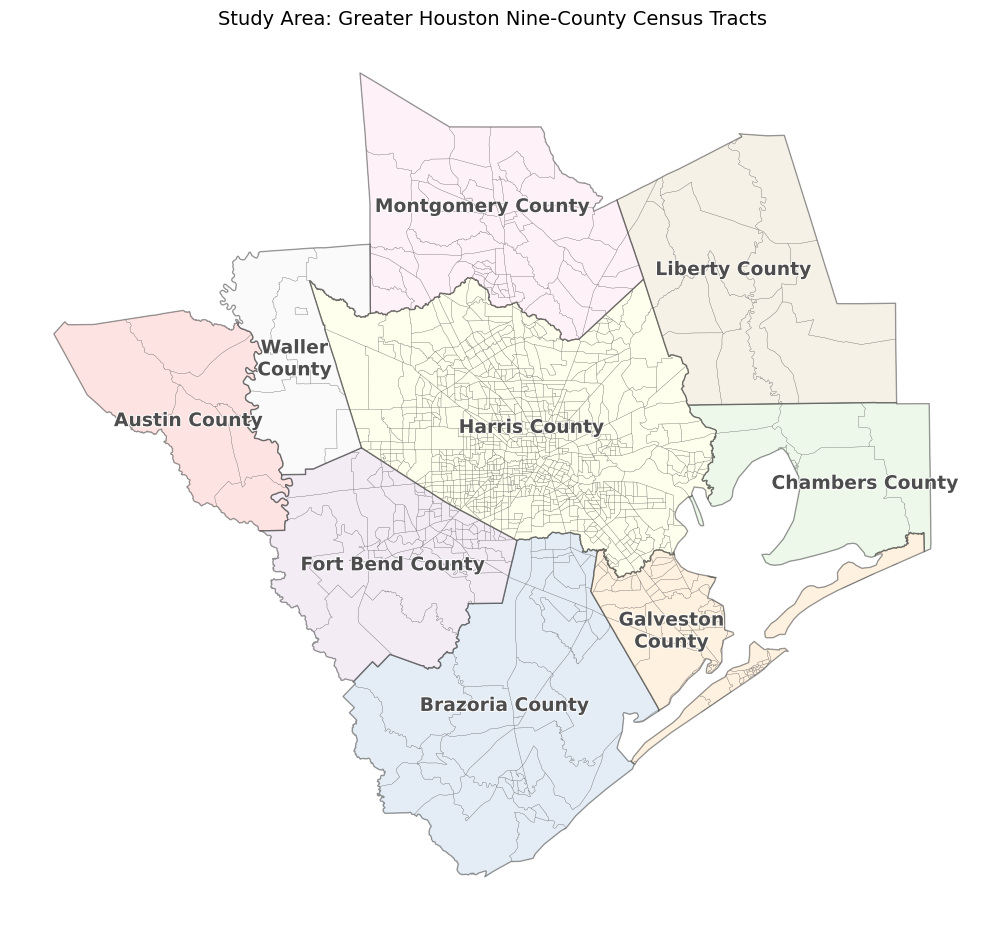

In [22]:
# Study Area Map with County Shading and Tract Boundaries
# Input: County polygons with label positions and census tract polygons for the nine-county region.
# Output: Study area map saved as PNG, SVG, and PDF.

from pathlib import Path
import re
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# ---------------------------------------------------------------------
# Fallback output-folder and figure-save setup if earlier setup cell was not run
# ---------------------------------------------------------------------

# Define the main project folder if it was not already created in an earlier cell
if "PROJECT_DIR" not in globals():
    PROJECT_DIR = Path("/content/drive/MyDrive/Census_Tract_Analysis_Project")

# Define the main manuscript-figure folder if it was not already created
if "FIGURE_ROOT_DIR" not in globals():
    FIGURE_ROOT_DIR = PROJECT_DIR / "Manuscript Figures"

# Define the folder for editable SVG files and vector PDF files
if "FIGURE_SOURCE_DIR" not in globals():
    FIGURE_SOURCE_DIR = FIGURE_ROOT_DIR / "Native SVG and PDF"

# Define the folder for high-resolution PNG image files
if "FIGURE_RASTER_DIR" not in globals():
    FIGURE_RASTER_DIR = FIGURE_ROOT_DIR / "Raster PNG"

# Define the folder for figure-related data tables
if "FIGURE_TABLE_DIR" not in globals():
    FIGURE_TABLE_DIR = FIGURE_ROOT_DIR / "Figure Data Tables"

# Define a helper function to make safe file names if it was not already created
if "clean_file_stem" not in globals():
    def clean_file_stem(stem):
        stem = str(stem).strip().replace(" ", "_")
        stem = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", stem)
        stem = re.sub(r"_+", "_", stem)
        return stem.strip("_")

# Define a helper function to create required output folders if needed
if "ensure_output_folders" not in globals():
    def ensure_output_folders():
        drive_root = Path("/content/drive/MyDrive")

        # Stop with a clear error if Google Drive is not mounted
        if not drive_root.exists():
            raise FileNotFoundError(
                "Google Drive does not appear to be mounted at /content/drive/MyDrive. "
                "Run the Google Drive mount cell first."
            )

        # Create each required output folder if it does not already exist
        for folder in [
            PROJECT_DIR,
            FIGURE_ROOT_DIR,
            FIGURE_SOURCE_DIR,
            FIGURE_RASTER_DIR,
            FIGURE_TABLE_DIR
        ]:
            folder.mkdir(parents=True, exist_ok=True)

        return True

# Define a helper function to save the same map in PNG, SVG, and PDF formats
if "save_figure_set" not in globals():
    def save_figure_set(fig, stem, dpi=600, bbox_inches="tight"):
        """
        Save one Matplotlib figure as:
        1. High-resolution PNG raster
        2. Native SVG vector
        3. Vector PDF
        """
        # Make sure output folders exist before saving files
        ensure_output_folders()

        # Clean the file stem so it is safe to use in saved file names
        stem = clean_file_stem(stem)

        # Define the full output paths for the three saved file formats
        png_path = FIGURE_RASTER_DIR / f"{stem}.png"
        svg_path = FIGURE_SOURCE_DIR / f"{stem}.svg"
        pdf_path = FIGURE_SOURCE_DIR / f"{stem}.pdf"

        # Save the map as a high-resolution PNG image
        fig.savefig(
            png_path,
            dpi=dpi,
            bbox_inches=bbox_inches,
            facecolor="white"
        )

        # Save the map as an editable SVG vector file
        fig.savefig(
            svg_path,
            format="svg",
            bbox_inches=bbox_inches,
            facecolor="white"
        )

        # Save the map as a vector PDF file
        fig.savefig(
            pdf_path,
            format="pdf",
            bbox_inches=bbox_inches,
            facecolor="white"
        )

        # Print the saved file paths for quick confirmation
        print(f"Saved: {png_path}")
        print(f"Saved: {svg_path}")
        print(f"Saved: {pdf_path}")

        # Return the saved file paths for possible later use
        return {
            "png": png_path,
            "svg": svg_path,
            "pdf": pdf_path
        }

# Confirm output folders exist before plotting/saving
ensure_output_folders()

# ---------------------------------------------------------------------
# Fallback county-label helper if earlier helper cell was not run
# ---------------------------------------------------------------------

# Define a helper function to add county names to the map if it was not already created
if "add_county_labels" not in globals():
    def add_county_labels(ax, county_gdf, fontsize=9):
        """
        Add county labels to a map.

        Uses an existing label_point column if available.
        Otherwise creates representative points from county geometry.
        """
        # Make a copy so the original county data is not changed
        label_gdf = county_gdf.copy()

        # Create label points inside each county if label points are not already available
        if "label_point" not in label_gdf.columns:
            label_gdf["label_point"] = label_gdf.geometry.representative_point()

        # Add one text label for each county
        for _, row in label_gdf.iterrows():
            county_name = str(row["NAME"])

            # Split longer county names onto two lines for better map readability
            if county_name == "Waller":
                label = "Waller\nCounty"
            elif county_name == "Galveston":
                label = "Galveston\nCounty"
            else:
                label = f"{county_name} County"

            # Place the county label at the county label point
            txt = ax.text(
                row["label_point"].x,
                row["label_point"].y,
                label,
                fontsize=fontsize,
                ha="center",
                va="center",
                color="black",
                weight="bold"
            )

            # Add a white outline around the label so it remains readable on the map
            txt.set_path_effects(
                [pe.withStroke(linewidth=1.4, foreground="white")]
            )

# ---------------------------------------------------------------------
# Validate required objects
# ---------------------------------------------------------------------

# Stop if the county boundary data has not been loaded yet
if "counties" not in globals():
    raise NameError("counties is not defined. Run the county-boundaries cell first.")

# Stop if the nine-county tract data has not been prepared yet
if "tracts9" not in globals():
    raise NameError("tracts9 is not defined. Run the tract filtering/preparation cell first.")

# ---------------------------------------------------------------------
# Plot study area map
# ---------------------------------------------------------------------

# Create the map canvas
fig, ax = plt.subplots(figsize=(10, 10))

# Draw county polygons with light shading and black county borders
counties.plot(
    ax=ax,
    column="NAME",
    cmap="Pastel1",
    edgecolor="black",
    linewidth=1.0,
    alpha=0.35
)

# Draw census tract boundaries within the counties
tracts9.boundary.plot(
    ax=ax,
    color="#666666",
    linewidth=0.15
)

# Add county labels to the map
add_county_labels(ax, counties, fontsize=13.5)

# Apply consistent county-label size and color
for text in ax.texts:
    text.set_fontsize(13.5)
    text.set_color("#4d4d4d")

# Add the map title
ax.set_title(
    "Study Area: Greater Houston Nine-County Census Tracts",
    fontsize=14
)

# Remove map axes so only the geography is shown
ax.set_axis_off()

# Adjust spacing so the map elements fit cleanly
plt.tight_layout()

# Save the completed map in PNG, SVG, and PDF formats
save_figure_set(fig, "Figure_1_study_area_map")

# Display the completed map
plt.show()

**Combined Diabetes and Obesity Prevalence Maps**

The following cell creates side-by-side maps showing diabetes prevalence and obesity prevalence across Greater Houston census tracts. It first imports plotting tools and sets consistent font sizes, legend sizes, and county label styling. A helper function is then defined to make county labels easier to read by adding a light outline behind the text.

The cell creates one map panel for diabetes prevalence and one map panel for obesity prevalence. Both maps use the same geographic extent so the two outcomes can be visually compared across the same study area. Census tracts are shaded using six quantile-based groups, meaning the tracts are divided into six groups with roughly similar numbers of tracts in each group. The diabetes map uses a yellow-to-red color scale, where lighter colors indicate lower prevalence and darker red colors indicate higher prevalence. The obesity map uses a reversed viridis color scale, where yellow/green colors indicate lower prevalence and darker blue/purple colors indicate higher prevalence.

County boundaries are added on top of the census tract maps to provide geographic reference. County names are also added and visually improved using the label readability function. Each map is given a clear title, map axes are hidden for a cleaner appearance, and the spacing between the two panels is adjusted so the final layout is compact and publication-ready.

Finally, the completed map set is saved using the project’s figure-saving function, which exports the map in PNG, SVG, and PDF formats. The cell then displays the final maps in the notebook.

Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/Figure_2_diabetes_obesity_prevalence_maps.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_2_diabetes_obesity_prevalence_maps.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_2_diabetes_obesity_prevalence_maps.pdf


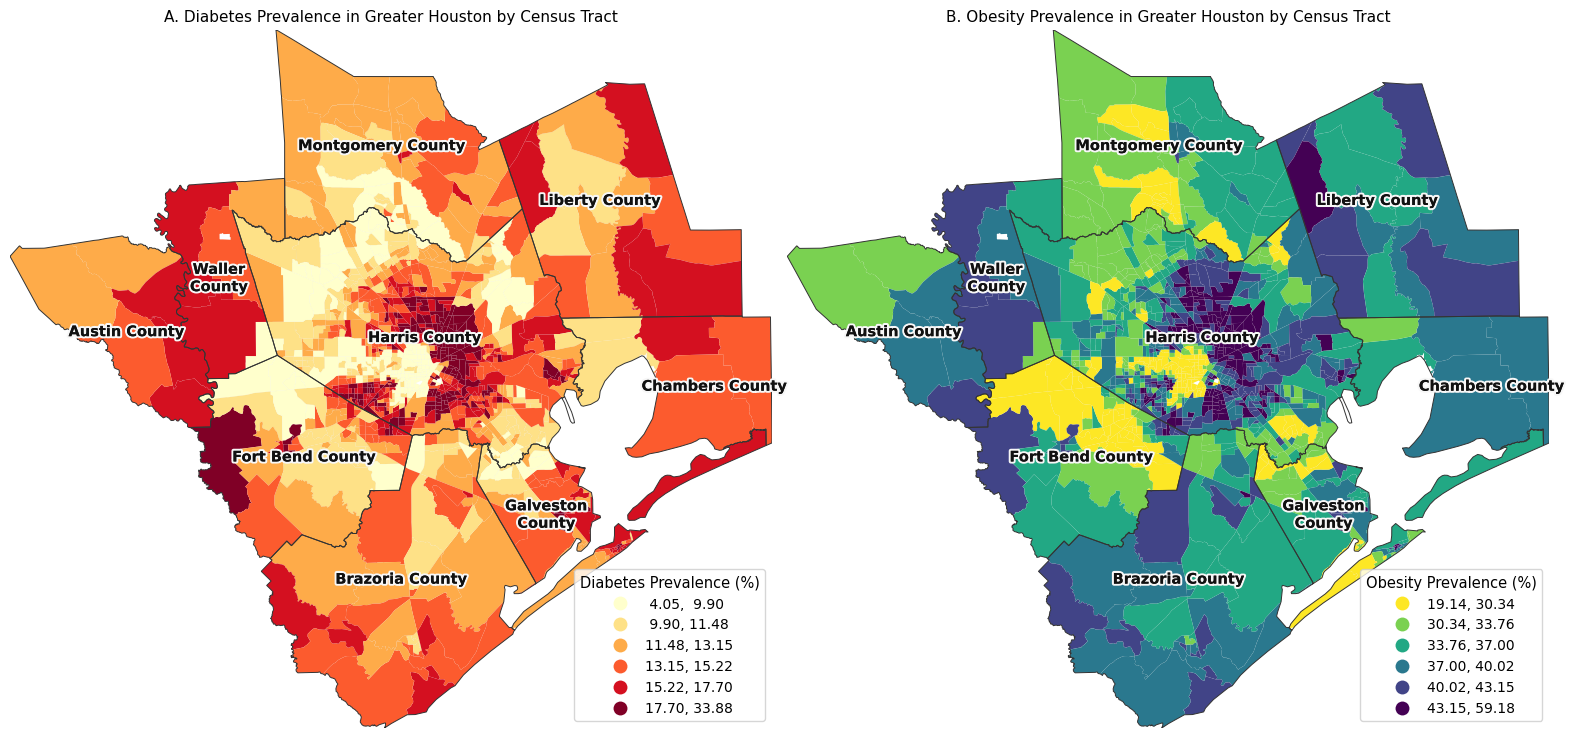

In [23]:
# Combined Diabetes and Obesity Prevalence Maps
# Input: Final geospatial dataset with diabetes and obesity prevalence estimates.
# Output: Combined diabetes and obesity prevalence maps saved as PNG, SVG, and PDF.

# Load plotting tools used to create the maps and improve label readability
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# ---------------------------------------------------------------------
# Create side-by-side tract-level maps for diabetes and obesity prevalence.
# The diabetes map uses a yellow-to-red scale.
# The obesity map uses a reversed viridis scale.
# Both maps use quantile classes so each color group contains a similar number of tracts.
# ---------------------------------------------------------------------

# Set county label and legend text sizes for consistent map formatting
county_label_fontsize = 10.5
legend_fontsize = 10
legend_title_fontsize = 10.5
county_label_halo_color = "#f7f7f7"

# Add a light outline around county labels so they remain readable on top of map colors
def improve_county_label_readability(ax):
    for text in ax.texts:
        text.set_fontsize(county_label_fontsize)
        text.set_color("#111111")
        text.set_path_effects(
            [
                pe.withStroke(
                    linewidth=3.0,
                    foreground=county_label_halo_color
                ),
                pe.Normal()
            ]
        )

# Create one row with two map panels
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 7.5)
)

# Get the full map boundary so both maps use the same geographic extent
xmin, ymin, xmax, ymax = gdf.total_bounds

# ---------------------------------------------------------------------
# Diabetes prevalence map
# ---------------------------------------------------------------------

# Plot census tracts by diabetes prevalence using six quantile-based color groups
gdf.plot(
    column="diabetes_pct",
    scheme="quantiles",
    k=6,
    cmap="YlOrRd",
    legend=True,
    edgecolor="#d9d9d9",
    linewidth=0.02,
    ax=axes[0],
    legend_kwds={
        "title": "Diabetes Prevalence (%)",
        "loc": "lower right",
        "fontsize": legend_fontsize,
        "title_fontsize": legend_title_fontsize
    }
)

# Add county boundary lines on top of the tract map
counties.boundary.plot(
    ax=axes[0],
    color="#333333",
    linewidth=0.7
)

# Add county names and improve their readability
add_county_labels(axes[0], counties, fontsize=county_label_fontsize)
improve_county_label_readability(axes[0])

# Add the map title
axes[0].set_title(
    "A. Diabetes Prevalence in Greater Houston by Census Tract",
    fontsize=11
)

# Use the same map limits as the full study area and remove axis markings
axes[0].set_xlim(xmin, xmax)
axes[0].set_ylim(ymin, ymax)
axes[0].set_axis_off()

# ---------------------------------------------------------------------
# Obesity prevalence map
# ---------------------------------------------------------------------

# Plot census tracts by obesity prevalence using six quantile-based color groups
gdf.plot(
    column="obesity_pct",
    scheme="quantiles",
    k=6,
    cmap="viridis_r",
    legend=True,
    edgecolor="#d9d9d9",
    linewidth=0.02,
    ax=axes[1],
    legend_kwds={
        "title": "Obesity Prevalence (%)",
        "loc": "lower right",
        "fontsize": legend_fontsize,
        "title_fontsize": legend_title_fontsize
    }
)

# Add county boundary lines on top of the tract map
counties.boundary.plot(
    ax=axes[1],
    color="#333333",
    linewidth=0.7
)

# Add county names and improve their readability
add_county_labels(axes[1], counties, fontsize=county_label_fontsize)
improve_county_label_readability(axes[1])

# Add the map title
axes[1].set_title(
    "B. Obesity Prevalence in Greater Houston by Census Tract",
    fontsize=11
)

# Use the same map limits as the full study area and remove axis markings
axes[1].set_xlim(xmin, xmax)
axes[1].set_ylim(ymin, ymax)
axes[1].set_axis_off()

# Adjust spacing so the two maps fit cleanly together
plt.tight_layout()
plt.subplots_adjust(wspace=0.02)

# Save the completed map in raster and vector formats, then display it
save_figure_set(fig, "Figure_2_diabetes_obesity_prevalence_maps")
plt.show()

**High-Burden Overlap Map by Census Tract**

The following cell creates a map showing where diabetes and obesity high-burden overlap occurs across census tracts. It uses the final geospatial dataset, `gdf`, which already contains the `high_burden_overlap` indicator. This cell does not calculate the overlap indicator; it only maps the result.

First, the cell creates a square map layout using Matplotlib. It then plots all census tracts in light gray to provide geographic context. Next, it filters the dataset to keep only tracts where `high_burden_overlap` equals 1. These are the tracts that were in the highest 20% for both diabetes and obesity estimates. If any such tracts are present, they are plotted on top of the background tracts in dark red.

The cell also adds county boundary lines to make the regional layout easier to understand. County labels are added and formatted so they are readable but not visually dominant. A legend is included to distinguish high-burden overlap tracts from all other tracts. The map title is added, the map axes are removed for a cleaner appearance, and the layout is tightened to reduce extra blank space.

Finally, the completed map is saved using `save_figure_set`, which exports the same map in the project’s standard output formats, and then displays the map in the notebook.

Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/Figure_3_high_burden_overlap_tracts.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_3_high_burden_overlap_tracts.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_3_high_burden_overlap_tracts.pdf


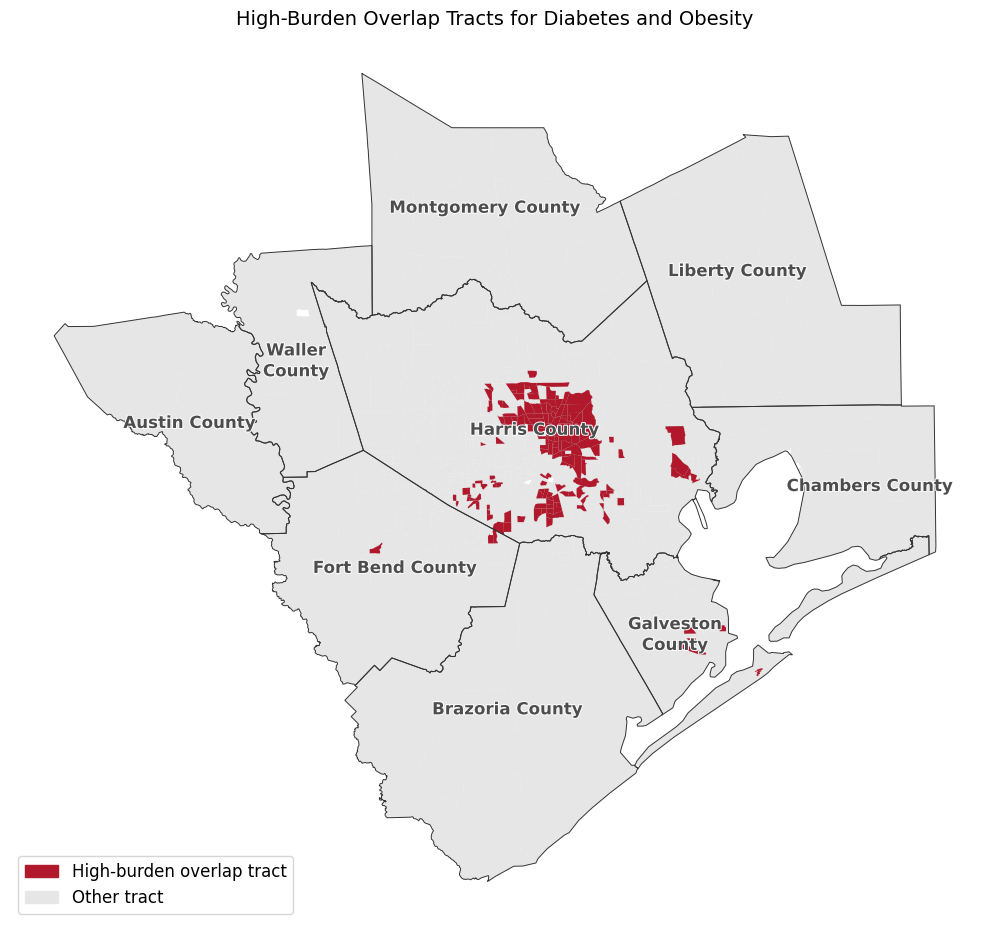

In [24]:
# High-Burden Overlap Map by Census Tract
# Input: Final geospatial dataset with high_burden_overlap indicator.
# Output: Map showing tracts in the highest 20% for both diabetes and obesity estimates.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create the map canvas
fig, ax = plt.subplots(figsize=(10, 10))

# Plot all census tracts as the light gray background
gdf.plot(
    ax=ax,
    color="#e6e6e6",
    edgecolor="#cccccc",
    linewidth=0.02
)

# Select only tracts classified as high-burden overlap tracts
overlap_gdf = gdf.loc[gdf["high_burden_overlap"] == 1]

# Plot high-burden overlap tracts in red if any are present
if not overlap_gdf.empty:
    overlap_gdf.plot(
        ax=ax,
        color="#b2182b",
        edgecolor="#666666",
        linewidth=0.03
    )

# Add county boundaries on top of the tract map
counties.boundary.plot(
    ax=ax,
    color="#333333",
    linewidth=0.7
)

# Add county names to the map
add_county_labels(ax, counties, fontsize=12)

# Format county label color and size for readability
for text in ax.texts:
    text.set_color("#4d4d4d")
    text.set_fontsize(12)

# Create legend labels for high-burden overlap and other tracts
legend_handles = [
    mpatches.Patch(color="#b2182b", label="High-burden overlap tract"),
    mpatches.Patch(color="#e6e6e6", label="Other tract")
]

# Add the legend to the lower-left corner
ax.legend(
    handles=legend_handles,
    loc="lower left",
    fontsize=12
)

# Add the map title
ax.set_title(
    "High-Burden Overlap Tracts for Diabetes and Obesity",
    fontsize=14
)

# Remove map axes for a cleaner manuscript-style map
ax.set_axis_off()

# Adjust spacing around the map
plt.tight_layout()

# Save the map as PNG, SVG, and PDF using the project save function
save_figure_set(fig, "Figure_3_high_burden_overlap_tracts")

# Display the map in the notebook
plt.show()

**Getis-Ord Gi\* High-Cluster Map**

The following cell creates a map of statistically significant local high clusters for the combined diabetes-obesity score. It first checks that all required Gi* analysis columns are present in the GeoDataFrame. These include the composite score, Gi* z-scores, nominal Gi* p-values, FDR-adjusted p-values, high-cluster indicators, and the high-burden overlap indicator.

The cell then performs a quality check before plotting. If any nominal Gi* high clusters exist, it compares their median composite score with the median composite score of all other tracts. This helps confirm that the areas being mapped as “high clusters” actually have higher combined diabetes-obesity burden than the remaining tracts. If this condition is not met, the cell stops instead of producing a potentially misleading map.

After validation, the cell plots all census tracts in light gray as the background. It then adds high-burden overlap tracts that are not Gi* high clusters in yellow. Next, it adds nominally significant Gi* high clusters in light red. Finally, it adds FDR-significant Gi* high clusters in dark red, so the strongest and most statistically conservative clusters appear on top.

The cell also adds county boundaries and county labels to make the map easier to interpret geographically. It formats the label color and size for readability, creates a legend explaining each tract classification, removes the map axes, and adds a descriptive title.

At the end, the cell saves the map using the project’s standard figure-saving function and displays the final map in the notebook.

Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/Figure_4_getis_ord_gi_star_high_clusters.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_4_getis_ord_gi_star_high_clusters.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_4_getis_ord_gi_star_high_clusters.pdf


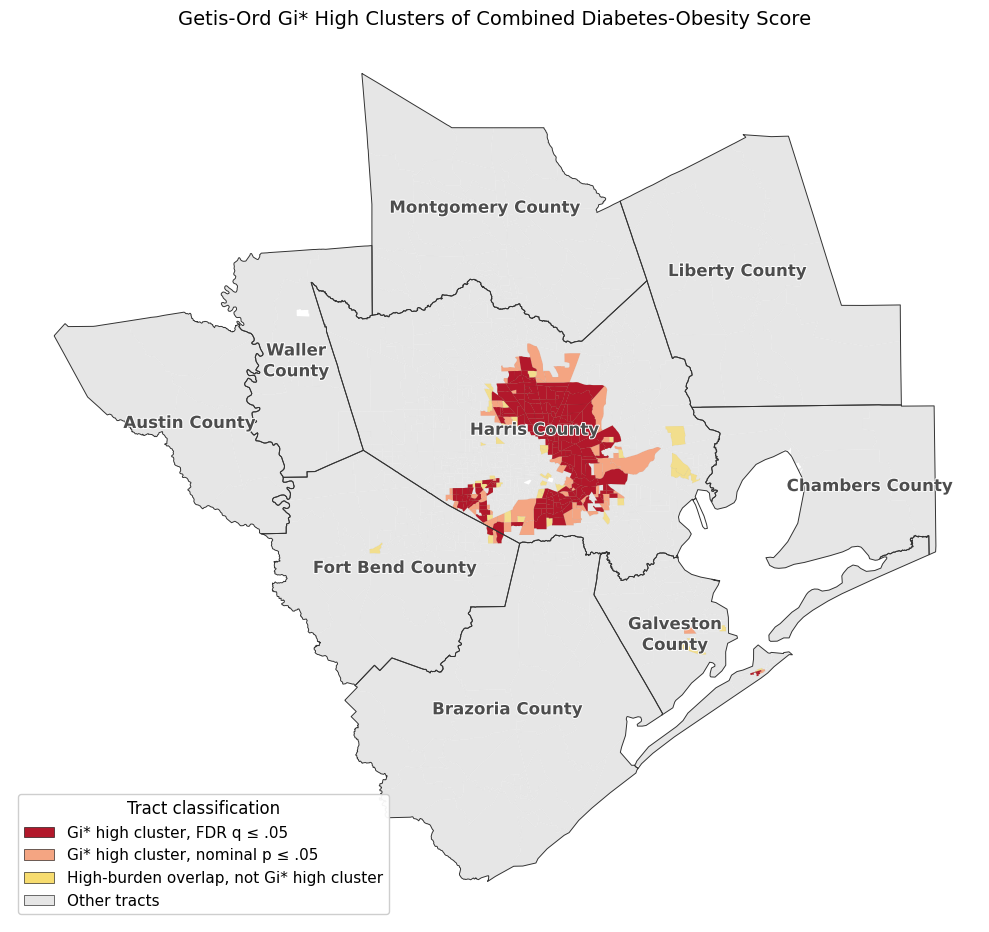

In [25]:
# Getis-Ord Gi* High-Cluster Map
# Input: gdf with corrected gi_star_high_cluster_p05 and gi_star_high_cluster_fdr05.
# Output: Figure 4 map showing statistically significant local high clusters using the unified composite.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------------------
# Validate Gi* columns
# ---------------------------------------------------------------------

# List the columns required to make the Gi* high-cluster map
required_cols = [
    "composite",
    "gi_star_z",
    "gi_star_p",
    "gi_star_p_fdr",
    "gi_star_high_cluster_p05",
    "gi_star_high_cluster_fdr05",
    "high_burden_overlap"
]

# Check whether any required columns are missing from the analysis dataset
missing_cols = [c for c in required_cols if c not in gdf.columns]

# Stop the code if the Gi* results have not been created yet
if missing_cols:
    raise KeyError(
        "Missing Gi* columns. Run the updated Gi* analysis cell first. "
        f"Missing: {missing_cols}"
    )

# Confirm that nominal Gi* high-cluster tracts have higher composite scores than other tracts
if int(gdf["gi_star_high_cluster_p05"].sum()) > 0:
    median_high = gdf.loc[gdf["gi_star_high_cluster_p05"] == 1, "composite"].median()
    median_other = gdf.loc[gdf["gi_star_high_cluster_p05"] == 0, "composite"].median()

    # Stop the code if the mapped high clusters do not actually represent higher-burden areas
    if median_high <= median_other:
        raise ValueError(
            "Not plotting: Gi* high clusters do not have higher median composite than other tracts."
        )

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

# Create a square map canvas
fig, ax = plt.subplots(figsize=(10, 10))

# Plot all census tracts in light gray as the background layer
gdf.plot(
    ax=ax,
    color="#e6e6e6",
    edgecolor="#cccccc",
    linewidth=0.02
)

# Select high-burden overlap tracts that are not Gi* high clusters
high_burden_not_gi = gdf.loc[
    (gdf["high_burden_overlap"] == 1) &
    (gdf["gi_star_high_cluster_p05"] == 0)
]

# Add high-burden overlap tracts that did not meet the Gi* high-cluster threshold
if not high_burden_not_gi.empty:
    high_burden_not_gi.plot(
        ax=ax,
        color="#f7dc6f",
        edgecolor="#666666",
        linewidth=0.03,
        alpha=0.75
    )

# Select tracts that are Gi* high clusters at the nominal p ≤ .05 level
nominal_high = gdf.loc[gdf["gi_star_high_cluster_p05"] == 1]

# Add nominal Gi* high-cluster tracts to the map
if not nominal_high.empty:
    nominal_high.plot(
        ax=ax,
        color="#f4a582",
        edgecolor="#666666",
        linewidth=0.03
    )

# Select tracts that remain Gi* high clusters after FDR correction
fdr_high = gdf.loc[gdf["gi_star_high_cluster_fdr05"] == 1]

# Add the strongest Gi* high-cluster tracts on top of the nominal cluster layer
if not fdr_high.empty:
    fdr_high.plot(
        ax=ax,
        color="#b2182b",
        edgecolor="#333333",
        linewidth=0.04
    )

# Add county boundaries to show the study-area context
counties.boundary.plot(
    ax=ax,
    color="#333333",
    linewidth=0.7
)

# Add county names to the map
add_county_labels(ax, counties, fontsize=12)

# Format county label color and size for readability
for text in ax.texts:
    text.set_color("#4d4d4d")
    text.set_fontsize(12)

# Create legend entries for each tract classification shown on the map
legend_handles = [
    mpatches.Patch(
        facecolor="#b2182b",
        edgecolor="black",
        linewidth=0.4,
        label="Gi* high cluster, FDR q ≤ .05"
    ),
    mpatches.Patch(
        facecolor="#f4a582",
        edgecolor="black",
        linewidth=0.4,
        label="Gi* high cluster, nominal p ≤ .05"
    ),
    mpatches.Patch(
        facecolor="#f7dc6f",
        edgecolor="black",
        linewidth=0.4,
        label="High-burden overlap, not Gi* high cluster"
    ),
    mpatches.Patch(
        facecolor="#e6e6e6",
        edgecolor="black",
        linewidth=0.4,
        label="Other tracts"
    )
]

# Add the legend to explain the tract categories
ax.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=True,
    framealpha=0.95,
    title="Tract classification",
    title_fontsize=12,
    fontsize=11
)

# Add a clear map title
ax.set_title(
    "Getis-Ord Gi* High Clusters of Combined Diabetes-Obesity Score",
    fontsize=14
)

# Remove map axes because latitude and longitude labels are not needed here
ax.set_axis_off()

# Tighten spacing around the map before saving and displaying it
plt.tight_layout()

# Save the map as PNG, SVG, and PDF using the project figure-saving function
save_figure_set(fig, "Figure_4_getis_ord_gi_star_high_clusters")

# Display the completed map
plt.show()

**Boxplot of Social Vulnerability by High-Burden Overlap Status**

The following cell creates a boxplot comparing overall Social Vulnerability Index (SVI) percentile values between high-burden overlap tracts and all other tracts. It first separates the tract-level data into two groups based on the `high_burden_overlap` indicator, then removes missing SVI values before plotting. The boxplot summarizes the distribution of SVI values in each group, including the median, spread, whiskers, and any outlying values. The high-burden overlap group is shown in red, and the other tracts are shown in gray. The y-axis is limited to the valid SVI percentile range from 0 to 1. The cell also adds the sample size for each group below the x-axis labels so the comparison shows both the distribution and the number of tracts included. Finally, the completed plot is formatted, saved using the project’s figure-saving function, and displayed.

/tmp/ipykernel_512/699814815.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/Figure_6_svi_by_high_burden_overlap_status.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_6_svi_by_high_burden_overlap_status.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_6_svi_by_high_burden_overlap_status.pdf


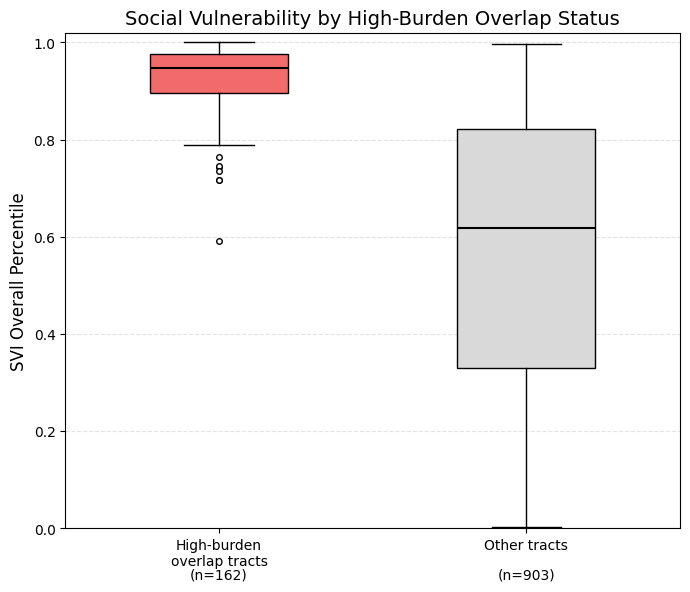

In [26]:
# Boxplot of Social Vulnerability by High-Burden Overlap Status
# Input: Social vulnerability scores grouped by high-burden overlap status.
# Output: Boxplot comparing SVI values between high-burden overlap and other tracts.

# Load plotting tools
import matplotlib.pyplot as plt

# Create the figure and plotting area
fig, ax = plt.subplots(figsize=(7, 6))

# Separate SVI values into high-burden overlap tracts and other tracts
plot_data = [
    gdf.loc[gdf["high_burden_overlap"] == 1, "rpl_themes"].dropna(),
    gdf.loc[gdf["high_burden_overlap"] == 0, "rpl_themes"].dropna()
]

# Create the boxplot for the two tract groups
bp = ax.boxplot(
    plot_data,
    labels=["High-burden\noverlap tracts", "Other tracts"],
    patch_artist=True,
    widths=0.45,
    showfliers=True,
    flierprops=dict(
        marker="o",
        markersize=4,
        markerfacecolor="white",
        markeredgecolor="black",
        linestyle="none"
    )
)

# Set the box colors for the two groups
bp["boxes"][0].set(facecolor="#f26b6b", edgecolor="black", linewidth=1.0)
bp["boxes"][1].set(facecolor="#d9d9d9", edgecolor="black", linewidth=1.0)

# Format the whisker lines
for whisker in bp["whiskers"]:
    whisker.set(color="black", linewidth=1.0)

# Format the end caps of the whiskers
for cap in bp["caps"]:
    cap.set(color="black", linewidth=1.0)

# Format the median lines inside each box
for median in bp["medians"]:
    median.set(color="black", linewidth=1.5)

# Add the plot title
ax.set_title(
    "Social Vulnerability by High-Burden Overlap Status",
    fontsize=14
)

# Label the y-axis and keep the SVI scale within its expected 0 to 1 range
ax.set_ylabel("SVI Overall Percentile", fontsize=12)
ax.set_ylim(0, 1.02)

# Add light horizontal grid lines to make SVI values easier to compare
ax.grid(axis="y", linestyle="--", alpha=0.35)

# Count the number of tracts in each group
n0 = int((gdf["high_burden_overlap"] == 0).sum())
n1 = int((gdf["high_burden_overlap"] == 1).sum())

# Add the sample size below the high-burden overlap group
ax.text(
    1,
    -0.08,
    f"(n={n1})",
    ha="center",
    va="top",
    transform=ax.get_xaxis_transform(),
    fontsize=10
)

# Add the sample size below the other tracts group
ax.text(
    2,
    -0.08,
    f"(n={n0})",
    ha="center",
    va="top",
    transform=ax.get_xaxis_transform(),
    fontsize=10
)

# Adjust spacing so labels and sample sizes are not cut off
plt.tight_layout()

# Save the figure as PNG, SVG, and PDF using the project save function
save_figure_set(fig, "Figure_6_svi_by_high_burden_overlap_status")

# Display the finished plot
plt.show()

**Moran Scatterplot for the Combined Diabetes-Obesity Score**

The following cell creates a Moran scatterplot to show whether census tracts with similar combined diabetes-obesity scores tend to be located near each other. It first calculates the average combined score of each tract’s neighboring tracts using the row-standardized spatial weights already created for the Moran’s I analysis. This neighbor average is saved as a new column called `lag_composite`.

The plot compares each tract’s own combined diabetes-obesity score on the x-axis with the average score of its neighboring tracts on the y-axis. Each point represents one census tract. Points higher on the plot have neighbors with higher combined scores, while points lower on the plot have neighbors with lower combined scores.

The cell also adds a best-fit line to summarize the overall relationship between each tract’s score and the scores of nearby tracts. An upward-sloping line supports positive spatial clustering, meaning high-score tracts tend to be near other high-score tracts and low-score tracts tend to be near other low-score tracts.

Finally, the cell formats the plot with clear axis labels, a grid, and a title, then saves the completed scatterplot in PNG, SVG, and PDF formats for use in the manuscript and supporting materials.

Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/Figure_8_moran_scatterplot.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_8_moran_scatterplot.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_8_moran_scatterplot.pdf


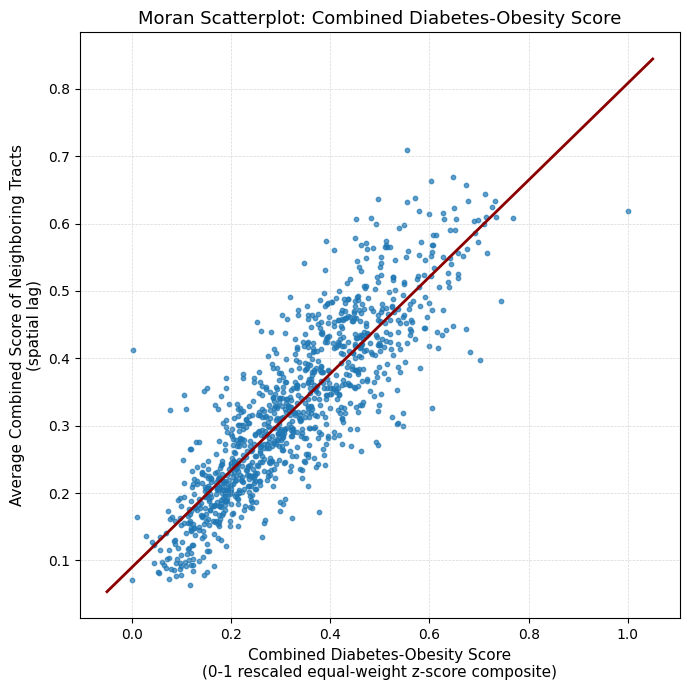

In [27]:
# Moran Scatterplot for Composite Diabetes-Obesity Score
# Input: Unified composite tract score and spatial weights defining neighboring tracts.
# Output: Moran scatterplot saved as PNG, SVG, and PDF.

# Import the tool used to calculate the average value among neighboring tracts
from libpysal.weights import lag_spatial

# Import plotting tools used to create and format the scatterplot
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Import NumPy for fitting the trend line
import numpy as np

# Compute the average composite score of neighboring tracts for each tract
gdf["lag_composite"] = lag_spatial(w, gdf["composite"])

# Create the plotting area
fig, ax = plt.subplots(figsize=(7, 7))

# Plot each tract by its own composite score and the average score of its neighbors
ax.scatter(
    gdf["composite"],
    gdf["lag_composite"],
    s=10,
    alpha=0.7
)

# Store the data ranges for the tract scores and neighboring-tract scores
xmin, xmax = gdf["composite"].min(), gdf["composite"].max()
ymin, ymax = gdf["lag_composite"].min(), gdf["lag_composite"].max()

# Add a light grid to make the scatterplot easier to read
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

# Fit a straight trend line showing the overall relationship between tracts and their neighbors
m, b_line = np.polyfit(gdf["composite"], gdf["lag_composite"], 1)

# Get the current x-axis range for drawing the trend line across the plot
x_vals = np.array(ax.get_xlim())

# Add the trend line to the scatterplot
ax.plot(x_vals, m * x_vals + b_line, color="darkred", linewidth=2)

# Add the plot title
ax.set_title("Moran Scatterplot: Combined Diabetes-Obesity Score", fontsize=13)

# Label the x-axis as the tract-level combined diabetes-obesity score
ax.set_xlabel(
    "Combined Diabetes-Obesity Score\n"
    "(0-1 rescaled equal-weight z-score composite)",
    fontsize=11
)

# Label the y-axis as the average combined score of neighboring tracts
ax.set_ylabel(
    "Average Combined Score of Neighboring Tracts\n"
    "(spatial lag)",
    fontsize=11
)

# Adjust spacing so labels and titles are not cut off
plt.tight_layout()

# Save the scatterplot in the manuscript figure output folders
save_figure_set(fig, "Figure_8_moran_scatterplot")

# Display the scatterplot in the notebook
plt.show()

**Social Vulnerability Map by Census Tract**

The following cell creates a map of Social Vulnerability Index (SVI) overall percentile values by census tract. It uses the final geospatial dataset, `gdf`, and maps the `rpl_themes` column, where higher values represent higher overall social vulnerability.

The tract values are divided into six quantile groups so that each color category contains approximately the same number of census tracts. The green color scale shows lower-to-higher SVI percentile values, with darker green areas representing higher social vulnerability. Tracts with missing SVI values are shown in light gray with hatching so they can be identified separately from valid low-SVI tracts.

The cell also adds county boundary outlines on top of the tract map to make the regional context clearer. County labels are added using the `add_county_labels()` helper function, and the label color and font size are adjusted for readability.

The map title is added, the map axes are removed, and the layout is tightened so the saved output has clean spacing. Finally, the `save_figure_set()` helper function saves the completed map in PNG, SVG, and PDF formats for use in the manuscript, presentations, or later editing. The plot is then displayed in the notebook.

Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/Figure_5_social_vulnerability_index_map.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_5_social_vulnerability_index_map.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_5_social_vulnerability_index_map.pdf


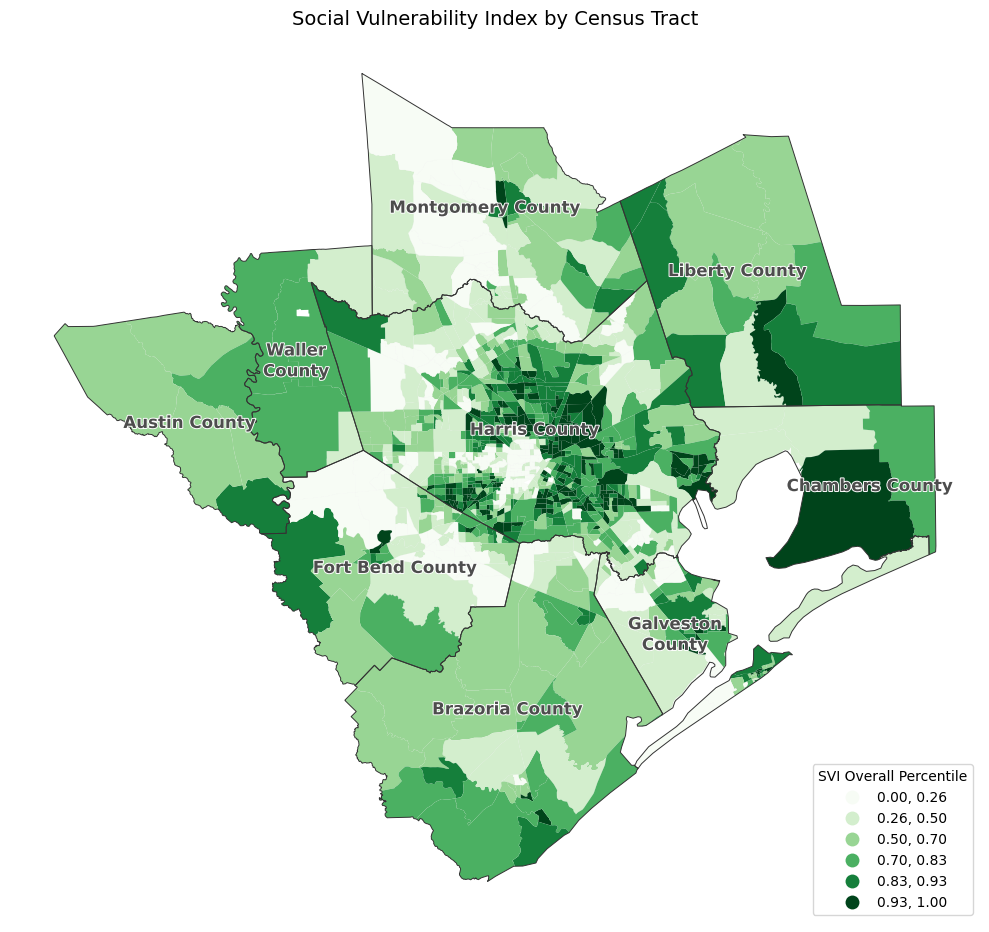

In [28]:
# Social Vulnerability Map by Census Tract
# Input: Final geospatial dataset with SVI overall percentile.
# Output: Tract-level SVI map saved as PNG, SVG, and PDF.

import matplotlib.pyplot as plt

# Create the map canvas
fig, ax = plt.subplots(figsize=(10, 10))

# Plot census tracts using SVI overall percentile grouped into six equal-count classes
gdf.plot(
    column="rpl_themes",
    scheme="quantiles",
    k=6,
    cmap="Greens",
    legend=True,
    edgecolor="#d9d9d9",
    linewidth=0.02,
    ax=ax,
    legend_kwds={
        "title": "SVI Overall Percentile",
        "loc": "lower right",
        "fontsize": 10,
        "title_fontsize": 10
    },
    missing_kwds={
        "color": "#f0f0f0",
        "edgecolor": "#d9d9d9",
        "hatch": "///",
        "label": "Missing"
    }
)

# Add county boundary lines so county outlines are visible on top of the tract map
counties.boundary.plot(
    ax=ax,
    color="#333333",
    linewidth=0.7
)

# Add county names to the map
add_county_labels(ax, counties, fontsize=12)

# Adjust county label color and size for readability
for text in ax.texts:
    text.set_color("#4d4d4d")
    text.set_fontsize(12)

# Add a clear map title
ax.set_title(
    "Social Vulnerability Index by Census Tract",
    fontsize=14
)

# Remove axes because map coordinates are not needed for this manuscript figure
ax.set_axis_off()

# Adjust spacing so the map, title, and legend fit cleanly
plt.tight_layout()

# Save the map in raster, editable SVG, and vector PDF formats
save_figure_set(fig, "Figure_5_social_vulnerability_index_map")

# Display the completed map in the notebook
plt.show()

**Map of LILA and High-Burden Overlap Census Tracts**

The following cell creates an overlay map showing how Low-Income, Low-Access (LILA) census tracts relate to census tracts with high combined diabetes-obesity burden. It first converts the LILA indicator and high-burden overlap indicator into clean 0/1 values, so missing or nonnumeric values do not affect the map. Each census tract is then assigned to one of four categories: tracts that are both high-burden overlap and LILA, high-burden overlap only, LILA only, or neither.

The cell then defines a color for each category and plots the census tracts in a specific order so that the most important overlap category is drawn last and remains visible. County boundaries and county labels are added on top of the tract map to make the geography easier to interpret. A custom legend is created so the map categories are clearly labeled. Finally, the map title and formatting are applied, the map axes are removed, the figure is saved using the standard figure-saving function, and the map is displayed.

Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG/Figure_7_lila_and_high_burden_overlap_map.png
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_7_lila_and_high_burden_overlap_map.svg
Saved: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF/Figure_7_lila_and_high_burden_overlap_map.pdf


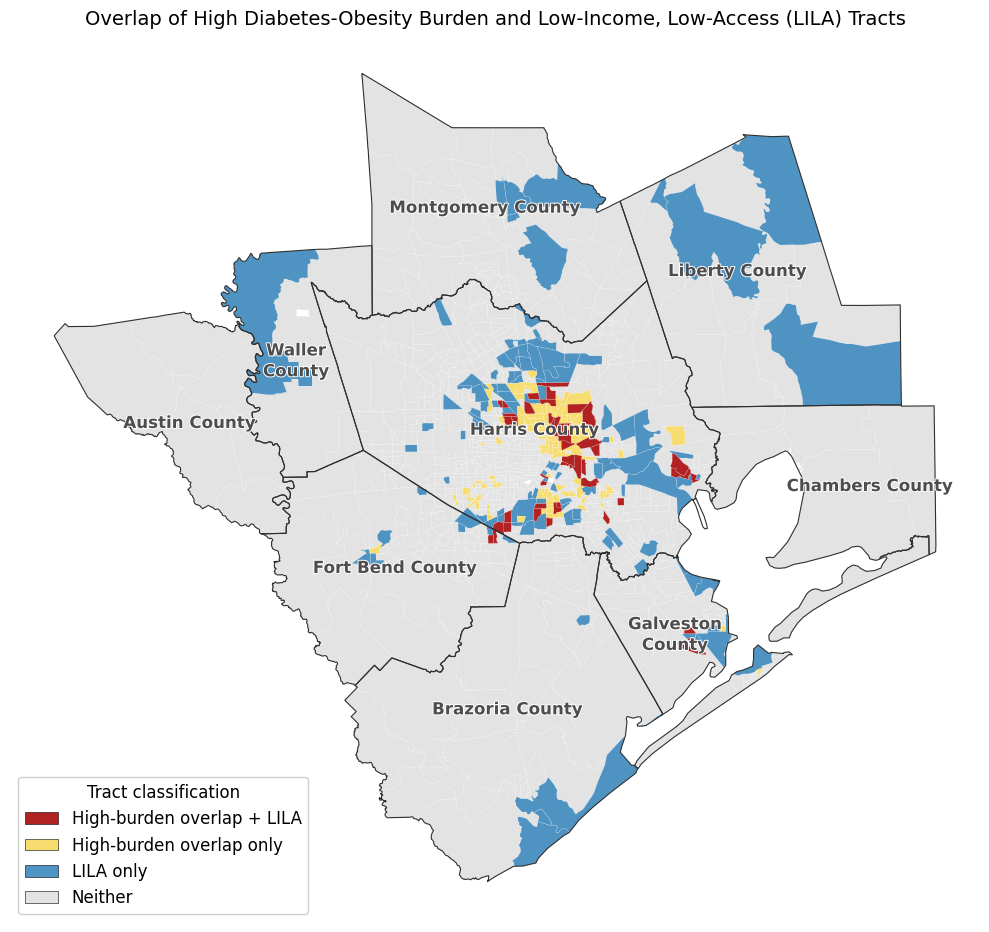

In [29]:
# Map of Low-Income, Low-Access (LILA) and High-Burden Overlap Census Tracts
# Input: Final geospatial dataset with LILA and high-burden overlap indicators.
# Output: Overlay map showing LILA-only, high-burden-only, overlapping, and neither tracts.

# Import plotting tools, legend tools, and data handling libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Build plotting flags
# ---------------------------------------------------------------------

# Convert the LILA indicator to a clean 0/1 flag
lila_flag = pd.to_numeric(gdf["lila_1and10"], errors="coerce").fillna(0).astype(int)

# Convert the high-burden overlap indicator to a clean 0/1 flag
overlap_flag = pd.to_numeric(gdf["high_burden_overlap"], errors="coerce").fillna(0).astype(int)

# Classify each tract based on whether it is LILA, high-burden overlap, both, or neither
gdf["lila_overlap_plot_class"] = np.select(
    [
        (lila_flag == 1) & (overlap_flag == 1),
        (lila_flag == 0) & (overlap_flag == 1),
        (lila_flag == 1) & (overlap_flag == 0)
    ],
    [
        "High-burden overlap + LILA",
        "High-burden overlap only",
        "LILA only"
    ],
    default="Neither"
)

# ---------------------------------------------------------------------
# Updated color palette
# ---------------------------------------------------------------------

# Assign one map color to each tract classification
plot_colors = {
    "Neither": "#e3e3e3",
    "LILA only": "#4f93c2",
    "High-burden overlap only": "#f7dc6f",
    "High-burden overlap + LILA": "#b22222"
}

# ---------------------------------------------------------------------
# Plot map
# ---------------------------------------------------------------------

# Create the map canvas
fig, ax = plt.subplots(figsize=(10, 10))

# Plot in order so the most important class is drawn last
plot_order = [
    "Neither",
    "LILA only",
    "High-burden overlap only",
    "High-burden overlap + LILA"
]

# Draw each tract group using its assigned color
for class_name in plot_order:
    subset = gdf.loc[gdf["lila_overlap_plot_class"] == class_name]

    # Skip the class if no tracts fall into that group
    if not subset.empty:
        subset.plot(
            ax=ax,
            color=plot_colors[class_name],
            edgecolor="white",
            linewidth=0.10
        )

# County boundaries on top
counties.boundary.plot(
    ax=ax,
    color="#2f2f2f",
    linewidth=0.8
)

# County labels
add_county_labels(ax, counties, fontsize=12)

# Format county label color and size for readability
for text in ax.texts:
    text.set_color("#4d4d4d")
    text.set_fontsize(12)

# ---------------------------------------------------------------------
# Legend
# ---------------------------------------------------------------------

# Create legend entries that match the map colors
legend_handles = [
    mpatches.Patch(
        facecolor=plot_colors["High-burden overlap + LILA"],
        edgecolor="black",
        linewidth=0.4,
        label="High-burden overlap + LILA"
    ),
    mpatches.Patch(
        facecolor=plot_colors["High-burden overlap only"],
        edgecolor="black",
        linewidth=0.4,
        label="High-burden overlap only"
    ),
    mpatches.Patch(
        facecolor=plot_colors["LILA only"],
        edgecolor="black",
        linewidth=0.4,
        label="LILA only"
    ),
    mpatches.Patch(
        facecolor=plot_colors["Neither"],
        edgecolor="black",
        linewidth=0.4,
        label="Neither"
    )
]

# Add the legend to the lower-left corner of the map
ax.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=True,
    framealpha=0.95,
    title="Tract classification",
    title_fontsize=12,
    fontsize=12
)

# ---------------------------------------------------------------------
# Title and formatting
# ---------------------------------------------------------------------

# Add a clear map title
ax.set_title(
    "Overlap of High Diabetes-Obesity Burden and Low-Income, Low-Access (LILA) Tracts",
    fontsize=14
)

# Remove map axes so only the geography is shown
ax.set_axis_off()

# Adjust spacing so the title, legend, and map fit cleanly
plt.tight_layout()

# Save the map as PNG, SVG, and PDF using the standard project function
save_figure_set(fig, "Figure_7_lila_and_high_burden_overlap_map")

# Display the completed map
plt.show()

**Sensitivity Analysis for Alternative High-Burden Thresholds**

The following cell checks whether the main study findings remain consistent when the definition of “high burden” is changed. The main analysis defines high-burden overlap tracts using the 80th percentile cutoff for both diabetes and obesity. This cell repeats the same logic using 75th, 80th, and 85th percentile cutoffs.

First, the cell copies the final analysis dataset so the sensitivity analysis can be run without changing the original working dataset. It then identifies the census tract GEOID column, which is needed to compare which tracts are included under each threshold. If the expected GEOID column is not found, the code searches for another column containing “geoid” in its name. If no tract identifier is found, the cell stops with an error.

The cell also saves the tract list from the main 80th percentile high-burden overlap definition. This is used as the primary comparison group. For each alternative threshold, the cell calculates new diabetes and obesity percentile cutoffs, flags tracts at or above each cutoff, and then identifies tracts that are high for both diabetes and obesity. These new flags are also added back to the main `gdf` dataset for optional later export or mapping.

For each threshold, the cell calculates how many tracts are classified as high diabetes burden, high obesity burden, and high-burden overlap. It also counts how many of the overlap tracts match the original primary 80th percentile overlap group. This helps show whether the high-burden tract classification is stable when the cutoff is made broader or stricter.

The cell then compares Social Vulnerability Index values between the high-burden overlap tracts and all other tracts. It reports the median SVI for both groups and runs a Mann-Whitney U test to check whether the SVI difference between the two groups is statistically significant.

Next, the cell evaluates whether high-burden overlap tracts are more likely to be classified as Low-Income, Low-Access tracts. It creates a two-by-two table comparing overlap status and LILA status, then runs a chi-square test. The code also calculates the risk ratio and odds ratio, along with 95% confidence intervals, to estimate the strength of the association between high-burden overlap status and LILA status.

The helper function calculates the risk ratio, odds ratio, and their confidence intervals from the two-by-two table counts. If any count is zero, the function returns missing values instead of forcing an unstable calculation.

Finally, the cell combines all threshold results into one summary table and displays it. This table is used to check whether the main conclusions are sensitive to the chosen high-burden percentile cutoff or remain consistent across reasonable alternative thresholds.

In [30]:
# Sensitivity Analysis for Alternative High-Burden Percentile Thresholds
# Input: Final analysis dataset with diabetes, obesity, SVI, LILA, and tract identifiers.
# Output: Sensitivity results at 75%, 80%, and 85% thresholds.

# Import libraries needed for calculations, tables, and statistical tests
import math
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, chi2_contingency

# Make a copy of the final analysis dataset so the sensitivity analysis starts from the same data
sens_df = gdf.copy()

# Define the alternative percentile thresholds to test
thresholds = [0.75, 0.80, 0.85]

# Create empty containers for storing sensitivity analysis results
sensitivity_rows = {}
sensitivity_results = []

# Use the 2010 tract GEOID column if it is available
geoid_col = "geoid_tract10" if "geoid_tract10" in sens_df.columns else None

# If the expected GEOID column is not found, look for another column containing GEOID
if geoid_col is None:
    possible_geoid_cols = [c for c in sens_df.columns if "geoid" in c.lower()]
    if possible_geoid_cols:
        geoid_col = possible_geoid_cols[0]
    else:
        raise KeyError("Could not find a tract GEOID column for sensitivity overlap comparisons.")

# Store the primary high-burden overlap tracts so alternative thresholds can be compared against them
primary_overlap_set = set(
    sens_df.loc[sens_df["high_burden_overlap"] == 1, geoid_col].astype(str)
)

# Define a helper function to calculate risk ratio, odds ratio, and confidence intervals
def _ratio_ci_from_counts(a, b, c, d):
    """
    Return risk ratio, RR CI, odds ratio, OR CI.
    Counts:
    a = exposed/group-positive and outcome-positive
    b = exposed/group-positive and outcome-negative
    c = reference/group-negative and outcome-positive
    d = reference/group-negative and outcome-negative
    """
    # Return missing values if any count is zero, because ratios cannot be calculated reliably
    if min(a, b, c, d) <= 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    # Calculate the LILA proportion in the high-burden overlap group and in the comparison group
    risk_group = a / (a + b)
    risk_reference = c / (c + d)

    # Calculate the risk ratio comparing the two groups
    rr = risk_group / risk_reference

    # Calculate the standard error for the risk ratio confidence interval
    se_log_rr = math.sqrt(
        (1 / a) - (1 / (a + b)) +
        (1 / c) - (1 / (c + d))
    )

    # Calculate the lower and upper confidence limits for the risk ratio
    rr_low = math.exp(math.log(rr) - 1.96 * se_log_rr)
    rr_high = math.exp(math.log(rr) + 1.96 * se_log_rr)

    # Calculate the odds ratio comparing the two groups
    odds_ratio = (a * d) / (b * c)

    # Calculate the standard error for the odds ratio confidence interval
    se_log_or = math.sqrt(
        (1 / a) + (1 / b) +
        (1 / c) + (1 / d)
    )

    # Calculate the lower and upper confidence limits for the odds ratio
    or_low = math.exp(math.log(odds_ratio) - 1.96 * se_log_or)
    or_high = math.exp(math.log(odds_ratio) + 1.96 * se_log_or)

    # Return all ratio estimates and confidence limits
    return rr, rr_low, rr_high, odds_ratio, or_low, or_high

# Repeat the analysis for each alternative high-burden threshold
for q in thresholds:
    # Convert the percentile threshold to a whole-number label for column names and output tables
    threshold_label = int(q * 100)

    # Calculate the diabetes and obesity cutoff values at the selected percentile
    diab_cut_sens = pd.to_numeric(sens_df["diabetes_pct"], errors="coerce").quantile(q)
    obes_cut_sens = pd.to_numeric(sens_df["obesity_pct"], errors="coerce").quantile(q)

    # Flag tracts at or above the diabetes cutoff
    diab_flag = (
        pd.to_numeric(sens_df["diabetes_pct"], errors="coerce") >= diab_cut_sens
    ).astype(int)

    # Flag tracts at or above the obesity cutoff
    obes_flag = (
        pd.to_numeric(sens_df["obesity_pct"], errors="coerce") >= obes_cut_sens
    ).astype(int)

    # Flag tracts that meet both the diabetes and obesity high-burden definitions
    overlap_flag = ((diab_flag == 1) & (obes_flag == 1)).astype(int)

    # Store flags in gdf for optional later use/export
    gdf[f"high_diabetes_burden_p{threshold_label}"] = diab_flag.values
    gdf[f"high_obesity_burden_p{threshold_label}"] = obes_flag.values
    gdf[f"high_burden_overlap_p{threshold_label}"] = overlap_flag.values

    # Store the overlap tracts identified by the current threshold
    current_overlap_set = set(
        sens_df.loc[overlap_flag == 1, geoid_col].astype(str)
    )

    # Count how many current overlap tracts are also in the primary overlap group
    overlap_with_primary = len(current_overlap_set.intersection(primary_overlap_set))

    # Separate SVI values for high-burden overlap tracts and all other tracts
    hot_svi = sens_df.loc[overlap_flag == 1, "rpl_themes"].dropna()
    nonhot_svi = sens_df.loc[overlap_flag == 0, "rpl_themes"].dropna()

    # Compare SVI between high-burden overlap tracts and other tracts when both groups have data
    if len(hot_svi) > 0 and len(nonhot_svi) > 0:
        u_stat_sens, u_p_sens = mannwhitneyu(hot_svi, nonhot_svi, alternative="two-sided")
        hot_median_svi = hot_svi.median()
        nonhot_median_svi = nonhot_svi.median()
    else:
        u_stat_sens, u_p_sens = np.nan, np.nan
        hot_median_svi, nonhot_median_svi = np.nan, np.nan

    # Convert the LILA indicator to a clean 0/1 variable
    lila_binary = pd.to_numeric(sens_df["lila_1and10"], errors="coerce").fillna(0).astype(int)

    # Build a two-way table comparing high-burden overlap status with LILA status
    ct_sens = pd.crosstab(overlap_flag, lila_binary)

    # Add a missing overlap-status row if one group is absent
    for idx in [0, 1]:
        if idx not in ct_sens.index:
            ct_sens.loc[idx] = 0

    # Add a missing LILA-status column if one group is absent
    for col in [0, 1]:
        if col not in ct_sens.columns:
            ct_sens[col] = 0

    # Sort the table so rows and columns are in a consistent order
    ct_sens = ct_sens.sort_index().sort_index(axis=1)

    # Run the chi-square test for the relationship between overlap status and LILA status
    try:
        chi2_sens, chi_p_sens, _, _ = chi2_contingency(ct_sens)
    except ValueError:
        chi2_sens, chi_p_sens = np.nan, np.nan

    # Extract the four cell counts needed for risk ratio and odds ratio calculations
    a_sens = ct_sens.loc[1, 1]
    b_sens = ct_sens.loc[1, 0]
    c_sens = ct_sens.loc[0, 1]
    d_sens = ct_sens.loc[0, 0]

    # Calculate risk ratio, odds ratio, and their confidence intervals
    rr_sens, rr_low_sens, rr_high_sens, or_sens, or_low_sens, or_high_sens = _ratio_ci_from_counts(
        a_sens,
        b_sens,
        c_sens,
        d_sens
    )

    # Save all sensitivity results for the current threshold
    sensitivity_results.append(
        {
            "threshold_percentile": threshold_label,
            "diabetes_cutoff": diab_cut_sens,
            "obesity_cutoff": obes_cut_sens,
            "high_diabetes_burden_n": int(diab_flag.sum()),
            "high_obesity_burden_n": int(obes_flag.sum()),
            "high_burden_overlap_n": int(overlap_flag.sum()),
            "overlap_with_primary_80pct_n": int(overlap_with_primary),
            "median_svi_high_burden_overlap": hot_median_svi,
            "median_svi_other_tracts": nonhot_median_svi,
            "mannwhitney_u": u_stat_sens,
            "mannwhitney_p": u_p_sens,
            "lila_high_burden_overlap_n": int(a_sens),
            "not_lila_high_burden_overlap_n": int(b_sens),
            "lila_other_tracts_n": int(c_sens),
            "not_lila_other_tracts_n": int(d_sens),
            "chi_square": chi2_sens,
            "chi_square_p": chi_p_sens,
            "risk_ratio": rr_sens,
            "risk_ratio_ci_low": rr_low_sens,
            "risk_ratio_ci_high": rr_high_sens,
            "odds_ratio": or_sens,
            "odds_ratio_ci_low": or_low_sens,
            "odds_ratio_ci_high": or_high_sens
        }
    )

# Convert the saved sensitivity results into a clean table
sensitivity_results_df = pd.DataFrame(sensitivity_results)

# Print and display the sensitivity analysis table
print("Sensitivity analysis results")
display(sensitivity_results_df)

Sensitivity analysis results


,threshold_percentile,diabetes_cutoff,obesity_cutoff,high_diabetes_burden_n,high_obesity_burden_n,high_burden_overlap_n,overlap_with_primary_80pct_n,median_svi_high_burden_overlap,median_svi_other_tracts,mannwhitney_u,...,lila_other_tracts_n,not_lila_other_tracts_n,chi_square,chi_square_p,risk_ratio,risk_ratio_ci_low,risk_ratio_ci_high,odds_ratio,odds_ratio_ci_low,odds_ratio_ci_high
0,75,16.400000,41.664622,275,267,214,162,0.937975,0.590232,166432.0,...,94,757,40.521041,1.945101e-10,2.580583,1.940109,3.432491,3.210750,2.226444,4.630215
1,80,17.256061,42.500000,213,217,162,162,0.947450,0.618500,132976.5,...,109,794,28.135492,1.131124e-07,2.352362,1.740386,3.179526,2.888643,1.944330,4.291585
2,85,18.100000,43.469806,164,160,118,118,0.951875,0.637350,101333.5,...,121,826,20.427669,6.192793e-06,2.255078,1.623138,3.133051,2.763085,1.776460,4.297671


**Primary LILA Association Summary for Manuscript**

The following cell creates the main summary statistics used to describe the relationship between high diabetes-obesity burden overlap and Low-Income, Low-Access (LILA) tract status.

It first separates census tracts into two groups: high-burden overlap tracts and all other tracts. It then summarizes Social Vulnerability Index (SVI) values for both groups by reporting the median and interquartile range. This shows whether the high-burden overlap tracts also tend to have higher social vulnerability.

Next, the cell rebuilds the primary 2 × 2 comparison table directly from the final `gdf` dataset. This table counts how many tracts are high-burden overlap versus other tracts, and how many in each group are classified as LILA versus not LILA. Recomputing the table directly from `gdf` helps prevent older variables from sensitivity analyses from accidentally overwriting the primary results.

The cell then runs a chi-square test to evaluate whether LILA status differs between high-burden overlap tracts and other tracts. It also calculates the proportion of LILA tracts in each group. In this context, “risk” means the proportion of tracts that are LILA, not individual disease risk.

The cell calculates the risk ratio and odds ratio for LILA status among high-burden overlap tracts compared with other tracts. It also calculates 95% confidence intervals for both measures using standard log-based formulas. These results help describe both the strength and uncertainty of the association between high-burden overlap status and LILA classification.

The cell also prints the main spatial statistics from earlier analyses, including Global Moran’s I, its p-value, and its z-score. These values summarize whether the combined diabetes-obesity burden shows overall spatial clustering across the study area.

Finally, the cell prints counts from the local Getis-Ord Gi* cluster analysis. It reports the number of statistically significant high clusters, the number of high clusters that remain significant after false discovery rate adjustment, and the number of statistically significant low clusters. The cell ends by creating and displaying a compact summary table containing the main LILA association results for easy reference and manuscript writing.

In [31]:
# Primary LILA Association Summary for Manuscript
# Input: Final gdf with high_burden_overlap and lila_1and10.
# Output: Correct primary 80th-percentile counts, chi-square test, risk ratio, odds ratio, 95% CIs,
# SVI IQRs, Moran's I summary, and Gi* summary.

# Import tools for calculations, tables, and chi-square testing
import math
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# Set the column names used for high-burden overlap status and LILA status
flag_col = "high_burden_overlap"
lila_col = "lila_1and10"

# SVI summary

# Separate SVI values for high-burden overlap tracts and all other tracts
hot_svi_primary = gdf.loc[gdf[flag_col] == 1, "rpl_themes"].dropna()
other_svi_primary = gdf.loc[gdf[flag_col] == 0, "rpl_themes"].dropna()

# Calculate the lower and upper quartiles for each group
hot_q1 = hot_svi_primary.quantile(0.25)
hot_q3 = hot_svi_primary.quantile(0.75)
other_q1 = other_svi_primary.quantile(0.25)
other_q3 = other_svi_primary.quantile(0.75)

# Print the median SVI and IQR for high-burden overlap tracts
print("SVI summary")
print(
    f"High-burden overlap median SVI: "
    f"{hot_svi_primary.median():.4f} "
    f"(IQR, {hot_q1:.4f}-{hot_q3:.4f})"
)

# Print the median SVI and IQR for all other tracts
print(
    f"Other tracts median SVI: "
    f"{other_svi_primary.median():.4f} "
    f"(IQR, {other_q1:.4f}-{other_q3:.4f})"
)

# Primary 2x2 table recomputed directly from gdf.
# This prevents sensitivity-analysis variables from overwriting primary counts.

# Convert LILA status to a clean 0/1 variable
lila_binary = pd.to_numeric(gdf[lila_col], errors="coerce").fillna(0).astype(int)

# Count tracts by high-burden overlap status and LILA status
primary_ct = pd.crosstab(gdf[flag_col], lila_binary)

# Add any missing high-burden overlap rows so the table always has both groups
for idx in [0, 1]:
    if idx not in primary_ct.index:
        primary_ct.loc[idx] = 0

# Add any missing LILA columns so the table always has both LILA categories
for col in [0, 1]:
    if col not in primary_ct.columns:
        primary_ct[col] = 0

# Sort the table so rows and columns are in a consistent 0, 1 order
primary_ct = primary_ct.sort_index().sort_index(axis=1)

# Pull the four counts from the 2x2 table
a_primary = primary_ct.loc[1, 1]  # high-burden overlap and LILA
b_primary = primary_ct.loc[1, 0]  # high-burden overlap and not LILA
c_primary = primary_ct.loc[0, 1]  # other tracts and LILA
d_primary = primary_ct.loc[0, 0]  # other tracts and not LILA

# Run the chi-square test for association between high-burden overlap and LILA status
chi2_primary, chi_p_primary, dof_primary, expected_primary = chi2_contingency(primary_ct)

# Calculate the share of LILA tracts in each group
risk_primary = a_primary / (a_primary + b_primary)
risk_reference = c_primary / (c_primary + d_primary)

# Calculate how much more common LILA status is in high-burden overlap tracts
risk_ratio_primary = risk_primary / risk_reference

# Calculate the odds ratio for LILA status in high-burden overlap tracts
odds_ratio_primary = (a_primary * d_primary) / (b_primary * c_primary)

# Calculate the standard error for the log risk ratio
se_log_rr = math.sqrt(
    (1 / a_primary) - (1 / (a_primary + b_primary)) +
    (1 / c_primary) - (1 / (c_primary + d_primary))
)

# Calculate the 95% confidence interval for the risk ratio
rr_low = math.exp(math.log(risk_ratio_primary) - 1.96 * se_log_rr)
rr_high = math.exp(math.log(risk_ratio_primary) + 1.96 * se_log_rr)

# Calculate the standard error for the log odds ratio
se_log_or = math.sqrt(
    (1 / a_primary) + (1 / b_primary) +
    (1 / c_primary) + (1 / d_primary)
)

# Calculate the 95% confidence interval for the odds ratio
or_low = math.exp(math.log(odds_ratio_primary) - 1.96 * se_log_or)
or_high = math.exp(math.log(odds_ratio_primary) + 1.96 * se_log_or)

# Print the final 2x2 table used for the primary LILA test
print("\nPrimary 2x2 table: high_burden_overlap x LILA")
print(primary_ct)

# Print the primary LILA association results for manuscript reporting
print("\nPrimary LILA association")
print(f"Chi-square: {chi2_primary:.4f}")
print(f"P-value: {chi_p_primary:.4g}")
print(f"Risk in high-burden overlap tracts: {risk_primary:.4f}")
print(f"Risk in other tracts: {risk_reference:.4f}")
print(f"Risk ratio: {risk_ratio_primary:.4f} (95% CI, {rr_low:.4f}-{rr_high:.4f})")
print(f"Odds ratio: {odds_ratio_primary:.4f} (95% CI, {or_low:.4f}-{or_high:.4f})")

# Print the overall spatial clustering results
print("\nSpatial statistics")
print(f"Global Moran's I: {mi.I:.4f}")
print(f"Global Moran's I p-value: {mi.p_sim:.4g}")
print(f"Global Moran's I z-score: {mi.z_sim:.4f}")

# Print the local high- and low-cluster counts from the Gi* analysis
print("\nLocal Getis-Ord Gi*")
print("Nominal Gi* high clusters, p <= .05:", int(gdf["gi_star_high_cluster_p05"].sum()))
print("FDR-adjusted Gi* high clusters, q <= .05:", int(gdf["gi_star_high_cluster_fdr05"].sum()))
print("Nominal Gi* low clusters, p <= .05:", int(gdf["gi_star_low_cluster_p05"].sum()))

# Store the main LILA association results in a summary table
primary_lila_summary_df = pd.DataFrame(
    [
        {
            "measure": "High-burden overlap tracts",
            "value": int((gdf[flag_col] == 1).sum())
        },
        {
            "measure": "Other tracts",
            "value": int((gdf[flag_col] == 0).sum())
        },
        {
            "measure": "High-burden overlap and LILA",
            "value": int(a_primary)
        },
        {
            "measure": "High-burden overlap and not LILA",
            "value": int(b_primary)
        },
        {
            "measure": "Other tracts and LILA",
            "value": int(c_primary)
        },
        {
            "measure": "Other tracts and not LILA",
            "value": int(d_primary)
        },
        {
            "measure": "Chi-square",
            "value": chi2_primary
        },
        {
            "measure": "Chi-square p-value",
            "value": chi_p_primary
        },
        {
            "measure": "Risk ratio",
            "value": risk_ratio_primary
        },
        {
            "measure": "Risk ratio CI low",
            "value": rr_low
        },
        {
            "measure": "Risk ratio CI high",
            "value": rr_high
        },
        {
            "measure": "Odds ratio",
            "value": odds_ratio_primary
        },
        {
            "measure": "Odds ratio CI low",
            "value": or_low
        },
        {
            "measure": "Odds ratio CI high",
            "value": or_high
        }
    ]
)

# Display the summary table for review
display(primary_lila_summary_df)

SVI summary
High-burden overlap median SVI: 0.9475 (IQR, 0.8962-0.9754)
Other tracts median SVI: 0.6185 (IQR, 0.3309-0.8221)

Primary 2x2 table: high_burden_overlap x LILA
lila_1and10            0    1
high_burden_overlap          
0                    794  109
1                    116   46

Primary LILA association
Chi-square: 28.1355
P-value: 1.131e-07
Risk in high-burden overlap tracts: 0.2840
Risk in other tracts: 0.1207
Risk ratio: 2.3524 (95% CI, 1.7404-3.1795)
Odds ratio: 2.8886 (95% CI, 1.9443-4.2916)

Spatial statistics
Global Moran's I: 0.7189
Global Moran's I p-value: 0.001
Global Moran's I z-score: 41.3101

Local Getis-Ord Gi*
Nominal Gi* high clusters, p <= .05: 241
FDR-adjusted Gi* high clusters, q <= .05: 183
Nominal Gi* low clusters, p <= .05: 284


,measure,value
0,High-burden overlap tracts,1.620000e+02
1,Other tracts,9.030000e+02
2,High-burden overlap and LILA,4.600000e+01
3,High-burden overlap and not LILA,1.160000e+02
4,Other tracts and LILA,1.090000e+02
5,Other tracts and not LILA,7.940000e+02
6,Chi-square,2.813549e+01
7,Chi-square p-value,1.131124e-07
8,Risk ratio,2.352362e+00
9,Risk ratio CI low,1.740386e+00


**Manuscript Results Summary Tables**

The following cell creates the main summary tables needed for writing the manuscript results. It uses the final analysis geodataframe, disease-burden flags, LILA status, Moran’s I output, and Gi* cluster results that were created in earlier cells.

This cell first loads the required Python packages and defines helper functions. These helper functions identify the census tract GEOID column, assign county names from GEOIDs, calculate median/IQR and other descriptive statistics, summarize results by groups, create count-and-percent cross-tabulations, and identify connected Gi* high-cluster areas that touch each other geographically.

The cell then prepares the working dataset. It confirms that the required variables are present, converts binary flag columns to clean 0/1 values, calculates the 80th-percentile cutoffs for diabetes and obesity if they are not already available, and creates a combined LILA/high-burden overlap class for easier interpretation.

Next, the cell calculates a spatial lag of the combined diabetes-obesity score if it has not already been created. This spatial lag represents the average combined score among neighboring census tracts and is used for Moran scatterplot interpretation.

The cell then creates a county-level summary table. This table reports the number of tracts in each county, how many are high diabetes burden, high obesity burden, high-burden overlap, LILA, and Gi* high-cluster tracts, along with county-level median diabetes, obesity, SVI, and combined score values.

The cell also creates group summary tables. These compare tracts by high-burden overlap status, Gi* high-cluster status, LILA status, and combined LILA/overlap class. For each group, the table reports counts, percentages, and descriptive statistics for diabetes, obesity, SVI, and combined burden scores.

The cell then creates overlap matrices. These tables show how different classifications overlap with one another, such as high-burden overlap versus LILA status, high-burden overlap versus Gi* high-cluster status, and Gi* high-cluster status versus LILA status. Each matrix includes both counts and row percentages.

The cell identifies connected Gi* high-cluster components. This means it groups neighboring high-cluster tracts into larger connected cluster areas. For each connected cluster area, it summarizes the number of tracts, dominant county, counties included, median diabetes, median obesity, median SVI, median combined score, LILA count, and high-burden overlap count.

The cell then calculates the primary statistical results for the manuscript. It compares SVI between high-burden overlap tracts and other tracts using the Mann-Whitney U test. It tests the association between high-burden overlap status and LILA status using a chi-square test. It also calculates the LILA risk ratio, odds ratio, and their 95% confidence intervals.

The cell calculates Spearman correlations between the combined diabetes-obesity score and SVI. It also repeats the correlation using the original z-score version of the combined score as an audit check to confirm that rescaling the score did not change the interpretation.

The cell pulls together the most important manuscript-ready results into one key results table. This includes the total number of analyzed tracts, disease-burden thresholds, high-burden overlap counts, SVI comparison results, LILA association results, risk and odds ratios, Moran’s I results, Gi* cluster counts, and overlap between high-burden overlap tracts and Gi* high clusters.

Finally, the cell creates a compact dataset for Moran scatterplot review and displays all major outputs: the key results table, county summary table, group summary table, overlap matrices, Gi* connected cluster summary, and a preview of the Moran scatterplot data.

In [32]:
# Manuscript Results Summary Tables
# Input: Final analysis geodataframe, high-burden overlap flags, LILA flags, Moran's I, and Gi* results.
# Output: Summary tables for manuscript writing.

# Load packages used for tables, statistics, and spatial cluster summaries
import pandas as pd
import numpy as np
import math
from scipy.stats import spearmanr, chi2_contingency, mannwhitneyu
from scipy.sparse.csgraph import connected_components
from libpysal.weights import Queen, lag_spatial

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

# Identify the tract GEOID column, even if the exact column name varies
def get_geoid_column(df):
    if "geoid_tract10" in df.columns:
        return "geoid_tract10"

    candidates = [c for c in df.columns if "geoid" in c.lower()]
    if candidates:
        return candidates[0]

    raise KeyError("Could not identify a tract GEOID column.")


# Convert the county code portion of each GEOID into a county name
def county_from_geoid_summary(geoid_series):
    county_map = {
        "48015": "Austin",
        "48039": "Brazoria",
        "48071": "Chambers",
        "48157": "Fort Bend",
        "48167": "Galveston",
        "48201": "Harris",
        "48291": "Liberty",
        "48339": "Montgomery",
        "48473": "Waller"
    }

    return geoid_series.astype(str).str[:5].map(county_map)


# Calculate basic summary statistics for a numeric variable
def median_iqr(series):
    s = pd.to_numeric(series, errors="coerce").dropna()

    if len(s) == 0:
        return pd.Series(
            {
                "median": np.nan,
                "q1": np.nan,
                "q3": np.nan,
                "mean": np.nan,
                "min": np.nan,
                "max": np.nan
            }
        )

    return pd.Series(
        {
            "median": s.median(),
            "q1": s.quantile(0.25),
            "q3": s.quantile(0.75),
            "mean": s.mean(),
            "min": s.min(),
            "max": s.max()
        }
    )


# Summarize tract counts, percentages, and key health/social measures by group
def summarize_groups(df, group_col, group_label):
    rows = []

    # Loop through each category in the selected grouping variable
    for group_value, sub in df.groupby(group_col, dropna=False):
        lila_series = pd.to_numeric(sub["lila_1and10"], errors="coerce").fillna(0)
        overlap_series = pd.to_numeric(sub["high_burden_overlap"], errors="coerce").fillna(0)
        gi_nominal_series = pd.to_numeric(sub["gi_star_high_cluster_p05"], errors="coerce").fillna(0)
        gi_fdr_series = pd.to_numeric(sub["gi_star_high_cluster_fdr05"], errors="coerce").fillna(0)

        # Store tract counts and percentages for each group
        row = {
            "summary_group": group_label,
            "group_variable": group_col,
            "group_value": group_value,
            "n_tracts": len(sub),
            "percent_of_all_tracts": 100 * len(sub) / len(df) if len(df) > 0 else np.nan,
            "lila_n": int(lila_series.sum()),
            "lila_percent": 100 * lila_series.mean(),
            "high_burden_overlap_n": int(overlap_series.sum()),
            "high_burden_overlap_percent": 100 * overlap_series.mean(),
            "gi_nominal_high_cluster_n": int(gi_nominal_series.sum()),
            "gi_nominal_high_cluster_percent": 100 * gi_nominal_series.mean(),
            "gi_fdr_high_cluster_n": int(gi_fdr_series.sum()),
            "gi_fdr_high_cluster_percent": 100 * gi_fdr_series.mean()
        }

        # Add summary statistics for the main numeric study variables
        for var in [
            "diabetes_pct",
            "obesity_pct",
            "rpl_themes",
            "composite_z_original",
            "composite",
            "composite_0_100"
        ]:
            if var in sub.columns:
                stats_row = median_iqr(sub[var])
                row[f"{var}_median"] = stats_row["median"]
                row[f"{var}_q1"] = stats_row["q1"]
                row[f"{var}_q3"] = stats_row["q3"]
                row[f"{var}_mean"] = stats_row["mean"]
                row[f"{var}_min"] = stats_row["min"]
                row[f"{var}_max"] = stats_row["max"]

        rows.append(row)

    return pd.DataFrame(rows)


# Create a two-way table with both counts and row percentages
def make_crosstab_with_percent(df, row_col, col_col, table_name):
    ct = pd.crosstab(df[row_col], df[col_col], dropna=False)
    row_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    # Convert the count table to a long format
    count_long = ct.reset_index().melt(
        id_vars=row_col,
        var_name=col_col,
        value_name="count"
    )

    # Convert the row-percentage table to a long format
    pct_long = row_pct.reset_index().melt(
        id_vars=row_col,
        var_name=col_col,
        value_name="row_percent"
    )

    # Combine counts and row percentages into one table
    out = count_long.merge(
        pct_long,
        on=[row_col, col_col],
        how="left"
    )

    out.insert(0, "table_name", table_name)

    return out


# Label connected groups of neighboring tracts that meet a selected cluster condition
def assign_spatial_components(df, flag_col, output_col, label_prefix):
    df[output_col] = pd.NA

    # Keep only tracts that are flagged as part of the selected cluster type
    subset = df.loc[df[flag_col] == 1].copy()

    if subset.empty:
        return pd.DataFrame()

    # Assign one component if only one tract is flagged
    if len(subset) == 1:
        subset["_component_id_temp"] = 1
    else:
        try:
            w_subset = Queen.from_dataframe(subset, use_index=False)
        except TypeError:
            w_subset = Queen.from_dataframe(subset)

        # Identify groups of flagged tracts that touch each other
        _, component_labels = connected_components(
            w_subset.sparse,
            directed=False,
            return_labels=True
        )

        subset["_component_id_temp"] = component_labels + 1

    # Write the component labels back into the main geodataframe
    for original_index, component_id in zip(subset.index, subset["_component_id_temp"]):
        df.loc[original_index, output_col] = f"{label_prefix}{int(component_id)}"

    component_rows = []

    # Summarize each connected cluster component
    for component_id, comp in subset.groupby("_component_id_temp"):
        county_counts = comp["county_name_export"].value_counts(dropna=False)
        dominant_county = str(county_counts.index[0]) if len(county_counts) > 0 else ""

        counties_text = "; ".join(
            [
                f"{str(county)}: {int(count)}"
                for county, count in county_counts.items()
            ]
        )

        lila_series = pd.to_numeric(comp["lila_1and10"], errors="coerce").fillna(0)
        overlap_series = pd.to_numeric(comp["high_burden_overlap"], errors="coerce").fillna(0)

        component_rows.append(
            {
                "component_type": flag_col,
                "component_id": f"{label_prefix}{int(component_id)}",
                "n_tracts": len(comp),
                "dominant_county": dominant_county,
                "counties_in_component": counties_text,
                "median_diabetes_pct": pd.to_numeric(comp["diabetes_pct"], errors="coerce").median(),
                "median_obesity_pct": pd.to_numeric(comp["obesity_pct"], errors="coerce").median(),
                "median_svi": pd.to_numeric(comp["rpl_themes"], errors="coerce").median(),
                "median_composite_z_original": pd.to_numeric(comp["composite_z_original"], errors="coerce").median(),
                "median_composite": pd.to_numeric(comp["composite"], errors="coerce").median(),
                "lila_n": int(lila_series.sum()),
                "lila_percent": 100 * lila_series.mean(),
                "high_burden_overlap_n": int(overlap_series.sum()),
                "high_burden_overlap_percent": 100 * overlap_series.mean()
            }
        )

    # Sort components so the largest clusters appear first
    component_summary = pd.DataFrame(component_rows).sort_values(
        by=["n_tracts", "component_id"],
        ascending=[False, True]
    )

    return component_summary


# ---------------------------------------------------------------------
# Prepare working columns
# ---------------------------------------------------------------------

# Find the tract GEOID column used in the current geodataframe
geoid_col = get_geoid_column(gdf)

# Add county names if they are not already present
if "county_name_export" not in gdf.columns:
    gdf["county_name_export"] = county_from_geoid_summary(gdf[geoid_col])

# List all columns needed for the manuscript summary tables
required_cols = [
    "diabetes_pct",
    "obesity_pct",
    "rpl_themes",
    "lila_1and10",
    "high_diabetes_burden",
    "high_obesity_burden",
    "high_burden_overlap",
    "composite_z_original",
    "composite",
    "composite_0_100",
    "gi_star_z",
    "gi_star_p",
    "gi_star_p_fdr",
    "gi_star_high_cluster_p05",
    "gi_star_high_cluster_fdr05",
    "gi_star_low_cluster_p05",
    "gi_star_low_cluster_fdr05"
]

# Check whether any required columns are missing
missing_cols = [c for c in required_cols if c not in gdf.columns]

if missing_cols:
    raise KeyError(
        "Missing columns required for manuscript summary tables. "
        f"Missing: {missing_cols}. "
        "Run the updated composite, Moran's I, and Gi* cells first."
    )

# Convert all yes/no flag columns to clean 0/1 integers
for binary_col in [
    "high_diabetes_burden",
    "high_obesity_burden",
    "high_burden_overlap",
    "lila_1and10",
    "gi_star_high_cluster_p05",
    "gi_star_high_cluster_fdr05",
    "gi_star_low_cluster_p05",
    "gi_star_low_cluster_fdr05"
]:
    gdf[binary_col] = pd.to_numeric(gdf[binary_col], errors="coerce").fillna(0).astype(int)

# Recalculate the diabetes high-burden cutoff if it is not already stored
if "diab_cut" not in globals():
    diab_cut = pd.to_numeric(gdf["diabetes_pct"], errors="coerce").quantile(0.80)

# Recalculate the obesity high-burden cutoff if it is not already stored
if "obes_cut" not in globals():
    obes_cut = pd.to_numeric(gdf["obesity_pct"], errors="coerce").quantile(0.80)

# Create a combined category showing how LILA status and high-burden overlap status intersect
gdf["lila_overlap_plot_class"] = np.select(
    [
        (gdf["lila_1and10"] == 1) & (gdf["high_burden_overlap"] == 1),
        (gdf["lila_1and10"] == 0) & (gdf["high_burden_overlap"] == 1),
        (gdf["lila_1and10"] == 1) & (gdf["high_burden_overlap"] == 0)
    ],
    [
        "High-burden overlap + LILA",
        "High-burden overlap only",
        "LILA only"
    ],
    default="Neither"
)

# Calculate nearby-tract composite values if they are not already present
if "lag_composite" not in gdf.columns:
    if "w" in globals():
        gdf["lag_composite"] = lag_spatial(w, gdf["composite"])
    else:
        try:
            w_for_lag = Queen.from_dataframe(gdf, use_index=False)
        except TypeError:
            w_for_lag = Queen.from_dataframe(gdf)

        w_for_lag.transform = "R"
        gdf["lag_composite"] = lag_spatial(w_for_lag, gdf["composite"])

# ---------------------------------------------------------------------
# County summary
# ---------------------------------------------------------------------

# Summarize tract counts, burden flags, LILA status, clusters, and median values by county
county_summary_df = (
    gdf
    .groupby("county_name_export", as_index=False)
    .agg(
        total_tracts=(geoid_col, "count"),
        high_diabetes_burden_n=("high_diabetes_burden", "sum"),
        high_obesity_burden_n=("high_obesity_burden", "sum"),
        high_burden_overlap_n=("high_burden_overlap", "sum"),
        lila_n=("lila_1and10", "sum"),
        gi_nominal_high_cluster_n=("gi_star_high_cluster_p05", "sum"),
        gi_fdr_high_cluster_n=("gi_star_high_cluster_fdr05", "sum"),
        median_diabetes_pct=("diabetes_pct", "median"),
        median_obesity_pct=("obesity_pct", "median"),
        median_svi=("rpl_themes", "median"),
        median_composite_z_original=("composite_z_original", "median"),
        median_composite=("composite", "median")
    )
)

# Add county-level percentages for each count variable
for count_col, pct_col in [
    ("high_diabetes_burden_n", "high_diabetes_burden_percent"),
    ("high_obesity_burden_n", "high_obesity_burden_percent"),
    ("high_burden_overlap_n", "high_burden_overlap_percent"),
    ("lila_n", "lila_percent"),
    ("gi_nominal_high_cluster_n", "gi_nominal_high_cluster_percent"),
    ("gi_fdr_high_cluster_n", "gi_fdr_high_cluster_percent")
]:
    county_summary_df[pct_col] = (
        100 * county_summary_df[count_col] / county_summary_df["total_tracts"]
    )

# Sort counties so those with the most high-burden overlap and cluster tracts appear first
county_summary_df = county_summary_df.sort_values(
    by=["high_burden_overlap_n", "gi_fdr_high_cluster_n", "gi_nominal_high_cluster_n"],
    ascending=False
)

# ---------------------------------------------------------------------
# Group summaries
# ---------------------------------------------------------------------

# Create summary tables for the main tract categories used in the manuscript
group_summary_df = pd.concat(
    [
        summarize_groups(gdf, "high_burden_overlap", "High-burden overlap status"),
        summarize_groups(gdf, "gi_star_high_cluster_p05", "Gi* nominal high-cluster status"),
        summarize_groups(gdf, "gi_star_high_cluster_fdr05", "Gi* FDR high-cluster status"),
        summarize_groups(gdf, "lila_1and10", "LILA status"),
        summarize_groups(gdf, "lila_overlap_plot_class", "LILA and high-burden overlap class")
    ],
    ignore_index=True
)

# ---------------------------------------------------------------------
# Overlap matrices
# ---------------------------------------------------------------------

# Create two-way tables showing how the main tract classifications overlap
overlap_matrix_df = pd.concat(
    [
        make_crosstab_with_percent(
            gdf,
            "high_burden_overlap",
            "gi_star_high_cluster_p05",
            "High-burden overlap x Gi* nominal high cluster"
        ),
        make_crosstab_with_percent(
            gdf,
            "high_burden_overlap",
            "gi_star_high_cluster_fdr05",
            "High-burden overlap x Gi* FDR high cluster"
        ),
        make_crosstab_with_percent(
            gdf,
            "high_burden_overlap",
            "lila_1and10",
            "High-burden overlap x LILA"
        ),
        make_crosstab_with_percent(
            gdf,
            "gi_star_high_cluster_p05",
            "lila_1and10",
            "Gi* nominal high cluster x LILA"
        ),
        make_crosstab_with_percent(
            gdf,
            "gi_star_high_cluster_fdr05",
            "lila_1and10",
            "Gi* FDR high cluster x LILA"
        )
    ],
    ignore_index=True
)

# ---------------------------------------------------------------------
# Gi* connected cluster components
# ---------------------------------------------------------------------

# Label connected nominal high-cluster tract groups
gi_nominal_components_df = assign_spatial_components(
    gdf,
    flag_col="gi_star_high_cluster_p05",
    output_col="gi_nominal_component_id",
    label_prefix="N"
)

# Label connected FDR high-cluster tract groups
gi_fdr_components_df = assign_spatial_components(
    gdf,
    flag_col="gi_star_high_cluster_fdr05",
    output_col="gi_fdr_component_id",
    label_prefix="F"
)

# Combine both cluster-component summaries into one table
gi_components_df = pd.concat(
    [
        gi_nominal_components_df,
        gi_fdr_components_df
    ],
    ignore_index=True
)

# ---------------------------------------------------------------------
# Primary statistics
# ---------------------------------------------------------------------

# Split SVI values into high-burden overlap tracts and all other tracts
hot_svi_primary = gdf.loc[gdf["high_burden_overlap"] == 1, "rpl_themes"].dropna()
other_svi_primary = gdf.loc[gdf["high_burden_overlap"] == 0, "rpl_themes"].dropna()

# Test whether SVI differs between high-burden overlap tracts and other tracts
u_stat_primary, u_p_primary = mannwhitneyu(
    hot_svi_primary,
    other_svi_primary,
    alternative="two-sided"
)

# Create the main 2-by-2 table comparing high-burden overlap status with LILA status
primary_ct_for_summary = pd.crosstab(gdf["high_burden_overlap"], gdf["lila_1and10"])

# Ensure both high-burden overlap categories are present in the table
for idx in [0, 1]:
    if idx not in primary_ct_for_summary.index:
        primary_ct_for_summary.loc[idx] = 0

# Ensure both LILA categories are present in the table
for col in [0, 1]:
    if col not in primary_ct_for_summary.columns:
        primary_ct_for_summary[col] = 0

# Sort the table so the 0 and 1 categories are in a consistent order
primary_ct_for_summary = primary_ct_for_summary.sort_index().sort_index(axis=1)

# Extract the four cells of the 2-by-2 table
a_primary = primary_ct_for_summary.loc[1, 1]
b_primary = primary_ct_for_summary.loc[1, 0]
c_primary = primary_ct_for_summary.loc[0, 1]
d_primary = primary_ct_for_summary.loc[0, 0]

# Test whether high-burden overlap status and LILA status are associated
chi2_primary, chi_p_primary, _, _ = chi2_contingency(primary_ct_for_summary)

# Calculate the percentage of high-burden overlap tracts that are LILA
risk_primary = a_primary / (a_primary + b_primary)

# Calculate the percentage of other tracts that are LILA
risk_reference = c_primary / (c_primary + d_primary)

# Compare LILA percentage between high-burden overlap tracts and other tracts
risk_ratio_primary = risk_primary / risk_reference

# Calculate the odds ratio for LILA status in high-burden overlap tracts versus other tracts
odds_ratio_primary = (a_primary * d_primary) / (b_primary * c_primary)

# Calculate the standard error for the risk ratio confidence interval
se_log_rr = math.sqrt(
    (1 / a_primary) - (1 / (a_primary + b_primary)) +
    (1 / c_primary) - (1 / (c_primary + d_primary))
)

# Calculate the lower and upper confidence limits for the risk ratio
rr_low = math.exp(math.log(risk_ratio_primary) - 1.96 * se_log_rr)
rr_high = math.exp(math.log(risk_ratio_primary) + 1.96 * se_log_rr)

# Calculate the standard error for the odds ratio confidence interval
se_log_or = math.sqrt(
    (1 / a_primary) + (1 / b_primary) +
    (1 / c_primary) + (1 / d_primary)
)

# Calculate the lower and upper confidence limits for the odds ratio
or_low = math.exp(math.log(odds_ratio_primary) - 1.96 * se_log_or)
or_high = math.exp(math.log(odds_ratio_primary) + 1.96 * se_log_or)

# Measure the rank-based association between the final composite score and SVI
rho, rho_p = spearmanr(
    gdf["composite"],
    gdf["rpl_themes"],
    nan_policy="omit"
)

# Repeat the association check using the original z-score composite
rho_original, rho_original_p = spearmanr(
    gdf["composite_z_original"],
    gdf["rpl_themes"],
    nan_policy="omit"
)

# Count nominal and FDR high-cluster tracts
nominal_high_n = int(gdf["gi_star_high_cluster_p05"].sum())
fdr_high_n = int(gdf["gi_star_high_cluster_fdr05"].sum())

# Count high-burden overlap tracts that are also nominal high-cluster tracts
overlap_nominal_n = int(
    (
        (gdf["high_burden_overlap"] == 1) &
        (gdf["gi_star_high_cluster_p05"] == 1)
    ).sum()
)

# Count high-burden overlap tracts that are also FDR high-cluster tracts
overlap_fdr_n = int(
    (
        (gdf["high_burden_overlap"] == 1) &
        (gdf["gi_star_high_cluster_fdr05"] == 1)
    ).sum()
)

# ---------------------------------------------------------------------
# Key results
# ---------------------------------------------------------------------

# Store the main manuscript-ready results in one table with notes on how each value is used
key_results_df = pd.DataFrame(
    [
        {"result": "Analyzed census tracts", "value": int(len(gdf)), "manuscript_use": "Study sample size"},
        {"result": "Diabetes 80th-percentile cutoff", "value": float(diab_cut), "manuscript_use": "High diabetes burden threshold"},
        {"result": "Obesity 80th-percentile cutoff", "value": float(obes_cut), "manuscript_use": "High obesity burden threshold"},
        {"result": "High diabetes burden tracts", "value": int(gdf["high_diabetes_burden"].sum()), "manuscript_use": "Disease burden classification"},
        {"result": "High obesity burden tracts", "value": int(gdf["high_obesity_burden"].sum()), "manuscript_use": "Disease burden classification"},
        {"result": "High-burden overlap tracts", "value": int(gdf["high_burden_overlap"].sum()), "manuscript_use": "Primary descriptive overlap result"},
        {"result": "Median SVI, high-burden overlap tracts", "value": float(hot_svi_primary.median()), "manuscript_use": "SVI comparison"},
        {"result": "SVI IQR low, high-burden overlap tracts", "value": float(hot_svi_primary.quantile(0.25)), "manuscript_use": "SVI comparison"},
        {"result": "SVI IQR high, high-burden overlap tracts", "value": float(hot_svi_primary.quantile(0.75)), "manuscript_use": "SVI comparison"},
        {"result": "Median SVI, other tracts", "value": float(other_svi_primary.median()), "manuscript_use": "SVI comparison"},
        {"result": "SVI IQR low, other tracts", "value": float(other_svi_primary.quantile(0.25)), "manuscript_use": "SVI comparison"},
        {"result": "SVI IQR high, other tracts", "value": float(other_svi_primary.quantile(0.75)), "manuscript_use": "SVI comparison"},
        {"result": "Mann-Whitney U, SVI comparison", "value": float(u_stat_primary), "manuscript_use": "SVI comparison"},
        {"result": "Mann-Whitney p-value, SVI comparison", "value": float(u_p_primary), "manuscript_use": "SVI comparison"},
        {"result": "Spearman rho, composite vs SVI", "value": float(rho), "manuscript_use": "Correlation result"},
        {"result": "Spearman p-value, composite vs SVI", "value": float(rho_p), "manuscript_use": "Correlation result"},
        {"result": "Spearman rho audit, original z composite vs SVI", "value": float(rho_original), "manuscript_use": "Rescaling audit"},
        {"result": "High-burden overlap and LILA tracts", "value": int(a_primary), "manuscript_use": "Primary LILA 2x2 table"},
        {"result": "High-burden overlap and non-LILA tracts", "value": int(b_primary), "manuscript_use": "Primary LILA 2x2 table"},
        {"result": "Other tracts and LILA", "value": int(c_primary), "manuscript_use": "Primary LILA 2x2 table"},
        {"result": "Other tracts and non-LILA", "value": int(d_primary), "manuscript_use": "Primary LILA 2x2 table"},
        {"result": "LILA chi-square", "value": float(chi2_primary), "manuscript_use": "Primary LILA result"},
        {"result": "LILA chi-square p-value", "value": float(chi_p_primary), "manuscript_use": "Primary LILA result"},
        {"result": "LILA risk ratio", "value": float(risk_ratio_primary), "manuscript_use": "Corrected primary LILA result"},
        {"result": "LILA risk ratio CI low", "value": float(rr_low), "manuscript_use": "Corrected primary LILA result"},
        {"result": "LILA risk ratio CI high", "value": float(rr_high), "manuscript_use": "Corrected primary LILA result"},
        {"result": "LILA odds ratio", "value": float(odds_ratio_primary), "manuscript_use": "Corrected primary LILA result"},
        {"result": "LILA odds ratio CI low", "value": float(or_low), "manuscript_use": "Corrected primary LILA result"},
        {"result": "LILA odds ratio CI high", "value": float(or_high), "manuscript_use": "Corrected primary LILA result"},
        {"result": "Global Moran's I, composite", "value": float(mi.I), "manuscript_use": "Overall spatial autocorrelation"},
        {"result": "Global Moran's I p-value, composite", "value": float(mi.p_sim), "manuscript_use": "Overall spatial autocorrelation"},
        {"result": "Global Moran's I z-score, composite", "value": float(mi.z_sim), "manuscript_use": "Overall spatial autocorrelation"},
        {"result": "Nominal Gi* high-cluster tracts, p <= .05", "value": nominal_high_n, "manuscript_use": "Local spatial clustering"},
        {"result": "FDR Gi* high-cluster tracts, q <= .05", "value": fdr_high_n, "manuscript_use": "Local spatial clustering"},
        {"result": "High-burden overlap tracts also nominal Gi* high clusters", "value": overlap_nominal_n, "manuscript_use": "Gi* interpretation"},
        {"result": "High-burden overlap tracts also FDR Gi* high clusters", "value": overlap_fdr_n, "manuscript_use": "Gi* interpretation"},
        {"result": "Nominal Gi* connected high-cluster components", "value": int(gi_nominal_components_df["component_id"].nunique()) if not gi_nominal_components_df.empty else 0, "manuscript_use": "Describe local cluster regions"},
        {"result": "FDR Gi* connected high-cluster components", "value": int(gi_fdr_components_df["component_id"].nunique()) if not gi_fdr_components_df.empty else 0, "manuscript_use": "Describe strongest local cluster regions"}
    ]
)

# Keep the variables needed to review and export the Moran scatterplot source data
moran_scatter_data_df = gdf[
    [
        geoid_col,
        "county_name_export",
        "composite_z_original",
        "composite",
        "composite_0_100",
        "lag_composite",
        "high_burden_overlap",
        "gi_star_high_cluster_p05",
        "gi_star_high_cluster_fdr05",
        "rpl_themes",
        "lila_1and10"
    ]
].copy()

# Display the main manuscript-ready results table
print("Key results for manuscript")
display(key_results_df)

# Display the county-level summary table
print("\nCounty summary")
display(county_summary_df)

# Display summaries by high-burden, cluster, LILA, and combined categories
print("\nGroup summary")
display(group_summary_df)

# Display overlap tables for the main tract classifications
print("\nOverlap matrices")
display(overlap_matrix_df)

# Display summaries of connected Gi* high-cluster tract groups
print("\nGi* connected cluster components")
display(gi_components_df)

# Preview the source data used for the Moran scatterplot
print("\nMoran scatterplot data preview")
display(moran_scatter_data_df.head())

Key results for manuscript


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 2 islands with ids: 71, 114.
  W.__init__(self, neighbors, ids=ids, **kw)
/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
 There are 3 islands with ids: 72, 75, 83.
  W.__init__(self, neighbors, ids=ids, **kw)


,result,value,manuscript_use
0,Analyzed census tracts,1.065000e+03,Study sample size
1,Diabetes 80th-percentile cutoff,1.725606e+01,High diabetes burden threshold
2,Obesity 80th-percentile cutoff,4.250000e+01,High obesity burden threshold
3,High diabetes burden tracts,2.130000e+02,Disease burden classification
4,High obesity burden tracts,2.170000e+02,Disease burden classification
5,High-burden overlap tracts,1.620000e+02,Primary descriptive overlap result
6,"Median SVI, high-burden overlap tracts",9.474500e-01,SVI comparison
7,"SVI IQR low, high-burden overlap tracts",8.961602e-01,SVI comparison
8,"SVI IQR high, high-burden overlap tracts",9.753750e-01,SVI comparison
9,"Median SVI, other tracts",6.185000e-01,SVI comparison



County summary


,county_name_export,total_tracts,high_diabetes_burden_n,high_obesity_burden_n,high_burden_overlap_n,lila_n,gi_nominal_high_cluster_n,gi_fdr_high_cluster_n,median_diabetes_pct,median_obesity_pct,median_svi,median_composite_z_original,median_composite,high_diabetes_burden_percent,high_obesity_burden_percent,high_burden_overlap_percent,lila_percent,gi_nominal_high_cluster_percent,gi_fdr_high_cluster_percent
5,Harris,784,193,205,153,120,234,179,13.461502,38.175000,0.762250,0.106070,0.345879,24.617347,26.147959,19.515306,15.306122,29.846939,22.831633
4,Galveston,66,12,6,6,11,4,2,13.450126,35.449969,0.651550,-0.139285,0.307037,18.181818,9.090909,9.090909,16.666667,6.060606,3.030303
3,Fort Bend,76,6,3,3,10,3,2,12.900312,30.487498,0.421661,-0.664619,0.223873,7.894737,3.947368,3.947368,13.157895,3.947368,2.631579
0,Austin,6,1,0,0,0,0,0,15.325000,38.675012,0.656600,0.339643,0.382855,16.666667,0.000000,0.000000,0.000000,0.000000,0.000000
1,Brazoria,50,0,2,0,4,0,0,12.600000,37.300000,0.621000,-0.170502,0.302095,0.000000,4.000000,0.000000,8.000000,0.000000,0.000000
2,Chambers,5,0,0,0,0,0,0,14.000000,37.200000,0.500400,0.051927,0.337308,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,Liberty,14,1,1,0,4,0,0,14.000000,40.100000,0.764848,0.166668,0.355472,7.142857,7.142857,0.000000,28.571429,0.000000,0.000000
7,Montgomery,59,0,0,0,5,0,0,11.733333,31.600000,0.477400,-0.674299,0.222341,0.000000,0.000000,0.000000,8.474576,0.000000,0.000000
8,Waller,5,0,0,0,1,0,0,14.500000,39.700000,0.709100,0.311297,0.378368,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000


...

,table_name,high_burden_overlap,gi_star_high_cluster_p05,count,row_percent,gi_star_high_cluster_fdr05,lila_1and10
0,High-burden overlap x Gi* nominal high cluster,0.0,0,783,86.710963,NaN,NaN
1,High-burden overlap x Gi* nominal high cluster,1.0,0,41,25.308642,NaN,NaN
2,High-burden overlap x Gi* nominal high cluster,0.0,1,120,13.289037,NaN,NaN
3,High-burden overlap x Gi* nominal high cluster,1.0,1,121,74.691358,NaN,NaN
4,High-burden overlap x Gi* FDR high cluster,0.0,NaN,826,91.472868,0,NaN
5,High-burden overlap x Gi* FDR high cluster,1.0,NaN,56,34.567901,0,NaN
6,High-burden overlap x Gi* FDR high cluster,0.0,NaN,77,8.527132,1,NaN
7,High-burden overlap x Gi* FDR high cluster,1.0,NaN,106,65.432099,1,NaN
8,High-burden overlap x LILA,0.0,NaN,794,87.929125,NaN,0
9,High-burden overlap x LILA,1.0,NaN,116,71.604938,NaN,0



Gi* connected cluster components


,component_type,component_id,n_tracts,dominant_county,counties_in_component,median_diabetes_pct,median_obesity_pct,median_svi,median_composite_z_original,median_composite,lila_n,lila_percent,high_burden_overlap_n,high_burden_overlap_percent
0,gi_star_high_cluster_p05,N1,236,Harris,Harris: 233; Fort Bend: 3,18.100000,43.698994,0.917150,1.068710,0.498271,63,26.694915,119,50.423729
1,gi_star_high_cluster_p05,N2,3,Galveston,Galveston: 3,17.200000,41.100000,0.949600,0.738576,0.446009,0,0.000000,1,33.333333
2,gi_star_high_cluster_p05,N3,1,Harris,Harris: 1,15.100000,39.200000,0.619100,0.345580,0.383795,0,0.000000,0,0.000000
3,gi_star_high_cluster_p05,N4,1,Galveston,Galveston: 1,18.500000,42.600000,0.746400,1.033106,0.492635,1,100.000000,1,100.000000
4,gi_star_high_cluster_fdr05,F1,144,Harris,Harris: 144,18.931991,45.200000,0.917500,1.253154,0.527470,40,27.777778,93,64.583333
5,gi_star_high_cluster_fdr05,F3,18,Harris,Harris: 18,17.750000,42.850000,0.941500,0.957703,0.480698,0,0.000000,7,38.888889
6,gi_star_high_cluster_fdr05,F4,8,Harris,Harris: 8,16.975000,44.100000,0.922100,0.964104,0.481711,0,0.000000,3,37.500000
7,gi_star_high_cluster_fdr05,F5,5,Harris,Harris: 5,17.600000,41.900000,0.825300,0.874853,0.467582,1,20.000000,1,20.000000
8,gi_star_high_cluster_fdr05,F7,3,Fort Bend,Fort Bend: 2; Harris: 1,16.900000,40.800000,0.836338,0.693738,0.438911,2,66.666667,1,33.333333
9,gi_star_high_cluster_fdr05,F2,2,Galveston,Galveston: 2,18.650000,42.500000,0.953750,1.043655,0.494305,0,0.000000,1,50.000000



Moran scatterplot data preview


,geoid_tract10,county_name_export,composite_z_original,composite,composite_0_100,lag_composite,high_burden_overlap,gi_star_high_cluster_p05,gi_star_high_cluster_fdr05,rpl_themes,lila_1and10
0,48039664300,Brazoria,0.656824,0.433067,43.306690,0.387089,0,0,0,0.988700,1
1,48039660100,Brazoria,-0.580218,0.237235,23.723482,0.227459,0,0,0,0.186000,0
2,48039660701,Brazoria,-0.749313,0.210466,21.046582,0.245218,0,0,0,0.332567,0
3,48039661100,Brazoria,0.309543,0.378090,37.808998,0.290593,0,0,0,0.805400,0
4,48039661700,Brazoria,-0.203914,0.296806,29.680616,0.309399,0,0,0,0.653200,0


**Output Folder Preflight Check**

The following cell prepares the project folder structure before any files are saved. It defines the main Google Drive project folder and the separate output folders for manuscript figures, editable figure source files, raster image files, figure data tables, and analysis output files.

The cell also defines a helper function to clean file names by replacing spaces and unsafe characters with simple underscores. This helps prevent file-saving errors later when outputs are exported.

The main preflight function checks that Google Drive is mounted correctly at `/content/drive/MyDrive`. It then creates all required folders if they do not already exist. After creating the folders, it performs a small write test by creating and deleting a temporary file. This confirms that the notebook has permission to write files into the output folder.

At the end, the cell prints the final folder paths and confirms whether each required folder exists. This helps catch folder path, Google Drive, or permission problems early, before running later cells that export figures, tables, or datasets.

In [33]:
# Output Folder Preflight Check
# Input: Google Drive project folder.
# Output: Defines and verifies all output folders needed by figure, table, and dataset export cells.

from pathlib import Path
import re

# ---------------------------------------------------------------------
# Project and output folder definitions
# ---------------------------------------------------------------------

# Define the main Google Drive project folder
PROJECT_DIR = Path("/content/drive/MyDrive/Census_Tract_Analysis_Project")

# Define the main folder where manuscript figure outputs will be saved
FIGURE_ROOT_DIR = PROJECT_DIR / "Manuscript Figures"

# Define the folder for editable SVG files and vector PDF files
FIGURE_SOURCE_DIR = FIGURE_ROOT_DIR / "Native SVG and PDF"

# Define the folder for raster PNG figure files
FIGURE_RASTER_DIR = FIGURE_ROOT_DIR / "Raster PNG"

# Define the folder for figure data tables and output checklists
FIGURE_TABLE_DIR = FIGURE_ROOT_DIR / "Figure Data Tables"

# Define the folder for final analysis datasets
ANALYSIS_OUTPUT_DIR = PROJECT_DIR / "Analysis Outputs"

# List all output folders that must exist before files are exported
REQUIRED_OUTPUT_DIRS = [
    PROJECT_DIR,
    FIGURE_ROOT_DIR,
    FIGURE_SOURCE_DIR,
    FIGURE_RASTER_DIR,
    FIGURE_TABLE_DIR,
    ANALYSIS_OUTPUT_DIR
]

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

# Clean a requested file name stem so it is safe to use in saved output files
def clean_file_stem(stem):
    """
    Convert a requested figure/output stem into a safe file stem.
    """
    # Convert the input to text, remove extra spaces, and replace spaces with underscores
    stem = str(stem).strip().replace(" ", "_")

    # Replace special characters with underscores so the file name is safer to save
    stem = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", stem)

    # Replace repeated underscores with a single underscore
    stem = re.sub(r"_+", "_", stem)

    # Remove extra underscores from the beginning or end of the file name stem
    return stem.strip("_")


# Confirm that Google Drive is mounted and all required output folders can be used
def ensure_output_folders():
    """
    Create and verify all project output folders.
    """
    # Define the expected Google Drive root location in Colab
    drive_root = Path("/content/drive/MyDrive")

    # Stop the cell if Google Drive is not mounted
    if not drive_root.exists():
        raise FileNotFoundError(
            "Google Drive does not appear to be mounted at /content/drive/MyDrive. "
            "Run the Google Drive mount cell first."
        )

    # Create each required output folder if it does not already exist
    for folder in REQUIRED_OUTPUT_DIRS:
        folder.mkdir(parents=True, exist_ok=True)

    # Define a temporary file used to test whether the output folder is writable
    test_file = FIGURE_ROOT_DIR / "_write_test.tmp"

    try:
        # Write a small temporary file to confirm that files can be saved
        test_file.write_text("write test", encoding="utf-8")

        # Delete the temporary test file after the write check passes
        test_file.unlink(missing_ok=True)

    # Stop the cell with a clear error message if files cannot be written
    except Exception as exc:
        raise PermissionError(
            f"Could not write to the output folder: {FIGURE_ROOT_DIR}."
        ) from exc

    # Return True when all folder and write checks pass
    return True


# ---------------------------------------------------------------------
# Run preflight
# ---------------------------------------------------------------------

# Run the folder creation and write-permission check before exporting outputs
ensure_output_folders()

# Print a short confirmation that the output folders are ready
print("Output folder preflight complete.")

# Print the main project folder location
print("PROJECT_DIR:", PROJECT_DIR)

# Print the raster PNG output folder location
print("FIGURE_RASTER_DIR:", FIGURE_RASTER_DIR)

# Print the editable SVG and vector PDF output folder location
print("FIGURE_SOURCE_DIR:", FIGURE_SOURCE_DIR)

# Print the figure data table output folder location
print("FIGURE_TABLE_DIR:", FIGURE_TABLE_DIR)

# Print the final analysis dataset output folder location
print("ANALYSIS_OUTPUT_DIR:", ANALYSIS_OUTPUT_DIR)

print()

# Print a checklist showing whether each required folder exists
print("Folder existence check:")

# Check and print the existence status for each required output folder
for folder in REQUIRED_OUTPUT_DIRS:
    print(f"{folder} | exists: {folder.exists()}")

Output folder preflight complete.
PROJECT_DIR: /content/drive/MyDrive/Census_Tract_Analysis_Project
FIGURE_RASTER_DIR: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG
FIGURE_SOURCE_DIR: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF
FIGURE_TABLE_DIR: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Figure Data Tables
ANALYSIS_OUTPUT_DIR: /content/drive/MyDrive/Census_Tract_Analysis_Project/Analysis Outputs

Folder existence check:
/content/drive/MyDrive/Census_Tract_Analysis_Project | exists: True
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures | exists: True
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF | exists: True
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG | exists: True
/content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Figure Data Tables | exists: Tru

**Export Figure Data Tables and Final Analysis Outputs**

The following cell exports the final tract-level analysis results into files that can be used for manuscript preparation, figure checking, and future reference. It first defines the main project folders in Google Drive and creates any missing output folders for manuscript figures, figure data tables, and analysis outputs.

The cell then checks that the required upstream analysis objects already exist, especially the final geodataframe (`gdf`) and the Global Moran’s I result (`mi`). If these are missing, the cell stops with a clear error message so that incomplete or outdated results are not exported by mistake.

Next, the cell prepares a tract-level export table by removing the map geometry and keeping the analysis variables needed for the manuscript. It identifies the tract GEOID column, adds county names based on the GEOID prefix, checks that all required columns are present, and converts yes/no indicator variables into clean 0/1 values. It also creates helpful classification fields for LILA overlap status and six-level quantile groupings for diabetes prevalence, obesity prevalence, and SVI.

The cell saves the final analysis dataset in two formats. The CSV file contains the tract-level data without geometry and is useful for tables, checking, and sharing. The GeoPackage file keeps the full spatial dataset with geometry and is useful for future mapping or GIS review. If the GeoPackage cannot be saved, the cell records the reason instead of stopping the entire export.

The cell then builds separate data tables for each manuscript map or plot. These include diabetes prevalence, obesity prevalence, high-burden overlap status, Gi* cluster results, SVI, the SVI group comparison plot, LILA and high-burden overlap categories, and Moran scatterplot data. If the Moran scatterplot data are not already available, the cell uses the available tract-level lag variable when possible; otherwise, it creates a note explaining which upstream cell needs to be rerun.

The cell also creates summary tables for the main statistical results. These include Global Moran’s I, Gi* cluster counts, overlap between high-burden tracts and Gi* high clusters, median composite scores by Gi* cluster status, LILA association results, sensitivity analysis results, county summaries, group summaries, overlap matrices, and Gi* component summaries. When an optional upstream summary table is missing, the cell creates a placeholder note instead of failing.

Finally, the cell creates an output manifest that lists the expected manuscript figure files, the Excel workbook, the manifest CSV, the final analysis CSV, and the final analysis GeoPackage. The manifest records each file path, whether the file exists, the file size, and the time the export was checked. The cell writes all data and summary tables into one Excel workbook, updates the manifest after the workbook is created, saves the manifest as a CSV file, and prints the export locations and Gi* summary for quick review.

In [34]:
# Export Figure Data Tables to Excel
# Input: Final analysis geodataframe and derived statistical outputs.
# Output: Excel workbook with figure data, statistical summaries, county summaries,
# group summaries, overlap matrices, Gi* cluster components, sensitivity results,
# key manuscript results, output manifest, and final analysis dataset exports.

# Import tools for data tables, numeric handling, file paths, timestamps, and file-name cleanup
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import re

# ---------------------------------------------------------------------
# Robust output folder definitions
# ---------------------------------------------------------------------

# Define the main project folder in Google Drive
PROJECT_DIR = Path("/content/drive/MyDrive/Census_Tract_Analysis_Project")

# Define the folders used for manuscript figures and related source files
FIGURE_ROOT_DIR = PROJECT_DIR / "Manuscript Figures"
FIGURE_SOURCE_DIR = FIGURE_ROOT_DIR / "Native SVG and PDF"
FIGURE_RASTER_DIR = FIGURE_ROOT_DIR / "Raster PNG"
FIGURE_TABLE_DIR = FIGURE_ROOT_DIR / "Figure Data Tables"

# Define the folder used for final analysis datasets
ANALYSIS_OUTPUT_DIR = PROJECT_DIR / "Analysis Outputs"

# List all folders that must exist before outputs can be saved
REQUIRED_OUTPUT_DIRS = [
    PROJECT_DIR,
    FIGURE_ROOT_DIR,
    FIGURE_SOURCE_DIR,
    FIGURE_RASTER_DIR,
    FIGURE_TABLE_DIR,
    ANALYSIS_OUTPUT_DIR
]

# Clean a file stem so it is safe and consistent for saving output files
def clean_file_stem(stem):
    stem = str(stem).strip().replace(" ", "_")
    stem = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", stem)
    stem = re.sub(r"_+", "_", stem)
    return stem.strip("_")


# Confirm Google Drive is mounted and create any missing output folders
def ensure_output_folders():
    drive_root = Path("/content/drive/MyDrive")

    if not drive_root.exists():
        raise FileNotFoundError(
            "Google Drive does not appear to be mounted at /content/drive/MyDrive. "
            "Run the Google Drive mount cell first."
        )

    for folder in REQUIRED_OUTPUT_DIRS:
        folder.mkdir(parents=True, exist_ok=True)

    return True


# Create numbered quantile groups while safely handling missing values and tied values
def safe_quantile_categories(series, n=6):
    s = pd.to_numeric(series, errors="coerce")
    out = pd.Series(pd.NA, index=s.index, dtype="Int64")
    valid = s.notna()

    if valid.sum() == 0:
        return out

    ranked = s.loc[valid].rank(method="average")
    q = pd.qcut(ranked, q=n, labels=False, duplicates="drop")
    out.loc[valid] = pd.Series(q, index=ranked.index).astype("Int64") + 1

    return out


# Find the tract GEOID column to use in exported tables
def get_geoid_column_export(df):
    if "geoid_tract10" in df.columns:
        return "geoid_tract10"

    geoid_candidates = [c for c in df.columns if "geoid" in c.lower()]

    if geoid_candidates:
        return geoid_candidates[0]

    raise KeyError("Could not identify a tract GEOID column for export.")


# Convert the county FIPS portion of the tract GEOID into county names
def county_from_geoid_export(geoid_series):
    county_map = {
        "48015": "Austin",
        "48039": "Brazoria",
        "48071": "Chambers",
        "48157": "Fort Bend",
        "48167": "Galveston",
        "48201": "Harris",
        "48291": "Liberty",
        "48339": "Montgomery",
        "48473": "Waller"
    }

    return geoid_series.astype(str).str[:5].map(county_map)


# Stop the export if required columns are missing from a table
def require_columns(df, required_cols, table_name):
    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise KeyError(
            f"Missing columns needed for {table_name}: {missing}. "
            "Run the upstream updated analysis cells before the export cell."
        )


# Create a one-row placeholder table when an optional upstream result is unavailable
def make_fallback_df(note):
    return pd.DataFrame([{"note": note}])


# Make sure all required output folders exist before saving files
ensure_output_folders()

# Define the output Excel workbook and manifest CSV paths
output_xlsx = FIGURE_TABLE_DIR / "Houston_Census_Tract_Figure_Data_Tables.xlsx"
output_manifest_csv = FIGURE_TABLE_DIR / "Houston_Census_Tract_Output_Manifest.csv"

# Define the final analysis dataset export paths
final_analysis_csv = ANALYSIS_OUTPUT_DIR / "Houston_Census_Tract_Final_Analysis_Dataset.csv"
final_analysis_gpkg = ANALYSIS_OUTPUT_DIR / "Houston_Census_Tract_Final_Analysis_Dataset.gpkg"

# Stop if the final merged geodataframe has not been created yet
if "gdf" not in globals():
    raise NameError("gdf is not defined. Run data preparation and merge cells first.")

# Stop if the Global Moran's I result has not been created yet
if "mi" not in globals():
    raise NameError("mi is not defined. Run Global Moran's I cell first.")

# ---------------------------------------------------------------------
# Prepare tract-level export table without geometry
# ---------------------------------------------------------------------

# Make a copy of the final analysis table without the geometry column for Excel and CSV export
tract_export = gdf.drop(columns=["geometry"], errors="ignore").copy()

# Identify the tract GEOID column used in the export table
geoid_col = get_geoid_column_export(tract_export)

# Add county names if they are not already present
if "county_name_export" not in tract_export.columns:
    tract_export["county_name_export"] = county_from_geoid_export(tract_export[geoid_col])

# List the core columns required for the final export
required_core_cols = [
    geoid_col,
    "county_name_export",
    "diabetes_pct",
    "obesity_pct",
    "rpl_themes",
    "lila_1and10",
    "high_diabetes_burden",
    "high_obesity_burden",
    "high_burden_overlap",
    "z_diabetes",
    "z_obesity",
    "composite_z_original",
    "composite",
    "composite_0_100",
    "gi_star_analysis_field",
    "gi_star_z",
    "gi_star_p",
    "gi_star_p_fdr",
    "gi_star_high_cluster_p05",
    "gi_star_high_cluster_fdr05",
    "gi_star_low_cluster_p05",
    "gi_star_low_cluster_fdr05",
    "gi_star_cluster_class"
]

# Confirm that all required export columns are available
require_columns(tract_export, required_core_cols, "export")

# List yes/no indicator columns that should be stored as clean 0/1 values
binary_cols = [
    "lila_1and10",
    "high_diabetes_burden",
    "high_obesity_burden",
    "high_burden_overlap",
    "gi_star_high_cluster_p05",
    "gi_star_high_cluster_fdr05",
    "gi_star_low_cluster_p05",
    "gi_star_low_cluster_fdr05"
]

# Convert yes/no indicator columns to numeric 0/1 format
for col in binary_cols:
    tract_export[col] = pd.to_numeric(tract_export[col], errors="coerce").fillna(0).astype(int)

# Create a combined class showing whether each tract is LILA, high-burden overlap, both, or neither
tract_export["lila_overlap_plot_class"] = np.select(
    [
        (tract_export["lila_1and10"] == 1) & (tract_export["high_burden_overlap"] == 1),
        (tract_export["lila_1and10"] == 0) & (tract_export["high_burden_overlap"] == 1),
        (tract_export["lila_1and10"] == 1) & (tract_export["high_burden_overlap"] == 0)
    ],
    [
        "High-burden overlap + LILA",
        "High-burden overlap only",
        "LILA only"
    ],
    default="Neither"
)

# Create six ordered groups for diabetes prevalence
tract_export["diabetes_quantile_class_1_to_6"] = safe_quantile_categories(
    tract_export["diabetes_pct"],
    n=6
)

# Create six ordered groups for obesity prevalence
tract_export["obesity_quantile_class_1_to_6"] = safe_quantile_categories(
    tract_export["obesity_pct"],
    n=6
)

# Create six ordered groups for Social Vulnerability Index percentile
tract_export["svi_quantile_class_1_to_6"] = safe_quantile_categories(
    tract_export["rpl_themes"],
    n=6
)

# ---------------------------------------------------------------------
# Save final analysis dataset
# ---------------------------------------------------------------------

# Save the final tract-level analysis table as a CSV file
tract_export.to_csv(final_analysis_csv, index=False)

# Save the final geospatial analysis dataset as a GeoPackage file when possible
try:
    gdf.to_file(final_analysis_gpkg, layer="tract_analysis", driver="GPKG")
    gpkg_save_status = "saved"
except Exception as exc:
    gpkg_save_status = f"not saved: {type(exc).__name__}: {exc}"

# ---------------------------------------------------------------------
# Figure data tables
# ---------------------------------------------------------------------

# Prepare the diabetes prevalence table used for mapping and review
fig2_diabetes = tract_export[
    [
        geoid_col,
        "county_name_export",
        "diabetes_pct",
        "diabetes_quantile_class_1_to_6"
    ]
].copy()

# Prepare the obesity prevalence table used for mapping and review
fig2_obesity = tract_export[
    [
        geoid_col,
        "county_name_export",
        "obesity_pct",
        "obesity_quantile_class_1_to_6"
    ]
].copy()

# Prepare the table showing diabetes burden, obesity burden, and their overlap
fig3_overlap = tract_export[
    [
        geoid_col,
        "county_name_export",
        "diabetes_pct",
        "obesity_pct",
        "high_diabetes_burden",
        "high_obesity_burden",
        "high_burden_overlap"
    ]
].copy()

# List the columns needed for the Gi* cluster export table
fig5_cols = [
    geoid_col,
    "county_name_export",
    "diabetes_pct",
    "obesity_pct",
    "z_diabetes",
    "z_obesity",
    "composite_z_original",
    "composite",
    "composite_0_100",
    "gi_star_analysis_field",
    "gi_star_z",
    "gi_star_p",
    "gi_star_p_fdr",
    "gi_star_high_cluster_p05",
    "gi_star_high_cluster_fdr05",
    "gi_star_low_cluster_p05",
    "gi_star_low_cluster_fdr05",
    "gi_star_cluster_class",
    "high_burden_overlap",
    "lila_1and10",
    "rpl_themes"
]

# Add Gi* component identifiers if they were created upstream
for component_col in ["gi_nominal_component_id", "gi_fdr_component_id"]:
    if component_col in tract_export.columns:
        fig5_cols.append(component_col)

# Prepare the Gi* cluster table used for spatial cluster review
fig4_gi_star = tract_export[fig5_cols].copy()

# Prepare the Social Vulnerability Index table used for mapping and overlap review
fig5_svi = tract_export[
    [
        geoid_col,
        "county_name_export",
        "rpl_themes",
        "svi_quantile_class_1_to_6",
        "high_burden_overlap"
    ]
].copy()

# Prepare the tract-level Social Vulnerability Index values for group comparison
fig7_boxplot = tract_export[
    [
        geoid_col,
        "county_name_export",
        "rpl_themes",
        "high_burden_overlap"
    ]
].copy()

# Label each tract as a high-burden overlap tract or other tract
fig7_boxplot["plot_group"] = np.where(
    fig7_boxplot["high_burden_overlap"] == 1,
    "High-burden overlap tracts",
    "Other tracts"
)

# Summarize Social Vulnerability Index values by overlap group
fig6_boxplot_summary = (
    fig7_boxplot
    .groupby("plot_group", as_index=False)
    .agg(
        n=("rpl_themes", "count"),
        median_svi=("rpl_themes", "median"),
        q1_svi=("rpl_themes", lambda x: x.quantile(0.25)),
        q3_svi=("rpl_themes", lambda x: x.quantile(0.75)),
        min_svi=("rpl_themes", "min"),
        max_svi=("rpl_themes", "max")
    )
)

# Prepare the table showing LILA status and high-burden overlap status together
fig7_lila_overlap = tract_export[
    [
        geoid_col,
        "county_name_export",
        "lila_1and10",
        "high_burden_overlap",
        "lila_overlap_plot_class"
    ]
].copy()

# Use the saved Moran scatter data if it already exists
if "moran_scatter_data_df" in globals():
    moran_scatter_export = moran_scatter_data_df.copy()
# Otherwise, build the Moran scatter export from the tract table if the lag column exists
elif "lag_composite" in tract_export.columns:
    moran_scatter_export = tract_export[
        [
            geoid_col,
            "county_name_export",
            "composite_z_original",
            "composite",
            "composite_0_100",
            "lag_composite",
            "high_burden_overlap",
            "gi_star_high_cluster_p05",
            "gi_star_high_cluster_fdr05",
            "rpl_themes",
            "lila_1and10"
        ]
    ].copy()
# If neither source is available, create a note explaining what needs to be rerun
else:
    moran_scatter_export = make_fallback_df(
        "Moran scatterplot data unavailable. Run the Moran scatterplot or Manuscript Results Summary Tables cell first."
    )

# ---------------------------------------------------------------------
# Statistical summary sheets
# ---------------------------------------------------------------------

# Create a short summary of the Global Moran's I results
moran_summary_df = pd.DataFrame(
    [
        {"statistic": "Global Moran's I, composite", "value": mi.I},
        {"statistic": "Permutation p-value, composite", "value": mi.p_sim},
        {"statistic": "Z-score, composite", "value": mi.z_sim},
        {"statistic": "Permutations", "value": 999}
    ]
)

# Create a summary of Gi* high clusters, low clusters, and overlap with high-burden tracts
gi_summary_df = pd.DataFrame(
    [
        {"measure": "Gi* analysis field", "value": "composite"},
        {"measure": "Nominal Gi* high clusters, p <= .05", "value": int(tract_export["gi_star_high_cluster_p05"].sum())},
        {"measure": "FDR-adjusted Gi* high clusters, q <= .05", "value": int(tract_export["gi_star_high_cluster_fdr05"].sum())},
        {"measure": "Nominal Gi* low clusters, p <= .05", "value": int(tract_export["gi_star_low_cluster_p05"].sum())},
        {"measure": "FDR-adjusted Gi* low clusters, q <= .05", "value": int(tract_export["gi_star_low_cluster_fdr05"].sum())},
        {
            "measure": "High-burden overlap tracts also nominal Gi* high clusters",
            "value": int(
                (
                    (tract_export["high_burden_overlap"] == 1) &
                    (tract_export["gi_star_high_cluster_p05"] == 1)
                ).sum()
            )
        },
        {
            "measure": "High-burden overlap tracts also FDR Gi* high clusters",
            "value": int(
                (
                    (tract_export["high_burden_overlap"] == 1) &
                    (tract_export["gi_star_high_cluster_fdr05"] == 1)
                ).sum()
            )
        },
        {
            "measure": "Median composite, nominal Gi* high clusters",
            "value": tract_export.loc[
                tract_export["gi_star_high_cluster_p05"] == 1,
                "composite"
            ].median()
        },
        {
            "measure": "Median composite, other tracts",
            "value": tract_export.loc[
                tract_export["gi_star_high_cluster_p05"] == 0,
                "composite"
            ].median()
        }
    ]
)

# Use the primary LILA summary if available; otherwise add a note
if "primary_lila_summary_df" not in globals():
    primary_lila_summary_df = make_fallback_df(
        "Primary LILA summary not available. Run the Primary LILA Association Summary cell first."
    )

# Use the sensitivity results if available; otherwise add a note
if "sensitivity_results_df" not in globals():
    sensitivity_results_df = make_fallback_df(
        "Sensitivity results not available. Run the Sensitivity Analysis cell first."
    )

# Use the key manuscript results if available; otherwise add a note
if "key_results_df" not in globals():
    key_results_df = make_fallback_df(
        "Key results not available. Run the Manuscript Results Summary Tables cell first."
    )

# Use the county summary if available; otherwise add a note
if "county_summary_df" not in globals():
    county_summary_df = make_fallback_df(
        "County summary not available. Run the Manuscript Results Summary Tables cell first."
    )

# Use the group summary if available; otherwise add a note
if "group_summary_df" not in globals():
    group_summary_df = make_fallback_df(
        "Group summary not available. Run the Manuscript Results Summary Tables cell first."
    )

# Use the overlap matrix if available; otherwise add a note
if "overlap_matrix_df" not in globals():
    overlap_matrix_df = make_fallback_df(
        "Overlap matrices not available. Run the Manuscript Results Summary Tables cell first."
    )

# Use the Gi* component table if available; otherwise add a note
if "gi_components_df" not in globals():
    gi_components_df = make_fallback_df(
        "Gi* components not available. Run the Manuscript Results Summary Tables cell first."
    )

# ---------------------------------------------------------------------
# Output manifest
# ---------------------------------------------------------------------

# List the expected manuscript figure file stems
expected_figure_stems = [
    "Figure_1_study_area_map",
    "Figure_2_diabetes_obesity_prevalence_maps",
    "Figure_3_high_burden_overlap_tracts",
    "Figure_4_getis_ord_gi_star_high_clusters",
    "Figure_5_social_vulnerability_index_map",
    "Figure_6_svi_by_high_burden_overlap_status",
    "Figure_7_lila_and_high_burden_overlap_map",
    "Figure_8_moran_scatterplot"
]

# Start an empty list that will become the output manifest
manifest_rows = []

# Add expected PNG, SVG, and PDF files for each manuscript figure stem
for stem in expected_figure_stems:
    clean_stem = clean_file_stem(stem)
    manuscript_status = "yes" if clean_stem.startswith("Figure_") else "supplemental"

    manifest_rows.extend(
        [
            {
                "output_type": "figure_png",
                "stem_or_name": clean_stem,
                "path": str(FIGURE_RASTER_DIR / f"{clean_stem}.png"),
                "required_for_manuscript": manuscript_status
            },
            {
                "output_type": "figure_svg",
                "stem_or_name": clean_stem,
                "path": str(FIGURE_SOURCE_DIR / f"{clean_stem}.svg"),
                "required_for_manuscript": manuscript_status
            },
            {
                "output_type": "figure_pdf",
                "stem_or_name": clean_stem,
                "path": str(FIGURE_SOURCE_DIR / f"{clean_stem}.pdf"),
                "required_for_manuscript": manuscript_status
            }
        ]
    )

# Add expected workbook, manifest, and final dataset files to the manifest
manifest_rows.extend(
    [
        {
            "output_type": "excel_workbook",
            "stem_or_name": output_xlsx.name,
            "path": str(output_xlsx),
            "required_for_manuscript": "yes"
        },
        {
            "output_type": "output_manifest_csv",
            "stem_or_name": output_manifest_csv.name,
            "path": str(output_manifest_csv),
            "required_for_manuscript": "supporting"
        },
        {
            "output_type": "final_analysis_csv",
            "stem_or_name": final_analysis_csv.name,
            "path": str(final_analysis_csv),
            "required_for_manuscript": "supporting"
        },
        {
            "output_type": "final_analysis_geopackage",
            "stem_or_name": final_analysis_gpkg.name,
            "path": str(final_analysis_gpkg),
            "required_for_manuscript": "supporting"
        }
    ]
)

# Convert the manifest list into a table
output_manifest_df = pd.DataFrame(manifest_rows)

# Check whether each listed output file currently exists
output_manifest_df["exists"] = output_manifest_df["path"].apply(lambda p: Path(p).exists())

# Record the file size for each existing output file
output_manifest_df["file_size_bytes"] = output_manifest_df["path"].apply(
    lambda p: Path(p).stat().st_size if Path(p).exists() else np.nan
)

# Add the timestamp for when the manifest was created or checked
output_manifest_df["created_or_checked_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# ---------------------------------------------------------------------
# Write Excel workbook
# ---------------------------------------------------------------------

# Create the Excel workbook and write each output table to a separate sheet
with pd.ExcelWriter(output_xlsx, engine="openpyxl") as writer:
    tract_export.to_excel(writer, sheet_name="tract_data", index=False)

    key_results_df.to_excel(writer, sheet_name="key_results", index=False)
    county_summary_df.to_excel(writer, sheet_name="summary_county", index=False)
    group_summary_df.to_excel(writer, sheet_name="summary_groups", index=False)
    overlap_matrix_df.to_excel(writer, sheet_name="overlap_matrices", index=False)
    gi_components_df.to_excel(writer, sheet_name="gi_components", index=False)

    fig2_diabetes.to_excel(writer, sheet_name="fig2_diabetes", index=False)
    fig2_obesity.to_excel(writer, sheet_name="fig2_obesity", index=False)
    fig3_overlap.to_excel(writer, sheet_name="fig3_overlap", index=False)
    fig4_gi_star.to_excel(writer, sheet_name="fig4_gi_star", index=False)
    fig5_svi.to_excel(writer, sheet_name="fig5_svi", index=False)
    fig7_boxplot.to_excel(writer, sheet_name="fig6_boxplot_data", index=False)
    fig6_boxplot_summary.to_excel(writer, sheet_name="fig6_boxplot_summary", index=False)
    fig7_lila_overlap.to_excel(writer, sheet_name="fig7_lila_overlap", index=False)
    moran_scatter_export.to_excel(writer, sheet_name="moran_scatter_data", index=False)

    primary_lila_summary_df.to_excel(writer, sheet_name="primary_lila", index=False)
    moran_summary_df.to_excel(writer, sheet_name="moran_summary", index=False)
    gi_summary_df.to_excel(writer, sheet_name="gi_summary", index=False)
    sensitivity_results_df.to_excel(writer, sheet_name="sensitivity", index=False)
    output_manifest_df.to_excel(writer, sheet_name="output_manifest", index=False)

# Recheck output file existence after the workbook has been written
output_manifest_df["exists"] = output_manifest_df["path"].apply(lambda p: Path(p).exists())

# Recheck output file sizes after the workbook has been written
output_manifest_df["file_size_bytes"] = output_manifest_df["path"].apply(
    lambda p: Path(p).stat().st_size if Path(p).exists() else np.nan
)

# Update the manifest timestamp after the final checks
output_manifest_df["created_or_checked_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Save the output manifest as a separate CSV file
output_manifest_df.to_csv(output_manifest_csv, index=False)

# Replace the workbook manifest sheet with the final checked version
with pd.ExcelWriter(
    output_xlsx,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    output_manifest_df.to_excel(writer, sheet_name="output_manifest", index=False)

# Print the main export locations and save status
print("Export complete.")
print(f"Excel workbook: {output_xlsx}")
print(f"Output manifest CSV: {output_manifest_csv}")
print(f"Final analysis CSV: {final_analysis_csv}")
print(f"Final analysis GeoPackage status: {gpkg_save_status}")

# Print the GeoPackage path only if the file was successfully created
if final_analysis_gpkg.exists():
    print(f"Final analysis GeoPackage: {final_analysis_gpkg}")

# Display the Gi* summary table for quick review
print()
print("Gi* summary")
display(gi_summary_df)

Export complete.
Excel workbook: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Figure Data Tables/Houston_Census_Tract_Figure_Data_Tables.xlsx
Output manifest CSV: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Figure Data Tables/Houston_Census_Tract_Output_Manifest.csv
Final analysis CSV: /content/drive/MyDrive/Census_Tract_Analysis_Project/Analysis Outputs/Houston_Census_Tract_Final_Analysis_Dataset.csv
Final analysis GeoPackage status: saved
Final analysis GeoPackage: /content/drive/MyDrive/Census_Tract_Analysis_Project/Analysis Outputs/Houston_Census_Tract_Final_Analysis_Dataset.gpkg

Gi* summary


,measure,value
0,Gi* analysis field,composite
1,"Nominal Gi* high clusters, p <= .05",241
2,"FDR-adjusted Gi* high clusters, q <= .05",183
3,"Nominal Gi* low clusters, p <= .05",284
4,"FDR-adjusted Gi* low clusters, q <= .05",206
5,High-burden overlap tracts also nominal Gi* hi...,121
6,High-burden overlap tracts also FDR Gi* high c...,106
7,"Median composite, nominal Gi* high clusters",0.496396
8,"Median composite, other tracts",0.266793


**Confirm Figure Output Files and Workbook Sheets**

The following cell checks whether the expected manuscript output files were successfully created and saved in the correct Google Drive folders. It first defines the main project folder and the subfolders used for raster images, editable/vector image files, figure data tables, and final analysis outputs. It then creates any missing output folders so the folder structure is consistent.

The cell lists the expected output file names and checks whether each required PNG, SVG, PDF, Excel workbook, manifest CSV, final analysis CSV, and final analysis GeoPackage file exists. For each file, it records the file path, whether the file is present, the file size, and the time the check was performed.

The cell also verifies the Excel workbook by comparing the sheets that should be present against the sheets that actually exist in the workbook. This helps confirm that the workbook contains the expected tract-level data, summary tables, spatial analysis outputs, sensitivity results, and output manifest sheets.

After the checks are complete, the cell saves an updated manifest CSV and, when the workbook already exists, adds or replaces the `output_manifest` and `sheet_check` sheets inside the workbook. Finally, it prints a clear summary of the output folder locations, lists any missing files or workbook sheets, and displays two checklist tables for review.

This cell does not create the maps, plots, statistical results, or final datasets. Its purpose is to confirm that the expected outputs from earlier analysis and figure-generation cells are present, organized, and documented for manuscript preparation and future reference.

In [35]:
# Confirm Figure Output Files and Workbook Sheets
# Input: Expected figure stems, output folders, Excel workbook, and expected workbook sheets.
# Output: Checklist confirming that figure files, workbook sheets, final datasets, and manifest exist.

# Load tools for tables, missing values, folder paths, timestamps, and filename cleanup
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import re

# ---------------------------------------------------------------------
# Robust output folder definitions
# ---------------------------------------------------------------------

# Define the main project folder in Google Drive
PROJECT_DIR = Path("/content/drive/MyDrive/Census_Tract_Analysis_Project")

# Define the main folder where manuscript-related figure outputs are stored
FIGURE_ROOT_DIR = PROJECT_DIR / "Manuscript Figures"

# Define the folder for editable SVG files and vector PDF files
FIGURE_SOURCE_DIR = FIGURE_ROOT_DIR / "Native SVG and PDF"

# Define the folder for raster PNG image files
FIGURE_RASTER_DIR = FIGURE_ROOT_DIR / "Raster PNG"

# Define the folder for Excel tables and output checklists
FIGURE_TABLE_DIR = FIGURE_ROOT_DIR / "Figure Data Tables"

# Define the folder for final analysis datasets
ANALYSIS_OUTPUT_DIR = PROJECT_DIR / "Analysis Outputs"

# List all folders that should exist before checking or saving outputs
REQUIRED_OUTPUT_DIRS = [
    PROJECT_DIR,
    FIGURE_ROOT_DIR,
    FIGURE_SOURCE_DIR,
    FIGURE_RASTER_DIR,
    FIGURE_TABLE_DIR,
    ANALYSIS_OUTPUT_DIR
]

# Clean a file stem so it can safely be used in file names
def clean_file_stem(stem):
    # Convert the stem to text, remove extra spaces, and replace spaces with underscores
    stem = str(stem).strip().replace(" ", "_")

    # Replace unusual characters with underscores
    stem = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", stem)

    # Collapse repeated underscores into one underscore
    stem = re.sub(r"_+", "_", stem)

    # Remove extra underscores from the beginning or end
    return stem.strip("_")


# Confirm Google Drive is mounted and create missing output folders
def ensure_output_folders():
    # Define the expected Google Drive root folder
    drive_root = Path("/content/drive/MyDrive")

    # Stop the cell if Google Drive is not mounted
    if not drive_root.exists():
        raise FileNotFoundError(
            "Google Drive does not appear to be mounted at /content/drive/MyDrive. "
            "Run the Google Drive mount cell first."
        )

    # Create each required folder if it does not already exist
    for folder in REQUIRED_OUTPUT_DIRS:
        folder.mkdir(parents=True, exist_ok=True)

    # Return True when the folder check is complete
    return True


# Run the output folder check before checking files
ensure_output_folders()

# ---------------------------------------------------------------------
# Expected files
# ---------------------------------------------------------------------

# List the expected manuscript figure file stems
expected_stems = [
    "Figure_1_study_area_map",
    "Figure_2_diabetes_obesity_prevalence_maps",
    "Figure_3_high_burden_overlap_tracts",
    "Figure_4_getis_ord_gi_star_high_clusters",
    "Figure_5_social_vulnerability_index_map",
    "Figure_6_svi_by_high_burden_overlap_status",
    "Figure_7_lila_and_high_burden_overlap_map",
    "Figure_8_moran_scatterplot"
]

# Start an empty list that will store all expected figure file paths
expected_figure_paths = []

# Build the expected PNG, SVG, and PDF paths for each figure stem
for stem in expected_stems:
    # Clean the stem before using it in file names
    clean_stem = clean_file_stem(stem)

    # Add the expected raster, editable, and vector file paths
    expected_figure_paths.extend(
        [
            FIGURE_RASTER_DIR / f"{clean_stem}.png",
            FIGURE_SOURCE_DIR / f"{clean_stem}.svg",
            FIGURE_SOURCE_DIR / f"{clean_stem}.pdf"
        ]
    )

# Define the expected Excel workbook path
output_xlsx = FIGURE_TABLE_DIR / "Houston_Census_Tract_Figure_Data_Tables.xlsx"

# Define the expected output manifest CSV path
output_manifest_csv = FIGURE_TABLE_DIR / "Houston_Census_Tract_Output_Manifest.csv"

# Define the expected final analysis CSV path
final_analysis_csv = ANALYSIS_OUTPUT_DIR / "Houston_Census_Tract_Final_Analysis_Dataset.csv"

# Define the expected final analysis GeoPackage path
final_analysis_gpkg = ANALYSIS_OUTPUT_DIR / "Houston_Census_Tract_Final_Analysis_Dataset.gpkg"

# List the expected non-figure output files
expected_nonfigure_paths = [
    output_xlsx,
    output_manifest_csv,
    final_analysis_csv,
    final_analysis_gpkg
]

# ---------------------------------------------------------------------
# File manifest
# ---------------------------------------------------------------------

# Start an empty list to store one checklist row per expected file
manifest_rows = []

# Check each expected figure file
for path in expected_figure_paths:
    manifest_rows.append(
        {
            # Label this row as a figure output
            "output_type": "figure",

            # Store the full file path
            "path": str(path),

            # Record whether the file exists
            "exists": path.exists(),

            # Record file size when present, otherwise leave blank
            "file_size_bytes": path.stat().st_size if path.exists() else np.nan,

            # Record when the check was performed
            "checked_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
    )

# Check each expected workbook or final dataset file
for path in expected_nonfigure_paths:
    manifest_rows.append(
        {
            # Label this row as a workbook or dataset output
            "output_type": "workbook_or_dataset",

            # Store the full file path
            "path": str(path),

            # Record whether the file exists
            "exists": path.exists(),

            # Record file size when present, otherwise leave blank
            "file_size_bytes": path.stat().st_size if path.exists() else np.nan,

            # Record when the check was performed
            "checked_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        }
    )

# Convert the checklist rows into a table
output_manifest_check_df = pd.DataFrame(manifest_rows)

# Create a list of any expected files that are missing
missing_files = output_manifest_check_df.loc[
    output_manifest_check_df["exists"] == False,
    "path"
].tolist()

# ---------------------------------------------------------------------
# Workbook sheet verification
# ---------------------------------------------------------------------

# List the workbook sheets that should be present
expected_sheets = [
    "tract_data",
    "key_results",
    "summary_county",
    "summary_groups",
    "overlap_matrices",
    "gi_components",
    "fig2_diabetes",
    "fig2_obesity",
    "fig3_overlap",
    "fig4_gi_star",
    "fig5_svi",
    "fig6_boxplot_data",
    "fig6_boxplot_summary",
    "fig7_lila_overlap",
    "moran_scatter_data",
    "primary_lila",
    "moran_summary",
    "gi_summary",
    "sensitivity",
    "output_manifest"
]

# If the workbook exists, read its sheet names and find any missing sheets
if output_xlsx.exists():
    # Open the workbook so its sheet names can be checked
    workbook = pd.ExcelFile(output_xlsx)

    # Store the sheet names currently in the workbook
    existing_sheets = workbook.sheet_names

    # Compare expected sheets with existing sheets
    missing_sheets = [sheet for sheet in expected_sheets if sheet not in existing_sheets]

# If the workbook does not exist, treat all expected sheets as missing
else:
    existing_sheets = []
    missing_sheets = expected_sheets

# Create a checklist table showing whether each expected workbook sheet exists
sheet_check_df = pd.DataFrame(
    [
        {
            # Store the expected sheet name
            "sheet_name": sheet,

            # Record whether that sheet exists in the workbook
            "exists": sheet in existing_sheets
        }
        for sheet in expected_sheets
    ]
)

# ---------------------------------------------------------------------
# Save updated manifest/check outputs
# ---------------------------------------------------------------------

# Save the file checklist as a CSV file
output_manifest_check_df.to_csv(output_manifest_csv, index=False)

# If the workbook exists, add or replace the output checklist sheets
if output_xlsx.exists():
    with pd.ExcelWriter(
        output_xlsx,
        engine="openpyxl",
        mode="a",
        if_sheet_exists="replace"
    ) as writer:
        # Save the file checklist into the workbook
        output_manifest_check_df.to_excel(writer, sheet_name="output_manifest", index=False)

        # Save the sheet checklist into the workbook
        sheet_check_df.to_excel(writer, sheet_name="sheet_check", index=False)

# ---------------------------------------------------------------------
# Print results
# ---------------------------------------------------------------------

# Print the main output folder locations for quick review
print("Output folder locations:")
print("Raster PNG:", FIGURE_RASTER_DIR)
print("Native SVG and vector PDF:", FIGURE_SOURCE_DIR)
print("Figure data workbook folder:", FIGURE_TABLE_DIR)
print("Analysis output folder:", ANALYSIS_OUTPUT_DIR)

print()

# Print missing files if any were found
if missing_files:
    print("Missing expected files:")
    for path in missing_files:
        print("  " + path)

# Otherwise confirm that all expected files are present
else:
    print("All expected figure, workbook, manifest, and final dataset files are present.")

print()

# Print missing workbook sheets if any were found
if missing_sheets:
    print("Missing expected workbook sheets:")
    for sheet in missing_sheets:
        print("  " + sheet)

# Otherwise confirm that all expected workbook sheets are present
else:
    print("All expected workbook sheets are present.")

print()

# Print the saved workbook and manifest locations
print("Workbook:", output_xlsx)
print("Manifest CSV:", output_manifest_csv)

# Display the file checklist table
display(output_manifest_check_df)

# Display the workbook sheet checklist table
display(sheet_check_df)

Output folder locations:
Raster PNG: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Raster PNG
Native SVG and vector PDF: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Native SVG and PDF
Figure data workbook folder: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Figure Data Tables
Analysis output folder: /content/drive/MyDrive/Census_Tract_Analysis_Project/Analysis Outputs

All expected figure, workbook, manifest, and final dataset files are present.

All expected workbook sheets are present.

Workbook: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Figure Data Tables/Houston_Census_Tract_Figure_Data_Tables.xlsx
Manifest CSV: /content/drive/MyDrive/Census_Tract_Analysis_Project/Manuscript Figures/Figure Data Tables/Houston_Census_Tract_Output_Manifest.csv


,output_type,path,exists,file_size_bytes,checked_at
0,figure,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,3159283,2026-06-11 15:15:23
1,figure,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,1383777,2026-06-11 15:15:23
2,figure,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,404080,2026-06-11 15:15:23
3,figure,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,3899883,2026-06-11 15:15:23
4,figure,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,2909099,2026-06-11 15:15:23
5,figure,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,795046,2026-06-11 15:15:23
6,figure,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,1783818,2026-06-11 15:15:23
7,figure,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,1468330,2026-06-11 15:15:23
8,figure,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,424541,2026-06-11 15:15:23
9,figure,/content/drive/MyDrive/Census_Tract_Analysis_P...,True,1912603,2026-06-11 15:15:23


,sheet_name,exists
0,tract_data,True
1,key_results,True
2,summary_county,True
3,summary_groups,True
4,overlap_matrices,True
5,gi_components,True
6,fig2_diabetes,True
7,fig2_obesity,True
8,fig3_overlap,True
9,fig4_gi_star,True
